In [80]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [2]:
dataset = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\סמסטר א' שנה ג'\קורס רשת נוירונים\online_gaming_behavior_dataset.csv")
dataset.head(6)

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium
5,9005,37,Male,Europe,RPG,20.561855,0,Easy,2,81,74,22,Low


In [3]:
### this variable is not relevent
dataset = dataset.drop(columns=['PlayerID'])

In [4]:
import re

def camel_to_snake(name):
    # adding before capital letter _
    s1= re.sub(r'(.)([A-Z][a-z]+)', r'\1_\2', name )
    s2= re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', s1)
    return s2.lower()

In [5]:
dataset.columns= [camel_to_snake(col) for col in dataset.columns]

In [6]:
dataset.head()

,age,gender,location,game_genre,play_time_hours,in_game_purchases,game_difficulty,sessions_per_week,avg_session_duration_minutes,player_level,achievements_unlocked,engagement_level
0,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


## Explanation of the variables in this dataset
* Age: Age of the player.

* Gender: Gender of the player.

* person_education: Highest education level.

* Location: Geographic location of the player.

* GameGenre: Genre of the game the player is engaged in.

* PlayTimeHours: Average hours spent playing per session.

* InGamePurchases: Indicates whether the player makes in-game purchases (0 = No, 1 = Yes).

* GameDifficulty: Difficulty level of the game.

* SessionsPerWeek: Number of gaming sessions per week.
 
* AvgSessionDurationMinutes: Average duration of each gaming session in minutes.

* PlayerLevel: Current level of the player in the game.

* AchievementsUnlocked: Number of achievements unlocked by the player.

* ***Target Variable:*** EngagementLevel- Categorized engagement level reflecting player retention ('High', 'Medium', 'Low').


In [13]:
dataset.shape

(40034, 12)

In [15]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           40034 non-null  int64  
 1   gender                        40034 non-null  object 
 2   location                      40034 non-null  object 
 3   game_genre                    40034 non-null  object 
 4   play_time_hours               40034 non-null  float64
 5   in_game_purchases             40034 non-null  int64  
 6   game_difficulty               40034 non-null  object 
 7   sessions_per_week             40034 non-null  int64  
 8   avg_session_duration_minutes  40034 non-null  int64  
 9   player_level                  40034 non-null  int64  
 10  achievements_unlocked         40034 non-null  int64  
 11  engagement_level              40034 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 3.7+ MB


In [17]:
dataset.describe()

,age,play_time_hours,in_game_purchases,sessions_per_week,avg_session_duration_minutes,player_level,achievements_unlocked
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,31.992531,12.024365,0.200854,9.471774,94.792252,49.655568,24.526477
std,10.043227,6.914638,0.400644,5.763667,49.011375,28.588379,14.430726
min,15.000000,0.000115,0.000000,0.000000,10.000000,1.000000,0.000000
25%,23.000000,6.067501,0.000000,4.000000,52.000000,25.000000,12.000000
50%,32.000000,12.008002,0.000000,9.000000,95.000000,49.000000,25.000000
75%,41.000000,17.963831,0.000000,14.000000,137.000000,74.000000,37.000000
max,49.000000,23.999592,1.000000,19.000000,179.000000,99.000000,49.000000


In [20]:
dataset.isnull().sum()

age                             0
gender                          0
location                        0
game_genre                      0
play_time_hours                 0
in_game_purchases               0
game_difficulty                 0
sessions_per_week               0
avg_session_duration_minutes    0
player_level                    0
achievements_unlocked           0
engagement_level                0
dtype: int64

Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


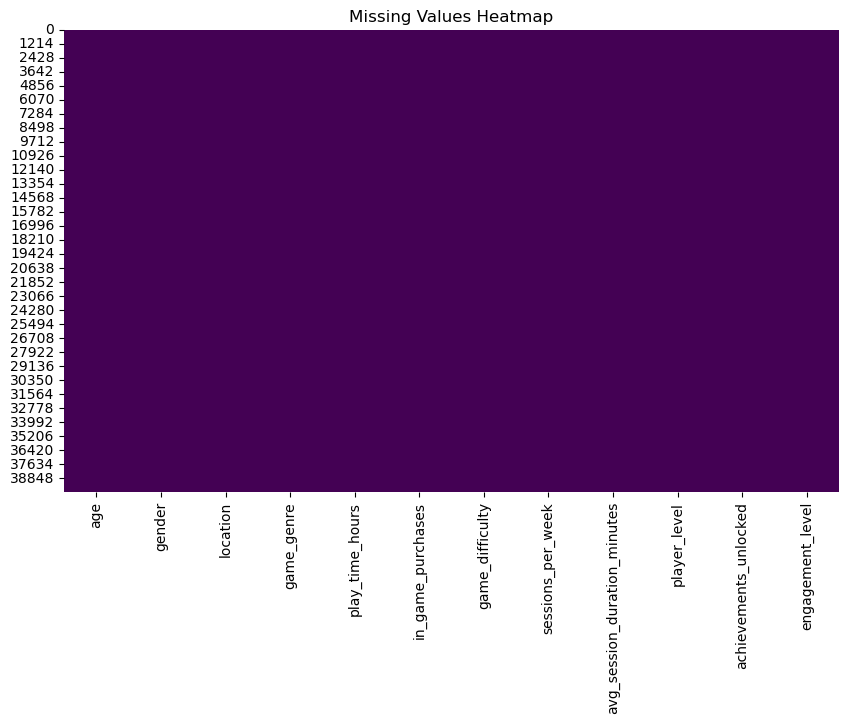

In [140]:
missing_vals = dataset.isnull().sum()
missing_pct = (missing_vals / len(dataset)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_vals, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing Values'] > 0])

plt.figure(figsize=(10, 6))
sns.heatmap(dataset.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [22]:
duplicate_count = dataset.duplicated().sum()
print(f"\nNumber of duplicate records: {duplicate_count}")


Number of duplicate records: 0


In [24]:
dataset.columns

Index(['age', 'gender', 'location', 'game_genre', 'play_time_hours',
       'in_game_purchases', 'game_difficulty', 'sessions_per_week',
       'avg_session_duration_minutes', 'player_level', 'achievements_unlocked',
       'engagement_level'],
      dtype='object')

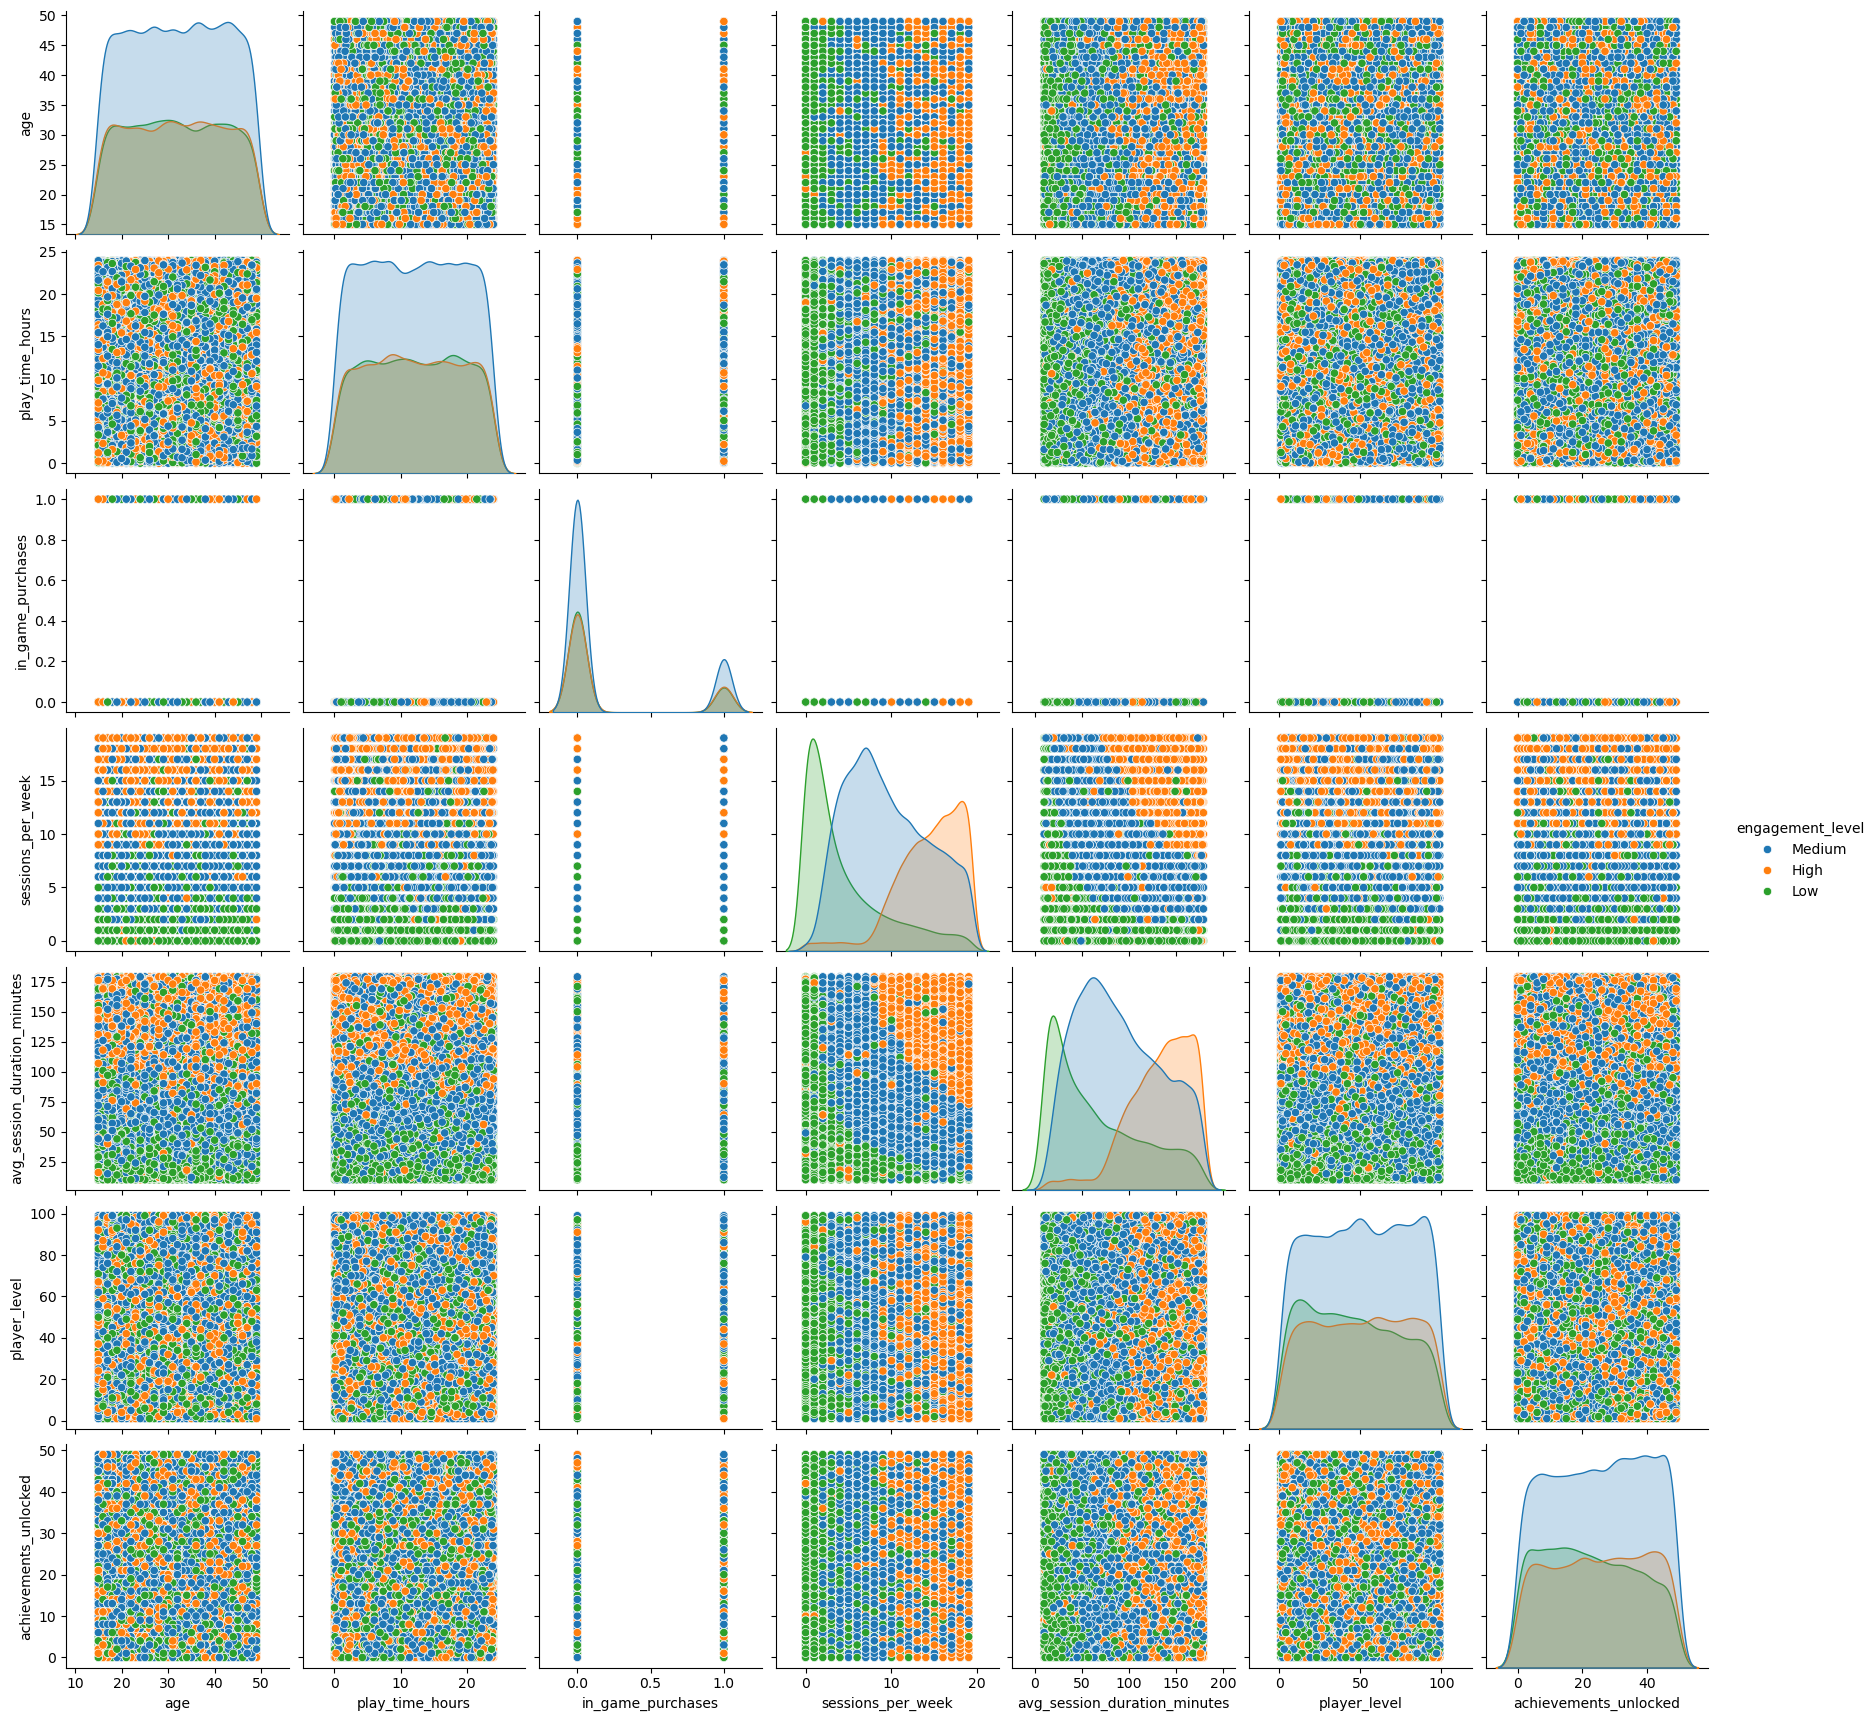

In [32]:
sns.pairplot(dataset, hue='engagement_level')

In [19]:
dataset['engagement_level'] = dataset['engagement_level'].astype('category')

In [21]:
dataset['in_game_purchases'] = dataset['in_game_purchases'].astype('category')

In [23]:
numerical_cols = [
    'age',
    'play_time_hours',
    'sessions_per_week',
    'avg_session_duration_minutes',
    'player_level',
    'achievements_unlocked'
]

categorical_cols = [
    'gender',
    'location',
    'game_genre',
    'game_difficulty',
    'in_game_purchases',
    'engagement_level'
]

In [25]:
dataset[numerical_cols].describe()

,age,play_time_hours,sessions_per_week,avg_session_duration_minutes,player_level,achievements_unlocked
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,31.992531,12.024365,9.471774,94.792252,49.655568,24.526477
std,10.043227,6.914638,5.763667,49.011375,28.588379,14.430726
min,15.000000,0.000115,0.000000,10.000000,1.000000,0.000000
25%,23.000000,6.067501,4.000000,52.000000,25.000000,12.000000
50%,32.000000,12.008002,9.000000,95.000000,49.000000,25.000000
75%,41.000000,17.963831,14.000000,137.000000,74.000000,37.000000
max,49.000000,23.999592,19.000000,179.000000,99.000000,49.000000


In [27]:
dataset[categorical_cols].dtypes

gender                 object
location               object
game_genre             object
game_difficulty        object
in_game_purchases    category
engagement_level     category
dtype: object

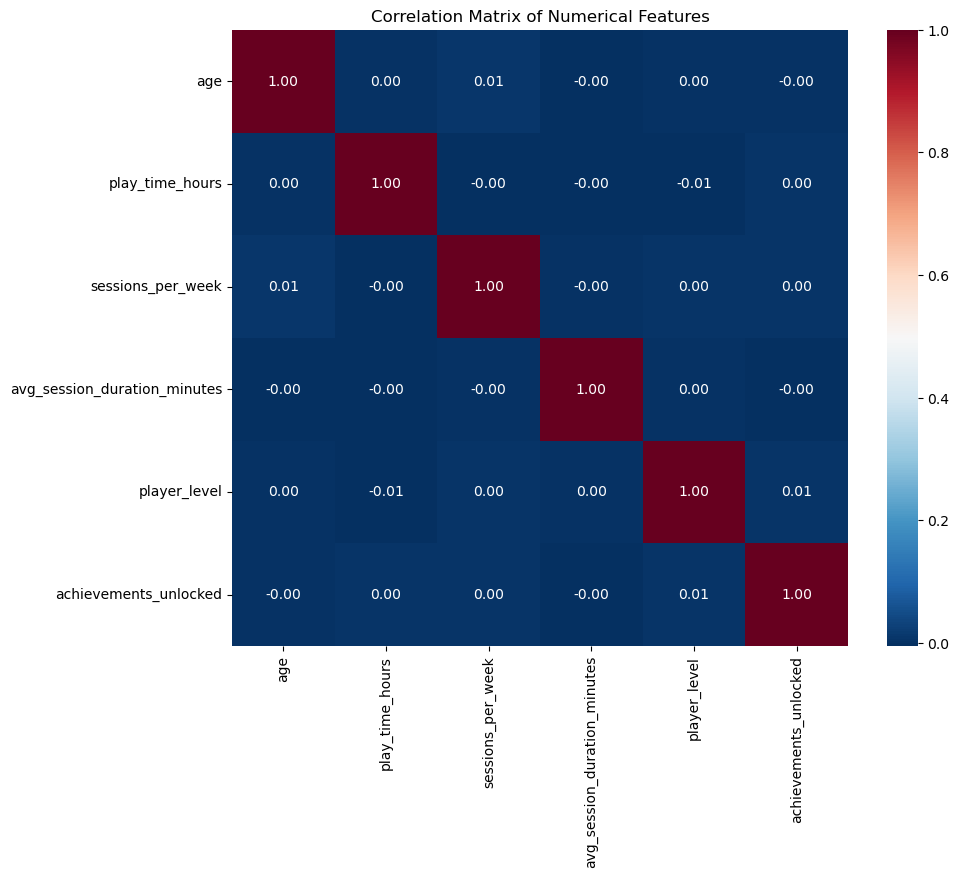

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(dataset.corr(numeric_only=True), annot=True, fmt=".2f", cmap='RdBu_r', square=True)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

## Handling and visualising the numerical features

In [44]:
for col in numerical_cols:
    print(f"\nDistribution of values for '{col}':")
    print(dataset[col].value_counts().sort_index())


Distribution of values for 'age':
age
15    1101
16    1138
17    1149
18    1167
19    1139
20    1113
21    1128
22    1150
23    1130
24    1153
25    1108
26    1107
27    1217
28    1108
29    1187
30    1150
31    1228
32    1163
33    1123
34    1103
35    1151
36    1154
37    1219
38    1140
39    1128
40    1202
41    1111
42    1187
43    1180
44    1166
45    1108
46    1121
47    1102
48    1097
49    1106
Name: count, dtype: int64

Distribution of values for 'play_time_hours':
play_time_hours
0.000115     1
0.000158     1
0.000630     1
0.000950     1
0.002559     1
            ..
23.996451    1
23.996857    1
23.997245    1
23.997838    1
23.999592    1
Name: count, Length: 40034, dtype: int64

Distribution of values for 'sessions_per_week':
sessions_per_week
0     1967
1     1980
2     2018
3     2019
4     2091
5     2035
6     1993
7     2137
8     1963
9     1974
10    1956
11    1962
12    2052
13    1983
14    1958
15    1949
16    2009
17    1958
18    1998
19   

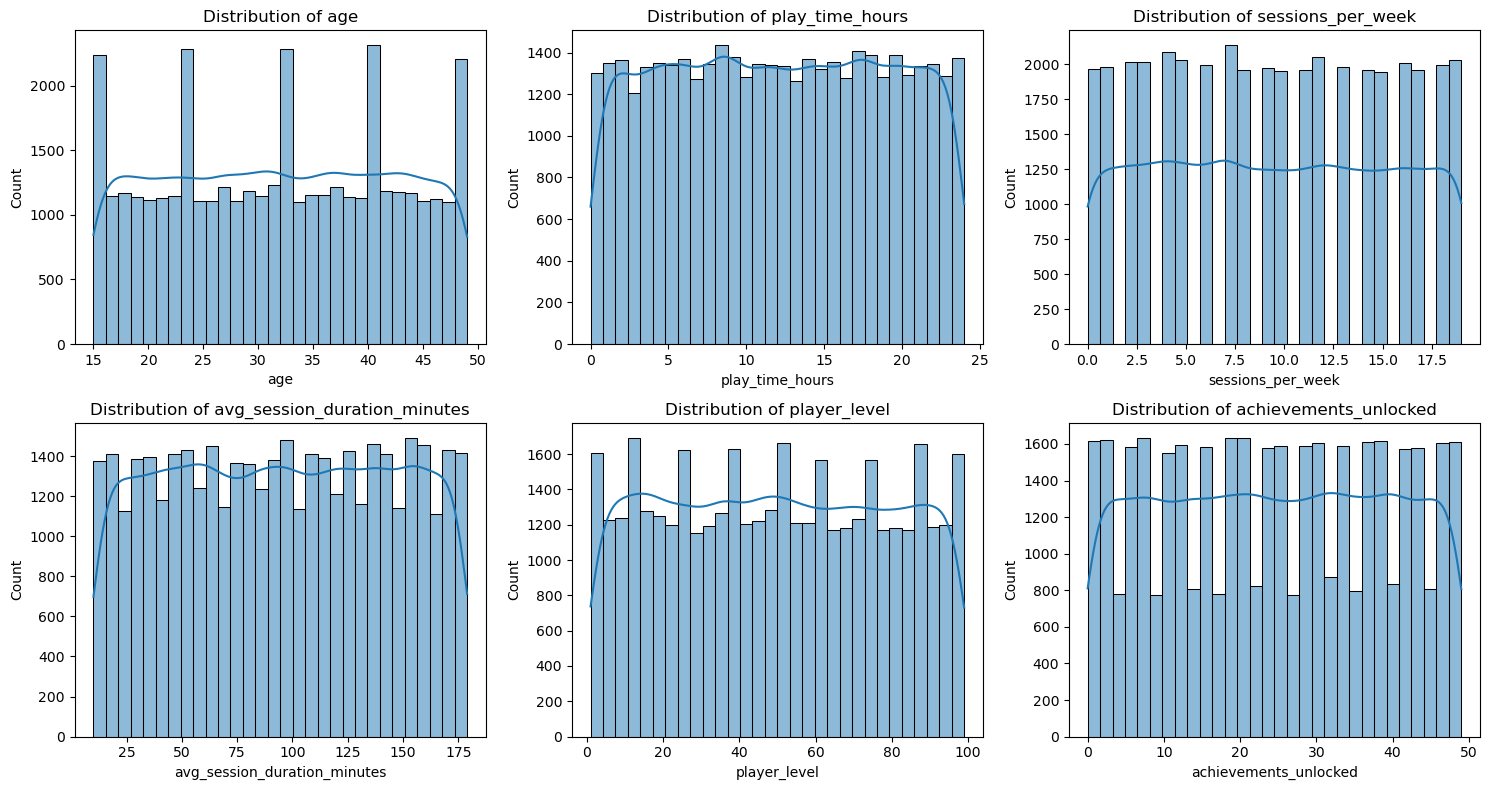

In [46]:
import math
n = len(numerical_cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axs = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axs = axs.ravel()

for i, col in enumerate(numerical_cols):
    sns.histplot(dataset[col], kde=True, bins=30, ax=axs[i])
    axs[i].set_title(f'Distribution of {col}')

# להסיר צירים ריקים אם נשארו
for j in range(len(numerical_cols), nrows*ncols):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

#Checking just the independent variables
X = dataset[['age', 'play_time_hours', 'sessions_per_week',
             'avg_session_duration_minutes', 'player_level', 'achievements_unlocked']]

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                        feature       VIF
0                           age  6.903231
1               play_time_hours  3.561286
2             sessions_per_week  3.336837
3  avg_session_duration_minutes  4.060183
4                  player_level  3.565608
5         achievements_unlocked  3.471056


### VIF
VIF analysis was performed to detect multicollinearity among predictors.
****No multicollinarity  is found****

## Handling and visualizing categorical features

In [49]:
for col in categorical_cols:
    print(f"\nValue counts for {col}:\n{dataset[col].value_counts()}")


Value counts for gender:
gender
Male      23959
Female    16075
Name: count, dtype: int64

Value counts for location:
location
USA       16000
Europe    12004
Asia       8095
Other      3935
Name: count, dtype: int64

Value counts for game_genre:
game_genre
Sports        8048
Action        8039
Strategy      8012
Simulation    7983
RPG           7952
Name: count, dtype: int64

Value counts for game_difficulty:
game_difficulty
Easy      20015
Medium    12011
Hard       8008
Name: count, dtype: int64

Value counts for in_game_purchases:
in_game_purchases
0    31993
1     8041
Name: count, dtype: int64

Value counts for engagement_level:
engagement_level
Medium    19374
High      10336
Low       10324
Name: count, dtype: int64


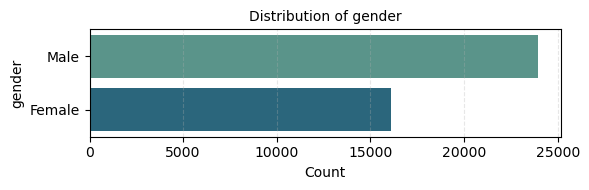

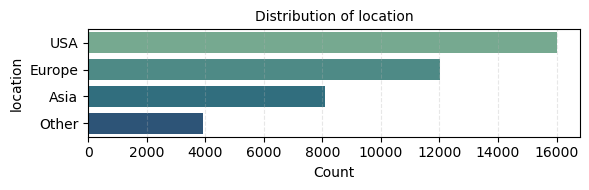

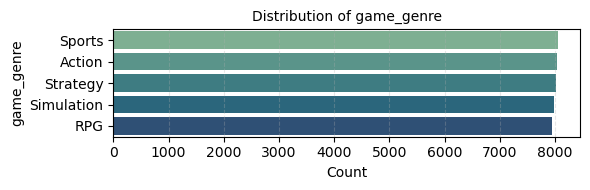

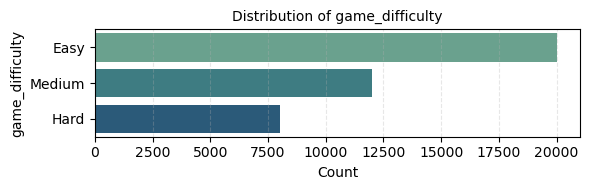

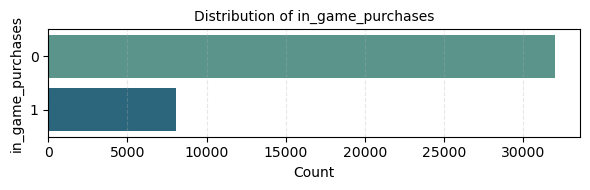

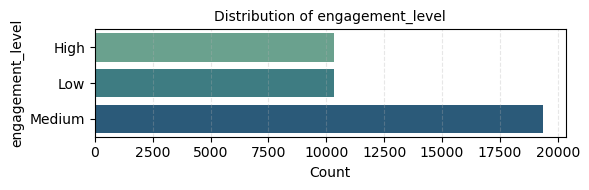

In [52]:
## import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# לולאה על כל המשתנים הקטגוריאליים
for col in categorical_cols:
    plt.figure(figsize=(6,2))
    vc = dataset[col].value_counts()

    sns.barplot(x=vc.values, y=vc.index, hue=vc.index, palette="crest", dodge=False, legend=False)
    plt.title(f"Distribution of {col}", fontsize=10)
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


#### Note about the distribution
No extreme imbalanced variables were found.

## Analyzing Outliers

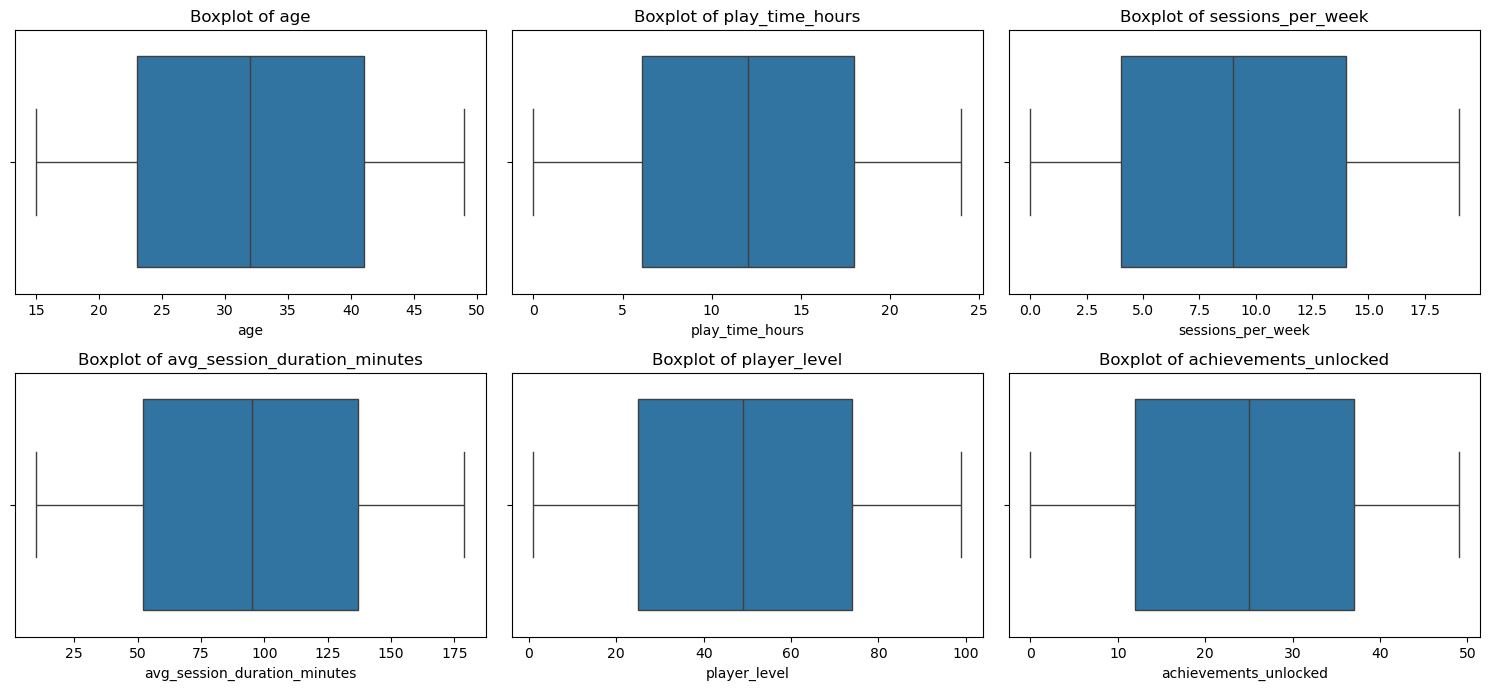

In [44]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=dataset[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

### Note about the outliers 
This dataset does not include outliers.

# Multinomial Logistic Regression- Part 1

#### *Logistic Regression Modelling*
At this stage, a multinomial Logistic Regression model was implemented to predict the player's engagement level (Low, Medium, High).

Prior to modelling, the dataset preprocessing steps including dummy uncoding of categorial variables and feature scaling using standardization. The target variable was consolidated into a single ordinal label with three classes.

The dataset was split into training and testing using 80/20 ratio with stratificaion to preserve class distribution.

The Logistic Regression model achieved an accuracy of 82% on the test set, indicating a stron baseline performance for the classification task.

Non-significant explanatory variables with P-values ​​above 0.08 in the 2 equations (2 Y) were filtered out.

#### *Extention from Binary to Multinomial Logistic Regression*
Logistic Regression is commonly introduced in its binary form, where the dependent variable containes two possible outcomes. However, in this project, the target variable consist of three categories(Low, Mediun, High). Therefore, the modelling framework was extended to Multinomial Logistic Regression. 

Multinomial Logistic Regression generalized the binary model by estimating probabilities acrose multiple classes simultaneously using the softmax function. While the core principles remain the same- modelling class probabilities based on explanatory variables - the model allows for classification beyond two outcomes. 

This extension is widely used in multi-class tasks and is fully supported within the sckit-learn implemention. 

In [29]:
from sklearn.metrics import accuracy_score , classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error 
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [30]:
df_dummies = pd.get_dummies(dataset)
df_dummies.head(6)

,age,play_time_hours,sessions_per_week,avg_session_duration_minutes,player_level,achievements_unlocked,gender_Female,gender_Male,location_Asia,location_Europe,...,game_genre_Sports,game_genre_Strategy,in_game_purchases_0,in_game_purchases_1,game_difficulty_Easy,game_difficulty_Hard,game_difficulty_Medium,engagement_level_High,engagement_level_Low,engagement_level_Medium
0,43,16.271119,6,108,79,25,False,True,False,False,...,False,True,True,False,False,False,True,False,False,True
1,29,5.525961,5,144,11,10,True,False,False,False,...,False,True,True,False,False,False,True,False,False,True
2,22,8.223755,16,142,35,41,True,False,False,False,...,True,False,True,False,True,False,False,True,False,False
3,35,5.265351,9,85,57,47,False,True,False,False,...,False,False,False,True,True,False,False,False,False,True
4,33,15.531945,2,131,95,37,False,True,False,True,...,False,False,True,False,False,False,True,False,False,True
5,37,20.561855,2,81,74,22,False,True,False,True,...,False,False,True,False,True,False,False,False,True,False


In [33]:
df_dummies.columns = (
    df_dummies.columns
    .str.lower()
)
df_dummies.head(6)

,age,play_time_hours,sessions_per_week,avg_session_duration_minutes,player_level,achievements_unlocked,gender_female,gender_male,location_asia,location_europe,...,game_genre_sports,game_genre_strategy,in_game_purchases_0,in_game_purchases_1,game_difficulty_easy,game_difficulty_hard,game_difficulty_medium,engagement_level_high,engagement_level_low,engagement_level_medium
0,43,16.271119,6,108,79,25,False,True,False,False,...,False,True,True,False,False,False,True,False,False,True
1,29,5.525961,5,144,11,10,True,False,False,False,...,False,True,True,False,False,False,True,False,False,True
2,22,8.223755,16,142,35,41,True,False,False,False,...,True,False,True,False,True,False,False,True,False,False
3,35,5.265351,9,85,57,47,False,True,False,False,...,False,False,False,True,True,False,False,False,False,True
4,33,15.531945,2,131,95,37,False,True,False,True,...,False,False,True,False,False,False,True,False,False,True
5,37,20.561855,2,81,74,22,False,True,False,True,...,False,False,True,False,True,False,False,False,True,False


In [35]:
colnamedf=df_dummies.columns
print(colnamedf)

Index(['age', 'play_time_hours', 'sessions_per_week',
       'avg_session_duration_minutes', 'player_level', 'achievements_unlocked',
       'gender_female', 'gender_male', 'location_asia', 'location_europe',
       'location_other', 'location_usa', 'game_genre_action', 'game_genre_rpg',
       'game_genre_simulation', 'game_genre_sports', 'game_genre_strategy',
       'in_game_purchases_0', 'in_game_purchases_1', 'game_difficulty_easy',
       'game_difficulty_hard', 'game_difficulty_medium',
       'engagement_level_high', 'engagement_level_low',
       'engagement_level_medium'],
      dtype='object')


In [37]:
df_dummies = df_dummies.drop('gender_female', axis = 1)
df_dummies = df_dummies.drop('location_asia', axis = 1)
df_dummies = df_dummies.drop('game_genre_simulation', axis = 1)
df_dummies = df_dummies.drop('in_game_purchases_0', axis = 1)
df_dummies = df_dummies.drop('game_difficulty_easy', axis = 1)
df_dummies.head(6)

,age,play_time_hours,sessions_per_week,avg_session_duration_minutes,player_level,achievements_unlocked,gender_male,location_europe,location_other,location_usa,game_genre_action,game_genre_rpg,game_genre_sports,game_genre_strategy,in_game_purchases_1,game_difficulty_hard,game_difficulty_medium,engagement_level_high,engagement_level_low,engagement_level_medium
0,43,16.271119,6,108,79,25,True,False,True,False,False,False,False,True,False,False,True,False,False,True
1,29,5.525961,5,144,11,10,False,False,False,True,False,False,False,True,False,False,True,False,False,True
2,22,8.223755,16,142,35,41,False,False,False,True,False,False,True,False,False,False,False,True,False,False
3,35,5.265351,9,85,57,47,True,False,False,True,True,False,False,False,True,False,False,False,False,True
4,33,15.531945,2,131,95,37,True,True,False,False,True,False,False,False,False,False,True,False,False,True
5,37,20.561855,2,81,74,22,True,True,False,False,False,True,False,False,False,False,False,False,True,False


In [39]:
df_dummies = df_dummies.map(lambda x: float(x) if isinstance(x, bool) else x)
df_dummies.head(6)

,age,play_time_hours,sessions_per_week,avg_session_duration_minutes,player_level,achievements_unlocked,gender_male,location_europe,location_other,location_usa,game_genre_action,game_genre_rpg,game_genre_sports,game_genre_strategy,in_game_purchases_1,game_difficulty_hard,game_difficulty_medium,engagement_level_high,engagement_level_low,engagement_level_medium
0,43,16.271119,6,108,79,25,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,29,5.525961,5,144,11,10,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,22,8.223755,16,142,35,41,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,35,5.265351,9,85,57,47,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,33,15.531945,2,131,95,37,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
5,37,20.561855,2,81,74,22,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [40]:
y= np.select(
    [
        df_dummies['engagement_level_low'].eq(1),
        df_dummies['engagement_level_medium'].eq(1),
        df_dummies['engagement_level_high'].eq(1)
    ],
    [0,1,2]
).astype(int)
        

In [43]:
np.unique(y, return_counts=True)

(array([0, 1, 2]), array([10324, 19374, 10336], dtype=int64))

In [45]:
x= df_dummies.drop(columns=[
    'engagement_level_high',
    'engagement_level_medium',
    'engagement_level_low'
])

In [47]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split(
    x,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [49]:
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()

x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)

### Variable Selection 

To improve model inerpetability and avoid inclouding irrelevent predictors , a backword variable selection procedure was applied. 
The process began with a full model containing all explanatory variables. Variables were then removed sequentially based on their statistical sagnificance. Importantly, a variable was removed only if it was not statistically sagnificant in any of the multinomial equeations. 
This iterative procedure unsured that predictors contributing to at least one outcome comparison were retained, thereby mainatining the explanatory power and stability of the model. 

In [143]:
import statsmodels.api as sm 

X_sm= x.copy()
X_sm= sm.add_constant(x)

p_threshold= 0.08

while True:
    model= sm.MNLogit( y, X_sm ) 
    results= model.fit(disp=0)

    p_values= results.pvalues

    #מוציאים את הP הכי גבוה
    removable= p_values[(p_values > p_threshold).all(axis=1)]

    removable = removable.drop(index= 'const', errors = 'ignore') 

    if removable.empty: 
        break 

    worst_feature= removable.mean(axis=1).idxmax()
    worst_p= removable.loc[worst_feature].max()

    print(f"Removing variable : {worst_feature} (max p={worst_p: .3f})")

    X_sm=X_sm.drop(columns=[worst_feature])

        
print("\nFinal model variables:")
print(X_sm.columns)

final_model= sm.MNLogit(y, X_sm).fit()
print(final_model.summary())

Removing variable : game_genre_action (max p= 0.798)
Removing variable : game_genre_rpg (max p= 0.938)
Removing variable : game_genre_strategy (max p= 0.811)
Removing variable : gender_male (max p= 0.697)
Removing variable : game_difficulty_hard (max p= 0.787)
Removing variable : game_difficulty_medium (max p= 0.759)
Removing variable : location_usa (max p= 0.857)
Removing variable : game_genre_sports (max p= 0.520)
Removing variable : age (max p= 0.659)
Removing variable : play_time_hours (max p= 0.521)
Removing variable : location_europe (max p= 0.488)
Removing variable : location_other (max p= 0.427)

Final model variables:
Index(['const', 'sessions_per_week', 'avg_session_duration_minutes',
       'player_level', 'achievements_unlocked', 'in_game_purchases_1'],
      dtype='object')
Optimization terminated successfully.
         Current function value: 0.590140
         Iterations 8
                          MNLogit Regression Results                          
Dep. Variable:       

In [144]:
X_reduced= x.drop(columns=[
    'game_genre_action', 
    'game_genre_rpg',
    'game_genre_strategy', 
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
])

x_train_reduced = X_reduced.loc[x_train.index]
x_test_reduced= X_reduced.loc[x_test.index]


In [145]:
x_train_reduced_scaled= scaler.fit_transform(x_train_reduced)

In [146]:
x_test_reduced_scaled = scaler.transform(x_test_reduced)

#### *note*
The reduced logistic regression model was then evaluated using the same train-test split in order to compare predictive performance with the full model specificaion. 

### ***Full Model***

Full X shape: (40034, 17)
Full y shape: (40034,)
Train shape: (32027, 17)
Test shape: (8007, 17)


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Best Params: {'logit__C': 10}
Best CV Accuracy: 0.8225

Train Accuracy: 0.8232
Test Accuracy: 0.8262
Accuracy Gap (Train - Test): -0.003
No substantial overfitting detected.

Confusion Matrix (Test):
[[1454  558   53]
 [ 300 3449  126]
 [  61  294 1712]]

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.80      0.70      0.75      2065
           1       0.80      0.89      0.84      3875
           2       0.91      0.83      0.87      2067

    accuracy                           0.83      8007
   macro avg       0.84      0.81      0.82      8007
weighted avg       0.83      0.83      0.82      8007



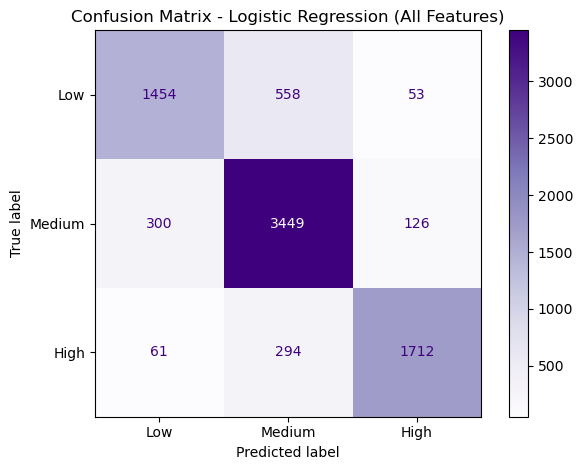

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ==========================================
# 1. Prepare X and y
# ==========================================

X = x.copy().astype(float)

if isinstance(y, pd.Series):
    y_model = y.astype(int).copy()
else:
    y_model = pd.Series(y).astype(int)

X = X.reset_index(drop=True)
y_model = y_model.reset_index(drop=True)

print("Full X shape:", X.shape)
print("Full y shape:", y_model.shape)

# ==========================================
# 2. Train/Test split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ==========================================
# 3. Pipeline + Cross Validation
# ==========================================

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=3000,
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "logit__C": [0.01, 0.1, 1, 10, 50, 100]
}

grid_logit = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_logit.fit(X_train, y_train)

print("\nBest Params:", grid_logit.best_params_)
print("Best CV Accuracy:", round(grid_logit.best_score_, 4))

# ==========================================
# 4. Final model + predictions
# ==========================================

best_logit = grid_logit.best_estimator_

y_train_pred = best_logit.predict(X_train)
y_test_pred = best_logit.predict(X_test)

# ==========================================
# 5. Evaluation
# ==========================================

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("\nTrain Accuracy:", round(train_acc, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Accuracy Gap (Train - Test):", round(train_acc - test_acc, 4))

if train_acc - test_acc > 0.03:
    print("Possible overfitting detected.")
else:
    print("No substantial overfitting detected.")

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

# ==========================================
# 6. Confusion Matrix plot
# ==========================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Low", "Medium", "High"],
    cmap="Purples"
)

plt.title("Confusion Matrix - Logistic Regression (All Features)")
plt.tight_layout()
plt.show()

## Remove non-significant variables

Reduced X shape: (40034, 5)
Reduced y shape: (40034,)
Train shape: (32027, 5)
Test shape: (8007, 5)


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Best Params: {'logit__C': 0.1}
Best CV Accuracy: 0.8241

Train Accuracy: 0.8237
Test Accuracy: 0.8255
Accuracy Gap (Train - Test): -0.0018
No substantial overfitting detected.

Confusion Matrix (Test):
[[1452  559   54]
 [ 299 3452  124]
 [  61  300 1706]]

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.80      0.70      0.75      2065
           1       0.80      0.89      0.84      3875
           2       0.91      0.83      0.86      2067

    accuracy                           0.83      8007
   macro avg       0.84      0.81      0.82      8007
weighted avg       0.83      0.83      0.82      8007



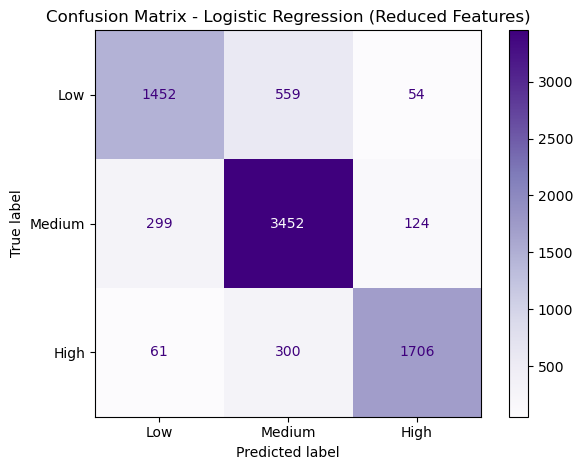

In [84]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

X_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy().astype(float)

if isinstance(y, pd.Series):
    y_model = y.astype(int).copy()
else:
    y_model = pd.Series(y).astype(int)

X_reduced = X_reduced.reset_index(drop=True)
y_model = y_model.reset_index(drop=True)

print("Reduced X shape:", X_reduced.shape)
print("Reduced y shape:", y_model.shape)

# ==========================================
# 2. Train/Test split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,

    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ==========================================
# 3. Pipeline + Cross Validation
# ==========================================

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=3000,
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "logit__C": [0.01, 0.1, 1, 10, 50, 100]
}

grid_logit = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_logit.fit(X_train, y_train)

print("\nBest Params:", grid_logit.best_params_)
print("Best CV Accuracy:", round(grid_logit.best_score_, 4))

# ==========================================
# 4. Final model + predictions
# ==========================================

best_logit = grid_logit.best_estimator_

y_train_pred = best_logit.predict(X_train)
y_test_pred = best_logit.predict(X_test)

# ==========================================
# 5. Evaluation
# ==========================================

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("\nTrain Accuracy:", round(train_acc, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Accuracy Gap (Train - Test):", round(train_acc - test_acc, 4))

if train_acc - test_acc > 0.03:
    print("Possible overfitting detected.")
else:
    print("No substantial overfitting detected.")

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

# ==========================================
# 6. Confusion Matrix plot
# ==========================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Low", "Medium", "High"],
    cmap="Purples"
)

plt.title("Confusion Matrix - Logistic Regression (Reduced Features)")
plt.tight_layout()
plt.show()


## KNN Model - Part 2

In [81]:
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

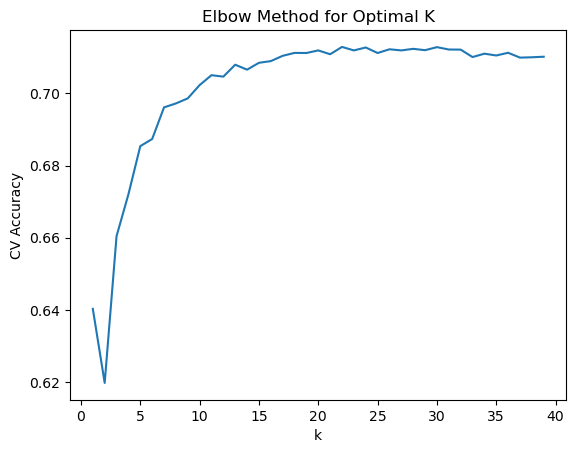

In [91]:
k_values = range( 1, 40 ) 
scores = []

for k in k_values:
    knn= KNeighborsClassifier(n_neighbors=k)
    cv_score= cross_val_score(knn, x_train_scaled, y_train, cv=5)
    scores.append(cv_score.mean())

plt.plot(k_values, scores)
plt.xlabel("k")
plt.ylabel("CV Accuracy")
plt.title("Elbow Method for Optimal K")
plt.show()

In [83]:
from sklearn.pipeline import Pipeline 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score

In [92]:
pipe= Pipeline([
    ("scaler", StandardScaler()),
    ("knn",KNeighborsClassifier())
])

param_grid={"knn__n_neighbors": list(range(1,51))}

cv= StratifiedKFold(n_splits=5, shuffle= True, random_state=42)

grid= GridSearchCV(pipe, param_grid=param_grid, cv=cv, scoring= "accuracy")
grid.fit(x_train,y_train)

best_knn=grid.best_estimator_
y_pred_knn= best_knn.predict(x_test)

print("Best k:", grid.best_params_["knn__n_neighbors"])
print("Test Accuracy:", accuracy_score(y_test, y_pred_knn))

Best k: 32
Test Accuracy: 0.7243661795928562


In [93]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.7243661795928562
[[ 863 1159   43]
 [ 109 3687   79]
 [  36  781 1250]]
              precision    recall  f1-score   support

           0       0.86      0.42      0.56      2065
           1       0.66      0.95      0.78      3875
           2       0.91      0.60      0.73      2067

    accuracy                           0.72      8007
   macro avg       0.81      0.66      0.69      8007
weighted avg       0.77      0.72      0.71      8007



In [71]:
from matplotlib.colors import LinearSegmentedColormap

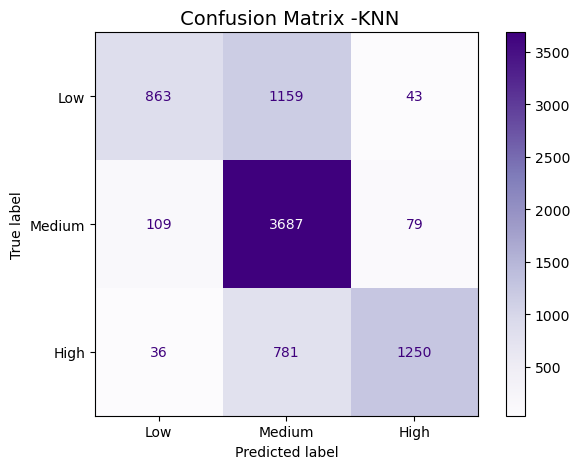

In [94]:
cm= confusion_matrix(y_test, y_pred_knn)

disp= ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "Medium", "High"]
)

disp.plot(cmap="Purples")
plt.title(" Confusion Matrix -KNN", fontsize= 14)
plt.tight_layout()
plt.show()


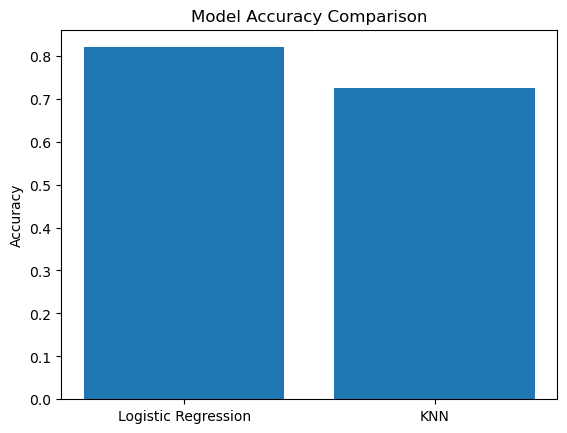

In [95]:
models= ["Logistic Regression", "KNN"]
scores= [ 0.82, 0.724]

plt.figure()
plt.bar(models, scores)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

Train shape: (32027, 17)
Test shape: (8007, 17)


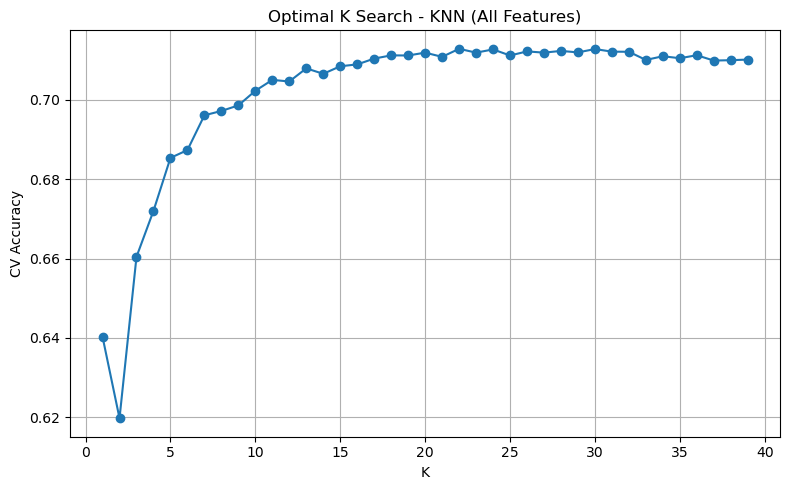


Best K: 32
Best CV Accuracy: 0.7142

Train Accuracy: 0.7456208823804915
Test Accuracy: 0.7243661795928562
Accuracy Gap (Train - Test): 0.0213
No substantial overfitting detected.

Confusion Matrix (Test):
[[ 863 1159   43]
 [ 109 3687   79]
 [  36  781 1250]]

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.86      0.42      0.56      2065
           1       0.66      0.95      0.78      3875
           2       0.91      0.60      0.73      2067

    accuracy                           0.72      8007
   macro avg       0.81      0.66      0.69      8007
weighted avg       0.77      0.72      0.71      8007



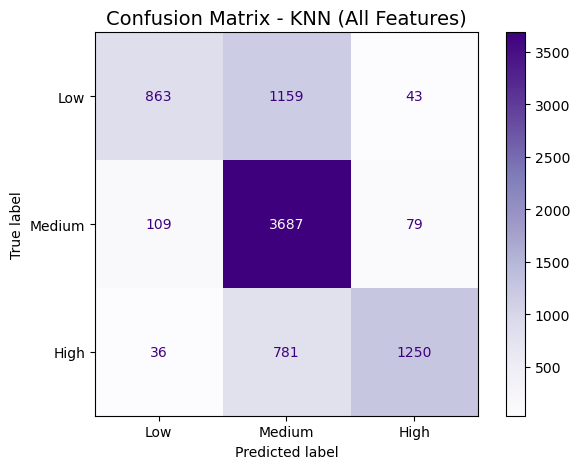

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ==========================================
# 1. Prepare X and y
# ==========================================

X = x.copy().astype(float)

if isinstance(y, pd.Series):
    y_model = y.astype(int).copy()
else:
    y_model = pd.Series(y).astype(int)

# ==========================================
# 2. Train/Test split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ==========================================
# 3. Elbow-like plot for K
# ==========================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

k_values = range(1, 40)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_score = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="accuracy")
    scores.append(cv_score.mean())

plt.figure(figsize=(8,5))
plt.plot(k_values, scores, marker='o')
plt.xlabel("K")
plt.ylabel("CV Accuracy")
plt.title("Optimal K Search - KNN (All Features)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# 4. Pipeline + GridSearchCV
# ==========================================

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": list(range(1, 51))
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_knn = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_

y_train_pred_knn = best_knn.predict(X_train)
y_test_pred_knn = best_knn.predict(X_test)

print("\nBest K:", grid_knn.best_params_["knn__n_neighbors"])
print("Best CV Accuracy:", round(grid_knn.best_score_, 4))

# ==========================================
# 5. Evaluation
# ==========================================

train_acc = accuracy_score(y_train, y_train_pred_knn)
test_acc = accuracy_score(y_test, y_test_pred_knn)

print("\nTrain Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Accuracy Gap (Train - Test):", round(train_acc - test_acc, 4))

if train_acc - test_acc > 0.03:
    print("Possible overfitting detected.")
else:
    print("No substantial overfitting detected.")

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred_knn))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_knn))

# ==========================================
# 6. Confusion Matrix plot
# ==========================================

cm = confusion_matrix(y_test, y_test_pred_knn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "Medium", "High"]
)

disp.plot(cmap="Purples")
plt.title("Confusion Matrix - KNN (All Features)", fontsize=14)
plt.tight_layout()
plt.show()

## Remove non-significant variables

Train shape: (32027, 5)
Test shape: (8007, 5)


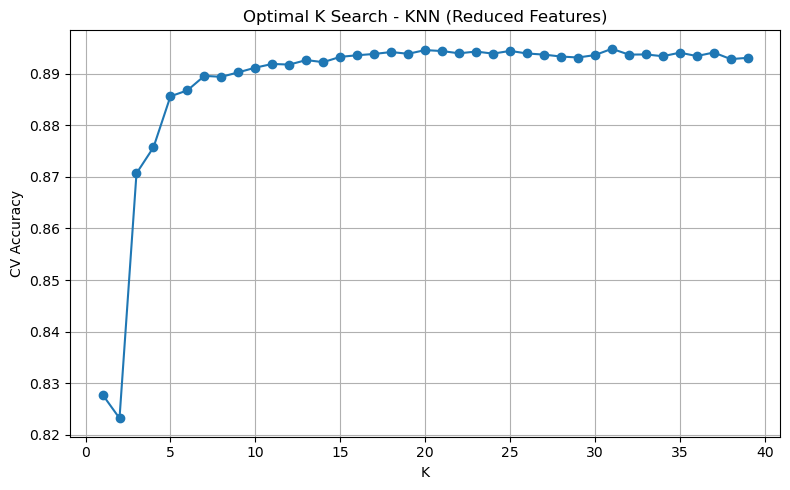


Best K: 18
Best CV Accuracy: 0.895

Train Accuracy: 0.9061416929465763
Test Accuracy: 0.8975896090920444
Accuracy Gap (Train - Test): 0.0086
No substantial overfitting detected.

Confusion Matrix (Test):
[[1749  263   53]
 [ 136 3638  101]
 [  62  205 1800]]

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.90      0.85      0.87      2065
           1       0.89      0.94      0.91      3875
           2       0.92      0.87      0.90      2067

    accuracy                           0.90      8007
   macro avg       0.90      0.89      0.89      8007
weighted avg       0.90      0.90      0.90      8007



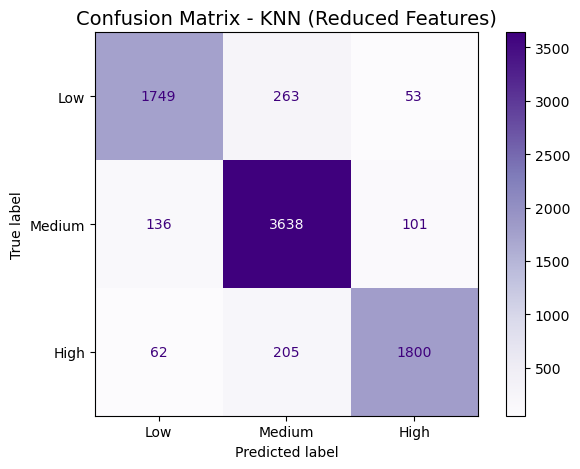

In [90]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

X_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy().astype(float)

if isinstance(y, pd.Series):
    y_model = y.astype(int).copy()
else:
    y_model = pd.Series(y).astype(int)

# ==========================================
# 2. Train/Test split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ==========================================
# 3. Elbow-like plot for K
# ==========================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

k_values = range(1, 40)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_score = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="accuracy")
    scores.append(cv_score.mean())

plt.figure(figsize=(8,5))
plt.plot(k_values, scores, marker='o')
plt.xlabel("K")
plt.ylabel("CV Accuracy")
plt.title("Optimal K Search - KNN (Reduced Features)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# 4. Pipeline + GridSearchCV
# ==========================================

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": list(range(1, 51))
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_knn = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_

y_train_pred_knn = best_knn.predict(X_train)
y_test_pred_knn = best_knn.predict(X_test)

print("\nBest K:", grid_knn.best_params_["knn__n_neighbors"])
print("Best CV Accuracy:", round(grid_knn.best_score_, 4))

# ==========================================
# 5. Evaluation
# ==========================================

train_acc = accuracy_score(y_train, y_train_pred_knn)
test_acc = accuracy_score(y_test, y_test_pred_knn)

print("\nTrain Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Accuracy Gap (Train - Test):", round(train_acc - test_acc, 4))

if train_acc - test_acc > 0.03:
    print("Possible overfitting detected.")
else:
    print("No substantial overfitting detected.")

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred_knn))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_knn))

# ==========================================
# 6. Confusion Matrix plot
# ==========================================

cm = confusion_matrix(y_test, y_test_pred_knn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "Medium", "High"]
)

disp.plot(cmap="Purples")
plt.title("Confusion Matrix - KNN (Reduced Features)", fontsize=14)
plt.tight_layout()
plt.show()



# Decision Tree  - Part 3

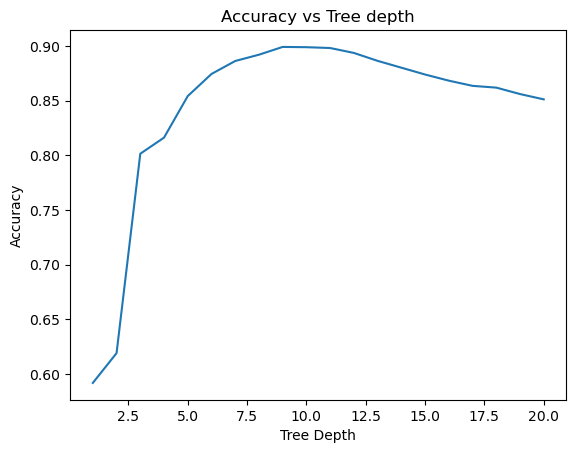

In [60]:
from sklearn.tree import DecisionTreeClassifier 

depths= range(1,21)
scores_dt=[]

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(x_train_scaled, y_train)
    scores_dt.append(dt.score(x_test_scaled,y_test))

plt.plot(depths,scores_dt)
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Tree depth")
plt.show()


In [61]:
best_d= depths[np.argmax(scores_dt)]
print("Best d:", best_d)

Best d: 9


Train shape: (32027, 17)
Test shape: (8007, 17)

Best Params: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV Accuracy: 0.9015

Train Accuracy: 0.9197552065444781
Test Accuracy: 0.902085675034345
Accuracy Gap (Train - Test): 0.0177
No substantial overfitting detected.

Confusion Matrix (Test):
[[1770  237   58]
 [ 141 3636   98]
 [  62  188 1817]]

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.90      0.86      0.88      2065
           1       0.90      0.94      0.92      3875
           2       0.92      0.88      0.90      2067

    accuracy                           0.90      8007
   macro avg       0.90      0.89      0.90      8007
weighted avg       0.90      0.90      0.90      8007



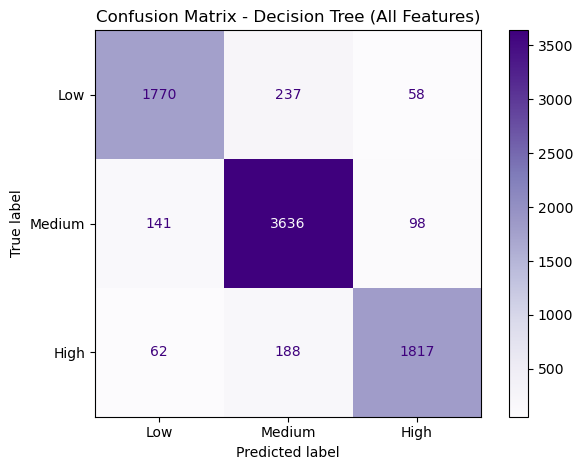

In [80]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ==========================================
# 1. Prepare X and y
# ==========================================

X = x.copy().astype(float)

if isinstance(y, pd.Series):
    y_model = y.astype(int).copy()
else:
    y_model = pd.Series(y).astype(int)

# ==========================================
# 2. Train/Test split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ==========================================
# 3. Cross-validation setup
# ==========================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================
# 4. GridSearchCV - Decision Tree
# ==========================================

param_grid = {
    "max_depth": list(range(1, 21)),
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("\nBest Params:", grid_dt.best_params_)
print("Best CV Accuracy:", round(grid_dt.best_score_, 4))

# ==========================================
# 5. Final model + predictions
# ==========================================

best_dt = grid_dt.best_estimator_

y_train_pred_dt = best_dt.predict(X_train)
y_test_pred_dt = best_dt.predict(X_test)

# ==========================================
# 6. Evaluation
# ==========================================

train_acc = accuracy_score(y_train, y_train_pred_dt)
test_acc = accuracy_score(y_test, y_test_pred_dt)

print("\nTrain Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Accuracy Gap (Train - Test):", round(train_acc - test_acc, 4))

if train_acc - test_acc > 0.03:
    print("Possible overfitting detected.")
else:
    print("No substantial overfitting detected.")

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred_dt))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_dt))

# ==========================================
# 7. Confusion Matrix plot
# ==========================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_dt,
    display_labels=["Low", "Medium", "High"],
    cmap="Purples"
)

plt.title("Confusion Matrix - Decision Tree (All Features)")
plt.tight_layout()
plt.show()

## Remove non-significant variables

Train shape: (32027, 5)
Test shape: (8007, 5)

Best Params: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV Accuracy: 0.9047

Train Accuracy: 0.9197864301995191
Test Accuracy: 0.9039590358436368
Accuracy Gap (Train - Test): 0.0158
No substantial overfitting detected.

Confusion Matrix (Test):
[[1762  246   57]
 [ 125 3651   99]
 [  62  180 1825]]

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.90      0.85      0.88      2065
           1       0.90      0.94      0.92      3875
           2       0.92      0.88      0.90      2067

    accuracy                           0.90      8007
   macro avg       0.91      0.89      0.90      8007
weighted avg       0.90      0.90      0.90      8007



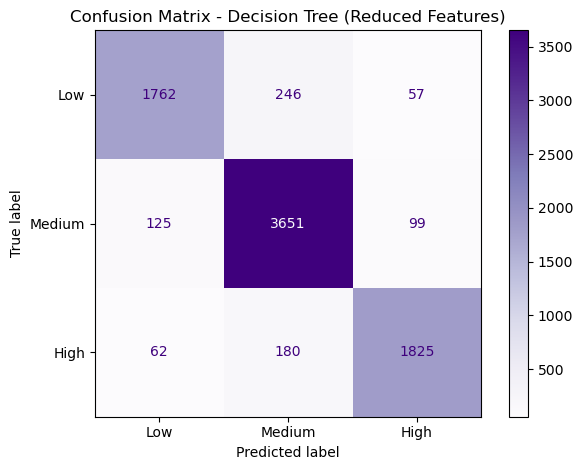

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

X_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy().astype(float)

if isinstance(y, pd.Series):
    y_model = y.astype(int).copy()
else:
    y_model = pd.Series(y).astype(int)

# ==========================================
# 2. Train/Test split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ==========================================
# 3. Cross-validation setup
# ==========================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================
# 4. GridSearchCV - Decision Tree
# ==========================================

param_grid = {
    "max_depth": list(range(1, 21)),
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("\nBest Params:", grid_dt.best_params_)
print("Best CV Accuracy:", round(grid_dt.best_score_, 4))

# ==========================================
# 5. Final model + predictions
# ==========================================

best_dt = grid_dt.best_estimator_

y_train_pred_dt = best_dt.predict(X_train)
y_test_pred_dt = best_dt.predict(X_test)

# ==========================================
# 6. Evaluation
# ==========================================

train_acc = accuracy_score(y_train, y_train_pred_dt)
test_acc = accuracy_score(y_test, y_test_pred_dt)

print("\nTrain Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Accuracy Gap (Train - Test):", round(train_acc - test_acc, 4))

if train_acc - test_acc > 0.03:
    print("Possible overfitting detected.")
else:
    print("No substantial overfitting detected.")

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred_dt))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_dt))

# ==========================================
# 7. Confusion Matrix plot
# ==========================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_dt,
    display_labels=["Low", "Medium", "High"],
    cmap="Purples"
)

plt.title("Confusion Matrix - Decision Tree (Reduced Features)")
plt.tight_layout()
plt.show()


## Random Forest Clasification Model - Part 4

Train shape: (32027, 17)
Test shape: (8007, 17)

Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 400}
Best CV Accuracy: 0.9078

Train Accuracy: 1.0
Test Accuracy: 0.9120769326839016
Accuracy Gap (Train - Test): 0.0879
Possible overfitting detected.

Confusion Matrix (Test):
[[1821  192   52]
 [  99 3691   85]
 [  63  213 1791]]

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.92      0.88      0.90      2065
           1       0.90      0.95      0.93      3875
           2       0.93      0.87      0.90      2067

    accuracy                           0.91      8007
   macro avg       0.92      0.90      0.91      8007
weighted avg       0.91      0.91      0.91      8007



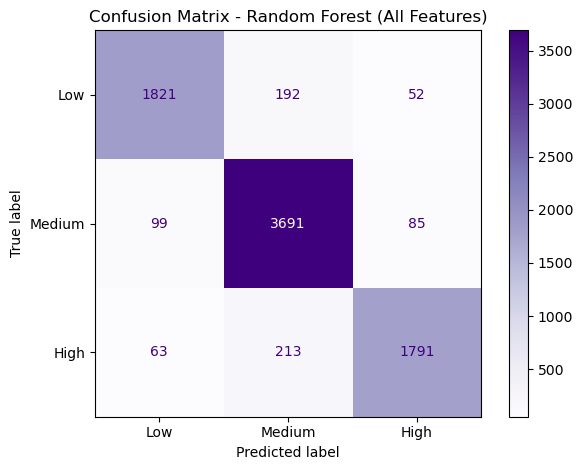

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ==========================================
# 1. Prepare X and y
# ==========================================

X = x.copy().astype(float)

if isinstance(y, pd.Series):
    y_model = y.astype(int).copy()
else:
    y_model = pd.Series(y).astype(int)

# ==========================================
# 2. Train/Test split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ==========================================
# 3. Cross-validation setup
# ==========================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================
# 4. GridSearchCV - Random Forest
# ==========================================

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 8, 12],
    "min_samples_leaf": [1, 2, 5]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("\nBest Params:", grid_rf.best_params_)
print("Best CV Accuracy:", round(grid_rf.best_score_, 4))

# ==========================================
# 5. Final model + prediction
# ==========================================

best_rf = grid_rf.best_estimator_

y_train_pred_rf = best_rf.predict(X_train)
y_test_pred_rf = best_rf.predict(X_test)

# ==========================================
# 6. Evaluation
# ==========================================

train_acc = accuracy_score(y_train, y_train_pred_rf)
test_acc = accuracy_score(y_test, y_test_pred_rf)

print("\nTrain Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Accuracy Gap (Train - Test):", round(train_acc - test_acc, 4))

if train_acc - test_acc > 0.03:
    print("Possible overfitting detected.")
else:
    print("No substantial overfitting detected.")

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred_rf))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_rf))

# ==========================================
# 7. Confusion Matrix plot
# ==========================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_rf,
    display_labels=["Low", "Medium", "High"],
    cmap="Purples"
)

plt.title("Confusion Matrix - Random Forest (All Features)")
plt.tight_layout()
plt.show()

## Remove non-significant variables

Train shape: (32027, 5)
Test shape: (8007, 5)

Best Params: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 400}
Best CV Accuracy: 0.9211

Train Accuracy: 0.9385518468791957
Test Accuracy: 0.9216935181715998
Accuracy Gap (Train - Test): 0.0169
No substantial overfitting detected.

Confusion Matrix (Test):
[[1849  165   51]
 [  96 3698   81]
 [  62  172 1833]]

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      2065
           1       0.92      0.95      0.94      3875
           2       0.93      0.89      0.91      2067

    accuracy                           0.92      8007
   macro avg       0.92      0.91      0.92      8007
weighted avg       0.92      0.92      0.92      8007



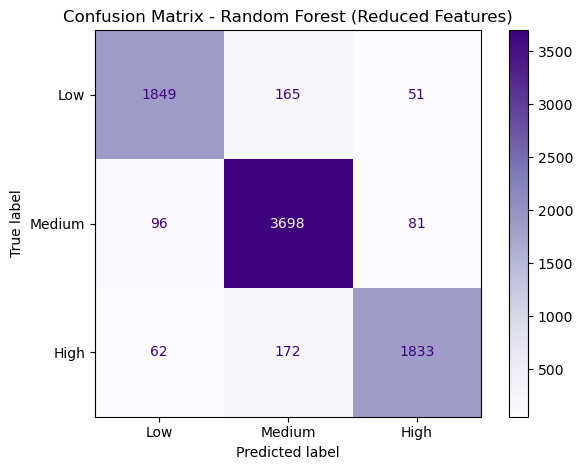

In [78]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

X_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy().astype(float)

if isinstance(y, pd.Series):
    y_model = y.astype(int).copy()
else:
    y_model = pd.Series(y).astype(int)

# ==========================================
# 2. Train/Test split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,

    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ==========================================
# 3. Cross-validation setup
# ==========================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================
# 4. GridSearchCV - Random Forest
# ==========================================

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 8, 12],
    "min_samples_leaf": [1, 2, 5]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("\nBest Params:", grid_rf.best_params_)
print("Best CV Accuracy:", round(grid_rf.best_score_, 4))

# ==========================================
# 5. Final model + prediction
# ==========================================

best_rf = grid_rf.best_estimator_

y_train_pred_rf = best_rf.predict(X_train)
y_test_pred_rf = best_rf.predict(X_test)

# ==========================================
# 6. Evaluation
# ==========================================

train_acc = accuracy_score(y_train, y_train_pred_rf)
test_acc = accuracy_score(y_test, y_test_pred_rf)

print("\nTrain Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Accuracy Gap (Train - Test):", round(train_acc - test_acc, 4))

if train_acc - test_acc > 0.03:
    print("Possible overfitting detected.")
else:
    print("No substantial overfitting detected.")

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred_rf))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_rf))

# ==========================================
# 7. Confusion Matrix plot
# ==========================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_rf,
    display_labels=["Low", "Medium", "High"],
    cmap="Purples"
)

plt.title("Confusion Matrix - Random Forest (Reduced Features)")
plt.tight_layout()
plt.show()

## Gradient Boosting- Part 5

In [113]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

param_grid= {
    "n_estimators":[150, 250],
    "learning_rate": [0.05, 0.1],
    "max_depth":[2, 3]
}

grid_gb= GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid= param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs= 1
)

grid_gb.fit(x_train, y_train)

print("Best Params:", grid_gb.best_params_)


Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 250}


In [119]:
best_gb=grid_gb.best_estimator_
y_pred_gb= best_gb.predict(x_test)
print("Best Params:", grid_gb.best_params_)
print("Test Accuracy:", accuracy_score(y_test, y_pred_gb))

Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 250}
Test Accuracy: 0.9125764955663794


In [121]:
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Accuracy: 0.9125764955663794
[[1801  209   55]
 [ 109 3670   96]
 [  60  171 1836]]
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      2065
           1       0.91      0.95      0.93      3875
           2       0.92      0.89      0.91      2067

    accuracy                           0.91      8007
   macro avg       0.91      0.90      0.91      8007
weighted avg       0.91      0.91      0.91      8007



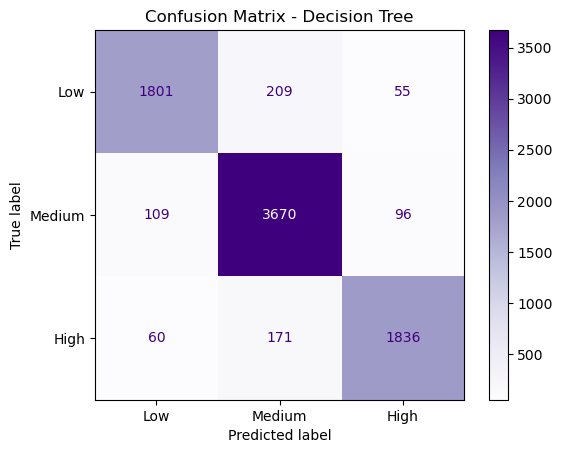

In [123]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_gb,
    display_labels=["Low", "Medium", "High"],
    cmap="Purples"
)

plt.title("Confusion Matrix - Decision Tree")
plt.show()

Train shape: (32027, 17)
Test shape: (8007, 17)

Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 250}
Best CV Accuracy: 0.9105

Train Accuracy: 0.9198176538545603
Test Accuracy: 0.9125764955663794
Accuracy Gap (Train - Test): 0.0072
No substantial overfitting detected.

Confusion Matrix (Test):
[[1801  209   55]
 [ 109 3670   96]
 [  60  171 1836]]

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      2065
           1       0.91      0.95      0.93      3875
           2       0.92      0.89      0.91      2067

    accuracy                           0.91      8007
   macro avg       0.91      0.90      0.91      8007
weighted avg       0.91      0.91      0.91      8007



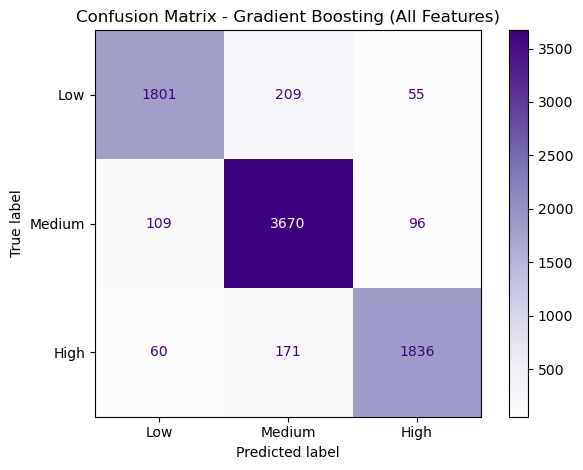

In [96]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ==========================================
# 1. Prepare X and y
# ==========================================

X = x.copy().astype(float)

if isinstance(y, pd.Series):
    y_model = y.astype(int).copy()
else:
    y_model = pd.Series(y).astype(int)

# ==========================================
# 2. Train/Test split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ==========================================
# 3. Cross-validation setup
# ==========================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================
# 4. GridSearchCV - Gradient Boosting
# ==========================================

param_grid = {
    "n_estimators": [150, 250],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3]
}

grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print("\nBest Params:", grid_gb.best_params_)
print("Best CV Accuracy:", round(grid_gb.best_score_, 4))

# ==========================================
# 5. Final model + predictions
# ==========================================

best_gb = grid_gb.best_estimator_

y_train_pred_gb = best_gb.predict(X_train)
y_test_pred_gb = best_gb.predict(X_test)

# ==========================================
# 6. Evaluation
# ==========================================

train_acc = accuracy_score(y_train, y_train_pred_gb)
test_acc = accuracy_score(y_test, y_test_pred_gb)

print("\nTrain Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Accuracy Gap (Train - Test):", round(train_acc - test_acc, 4))

if train_acc - test_acc > 0.03:
    print("Possible overfitting detected.")
else:
    print("No substantial overfitting detected.")

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred_gb))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_gb))

# ==========================================
# 7. Confusion Matrix plot
# ==========================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_gb,
    display_labels=["Low", "Medium", "High"],
    cmap="Purples"
)

plt.title("Confusion Matrix - Gradient Boosting (All Features)")
plt.tight_layout()
plt.show()

# Remove non-significant variables

Train shape: (32027, 5)
Test shape: (8007, 5)

Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 250}
Best CV Accuracy: 0.9142

Train Accuracy: 0.9201298904049708
Test Accuracy: 0.9149494192581491
Accuracy Gap (Train - Test): 0.0052
No substantial overfitting detected.

Confusion Matrix (Test):
[[1813  198   54]
 [ 110 3672   93]
 [  61  165 1841]]

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.91      0.88      0.90      2065
           1       0.91      0.95      0.93      3875
           2       0.93      0.89      0.91      2067

    accuracy                           0.91      8007
   macro avg       0.92      0.91      0.91      8007
weighted avg       0.92      0.91      0.91      8007



Text(0.5, 1.0, 'Confusion Matrix - Gradient Boosting (Reduced Features)')

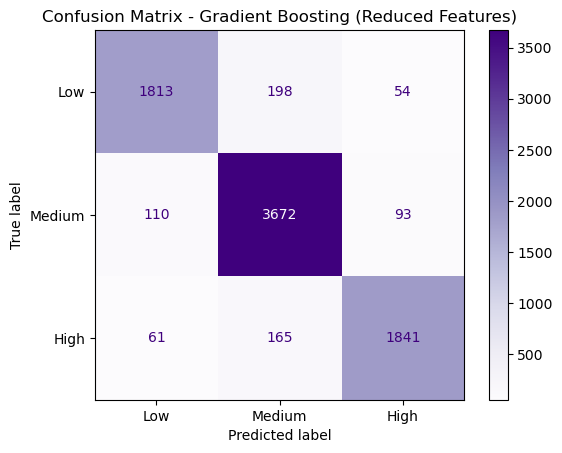

In [100]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

X_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy().astype(float)

if isinstance(y, pd.Series):
    y_model = y.astype(int).copy()
else:
    y_model = pd.Series(y).astype(int)

# ==========================================
# 2. Train/Test split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ==========================================
# 3. Cross-validation setup
# ==========================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================
# 4. GridSearchCV - Gradient Boosting
# ==========================================

param_grid = {
    "n_estimators": [150, 250],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3]
}

grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print("\nBest Params:", grid_gb.best_params_)
print("Best CV Accuracy:", round(grid_gb.best_score_, 4))

# ==========================================
# 5. Final model + predictions
# ==========================================

best_gb = grid_gb.best_estimator_

y_train_pred_gb = best_gb.predict(X_train)
y_test_pred_gb = best_gb.predict(X_test)

# ==========================================
# 6. Evaluation
# ==========================================

train_acc = accuracy_score(y_train, y_train_pred_gb)
test_acc = accuracy_score(y_test, y_test_pred_gb)

print("\nTrain Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Accuracy Gap (Train - Test):", round(train_acc - test_acc, 4))

if train_acc - test_acc > 0.03:
    print("Possible overfitting detected.")
else:
    print("No substantial overfitting detected.")

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred_gb))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_gb))

# ==========================================
# 7. Confusion Matrix plot
# ==========================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_gb,
    display_labels=["Low", "Medium", "High"],
    cmap="Purples"
)

plt.title("Confusion Matrix - Gradient Boosting (Reduced Features)")

# AdaBoost - Part 6

Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


[CV] END ...............learning_rate=0.05, n_estimators=100; total time=   2.2s


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


[CV] END ...............learning_rate=0.05, n_estimators=100; total time=   2.4s


...

[CV] END ................learning_rate=1.0, n_estimators=400; total time= 2.3min


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


[CV] END ................learning_rate=1.0, n_estimators=400; total time=  12.3s


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Best Params: {'learning_rate': 0.5, 'n_estimators': 100}
Accuracy: 0.8225302859997502
[[1396  618   51]
 [ 219 3565   91]
 [  47  395 1625]]
              precision    recall  f1-score   support

           0       0.84      0.68      0.75      2065
           1       0.78      0.92      0.84      3875
           2       0.92      0.79      0.85      2067

    accuracy                           0.82      8007
   macro avg       0.85      0.79      0.81      8007
weighted avg       0.83      0.82      0.82      8007



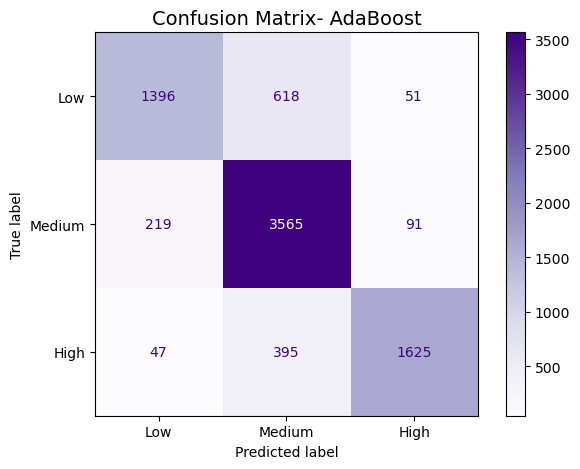

In [95]:
from sklearn.ensemble import AdaBoostClassifier 

param_grid= { 
    "n_estimators": [100, 200, 400],
    "learning_rate": [0.05, 0.1, 0.5, 1.0]
}


grid_ada= GridSearchCV(
    AdaBoostClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=1,
    verbose= 2
)

grid_ada.fit(x_train, y_train)
best_ada=grid_ada.best_estimator_

y_pred_ada= best_ada.predict(x_test)

print("Best Params:", grid_ada.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print(confusion_matrix(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_ada,
    display_labels=["Low", "Medium","High"],
    cmap="Purples"
)

plt.title("Confusion Matrix- AdaBoost", fontsize=14)
plt.tight_layout()
plt.show()

Train shape: (32027, 17)
Test shape: (8007, 17)
Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



Best Params: {'learning_rate': 0.5, 'n_estimators': 100}
Best CV Accuracy: 0.8159

Train Accuracy: 0.8211196802697723
Test Accuracy: 0.8225302859997502
Accuracy Gap (Train - Test): -0.0014
No substantial overfitting detected.

Confusion Matrix (Test):
[[1396  618   51]
 [ 219 3565   91]
 [  47  395 1625]]

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.84      0.68      0.75      2065
           1       0.78      0.92      0.84      3875
           2       0.92      0.79      0.85      2067

    accuracy                           0.82      8007
   macro avg       0.85      0.79      0.81      8007
weighted avg       0.83      0.82      0.82      8007



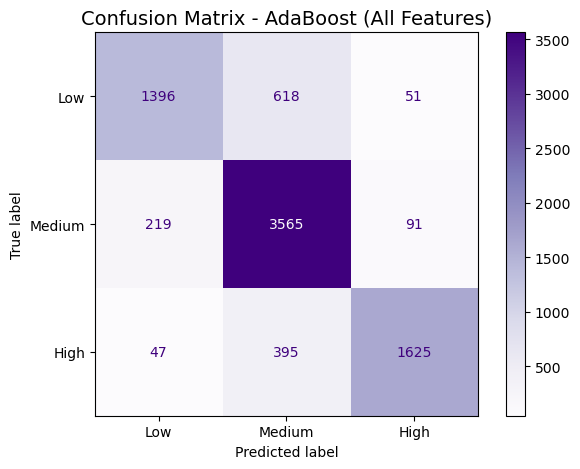

In [102]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ==========================================
# 1. Prepare X and y
# ==========================================

X = x.copy().astype(float)

if isinstance(y, pd.Series):
    y_model = y.astype(int).copy()
else:
    y_model = pd.Series(y).astype(int)

# ==========================================
# 2. Train/Test split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ==========================================
# 3. Cross-validation setup
# ==========================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================
# 4. GridSearchCV - AdaBoost
# ==========================================

param_grid = {
    "n_estimators": [100, 200, 400],
    "learning_rate": [0.05, 0.1, 0.5, 1.0]
}

grid_ada = GridSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid_ada.fit(X_train, y_train)

print("\nBest Params:", grid_ada.best_params_)
print("Best CV Accuracy:", round(grid_ada.best_score_, 4))

# ==========================================
# 5. Final model + predictions
# ==========================================

best_ada = grid_ada.best_estimator_

y_train_pred_ada = best_ada.predict(X_train)
y_test_pred_ada = best_ada.predict(X_test)

# ==========================================
# 6. Evaluation
# ==========================================

train_acc = accuracy_score(y_train, y_train_pred_ada)
test_acc = accuracy_score(y_test, y_test_pred_ada)

print("\nTrain Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Accuracy Gap (Train - Test):", round(train_acc - test_acc, 4))

if train_acc - test_acc > 0.03:
    print("Possible overfitting detected.")
else:
    print("No substantial overfitting detected.")

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred_ada))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_ada))

# ==========================================
# 7. Confusion Matrix plot
# ==========================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_ada,
    display_labels=["Low", "Medium", "High"],
    cmap="Purples"
)

plt.title("Confusion Matrix - AdaBoost (All Features)", fontsize=14)
plt.tight_layout()
plt.show()

## Remove non-significant variables

Train shape: (32027, 5)
Test shape: (8007, 5)
Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



Best Params: {'learning_rate': 0.5, 'n_estimators': 100}
Best CV Accuracy: 0.8165

Train Accuracy: 0.8210260093046492
Test Accuracy: 0.8219058323966529
Accuracy Gap (Train - Test): -0.0009
No substantial overfitting detected.

Confusion Matrix (Test):
[[1393  621   51]
 [ 215 3565   95]
 [  46  398 1623]]

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.84      0.67      0.75      2065
           1       0.78      0.92      0.84      3875
           2       0.92      0.79      0.85      2067

    accuracy                           0.82      8007
   macro avg       0.85      0.79      0.81      8007
weighted avg       0.83      0.82      0.82      8007



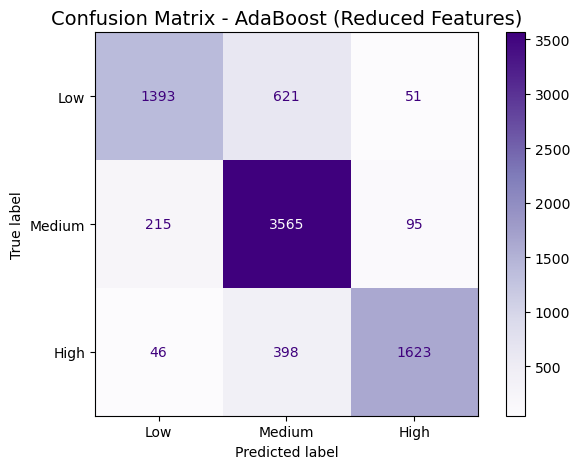

In [106]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

X_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy().astype(float)

if isinstance(y, pd.Series):
    y_model = y.astype(int).copy()
else:
    y_model = pd.Series(y).astype(int)

# ==========================================
# 2. Train/Test split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,

    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ==========================================
# 3. Cross-validation setup
# ==========================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================
# 4. GridSearchCV - AdaBoost
# ==========================================

param_grid = {
    "n_estimators": [100, 200, 400],
    "learning_rate": [0.05, 0.1, 0.5, 1.0]
}

grid_ada = GridSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid_ada.fit(X_train, y_train)

print("\nBest Params:", grid_ada.best_params_)
print("Best CV Accuracy:", round(grid_ada.best_score_, 4))

# ==========================================
# 5. Final model + predictions
# ==========================================

best_ada = grid_ada.best_estimator_

y_train_pred_ada = best_ada.predict(X_train)
y_test_pred_ada = best_ada.predict(X_test)

# ==========================================
# 6. Evaluation
# ==========================================

train_acc = accuracy_score(y_train, y_train_pred_ada)
test_acc = accuracy_score(y_test, y_test_pred_ada)

print("\nTrain Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Accuracy Gap (Train - Test):", round(train_acc - test_acc, 4))

if train_acc - test_acc > 0.03:
    print("Possible overfitting detected.")
else:
    print("No substantial overfitting detected.")

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred_ada))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_ada))

# ==========================================
# 7. Confusion Matrix plot
# ==========================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_ada,
    display_labels=["Low", "Medium", "High"],
    cmap="Purples"
)

plt.title("Confusion Matrix - AdaBoost (Reduced Features)", fontsize=14)
plt.tight_layout()
plt.show()


# XGBoost - Part 7

Full X shape: (40034, 17)
Full y shape: (40034,)
Train X shape: (32027, 17)
Train y shape: (32027,)
Test X shape: (8007, 17)
Test y shape: (8007,)
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV F1 (weighted): 0.918

Performance metrics:
                 Accuracy  Precision (weighted)  Recall (weighted)  \
XGBoost – Train   0.93596              0.936014            0.93596   
XGBoost – Test    0.92007              0.920358            0.92007   

                 F1-score (weighted)  
XGBoost – Train             0.935713  
XGBoost – Test              0.919792  

Accuracy Gap (Train - Test): 0.0159
No substantial overfitting detected.

Classification report (Test):
              precision    recall  f1-score   support

           0       0.92      0.89      0.91      2065
           1       0.91      0.95      0.93      3875
           2       0.93   

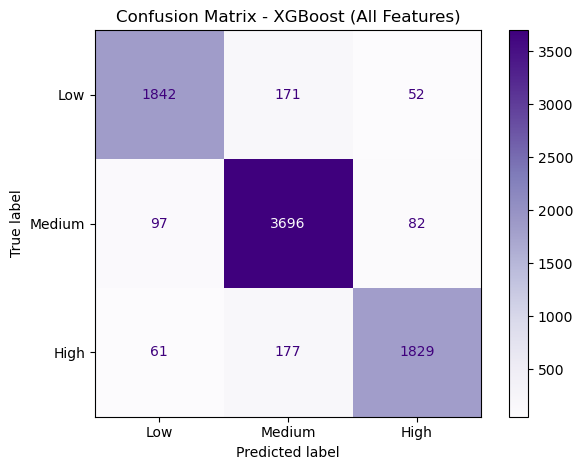

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

# ==========================================
# 1. Prepare X and y
# ==========================================

X = x.copy().astype(float)

if isinstance(y, pd.Series):
    y_model = y.astype(int).copy()
else:
    y_model = pd.Series(y).astype(int)

# לוודא שאין חוסר התאמה באינדקסים
X = X.reset_index(drop=True)
y_model = y_model.reset_index(drop=True)

print("Full X shape:", X.shape)
print("Full y shape:", y_model.shape)

# ==========================================
# 2. Train/Test split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

print("Train X shape:", X_train.shape)
print("Train y shape:", y_train.shape)
print("Test X shape:", X_test.shape)
print("Test y shape:", y_test.shape)

# ==========================================
# 3. XGBoost + GridSearchCV (Multi-class)
# ==========================================

xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

print("\nBest params:", grid_xgb.best_params_)
print("Best CV F1 (weighted):", round(grid_xgb.best_score_, 4))

best_xgb = grid_xgb.best_estimator_

# ==========================================
# 4. Predictions on Train + Test
# ==========================================

y_train_pred_xgb = best_xgb.predict(X_train)
y_test_pred_xgb = best_xgb.predict(X_test)

# ==========================================
# 5. Performance metrics
# ==========================================

def get_metrics_multiclass(y_true, y_pred, label):
    return pd.Series({
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (weighted)": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall (weighted)": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-score (weighted)": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }, name=label)

train_metrics = get_metrics_multiclass(y_train, y_train_pred_xgb, "XGBoost – Train")
test_metrics  = get_metrics_multiclass(y_test,  y_test_pred_xgb,  "XGBoost – Test")

metrics_xgb = pd.concat([train_metrics, test_metrics], axis=1).T
print("\nPerformance metrics:")
print(metrics_xgb)

# בדיקת overfitting
train_acc = accuracy_score(y_train, y_train_pred_xgb)
test_acc = accuracy_score(y_test, y_test_pred_xgb)

print("\nAccuracy Gap (Train - Test):", round(train_acc - test_acc, 4))
if train_acc - test_acc > 0.03:
    print("Possible overfitting detected.")
else:
    print("No substantial overfitting detected.")

print("\nClassification report (Test):")
print(classification_report(y_test, y_test_pred_xgb))

# ==========================================
# 6. Confusion Matrix – Test
# ==========================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_xgb,
    display_labels=["Low", "Medium", "High"],
    cmap="Purples"
)

plt.title("Confusion Matrix - XGBoost (All Features)")
plt.tight_layout()
plt.show()


## Remove non-significant variables

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV F1 (weighted): 0.9199

Performance metrics:
                 Accuracy  Precision (weighted)  Recall (weighted)  \
XGBoost – Train  0.933525              0.933570           0.933525   
XGBoost – Test   0.920819              0.921048           0.920819   

                 F1-score (weighted)  
XGBoost – Train             0.933272  
XGBoost – Test              0.920566  

Classification report (Test):
              precision    recall  f1-score   support

           0       0.92      0.89      0.91      2065
           1       0.92      0.95      0.93      3875
           2       0.93      0.89      0.91      2067

    accuracy                           0.92      8007
   macro avg       0.92      0.91      0.92      8007
weighted avg       0.92      0.92      0.92      8007


Confusion Matrix (Test):
[[

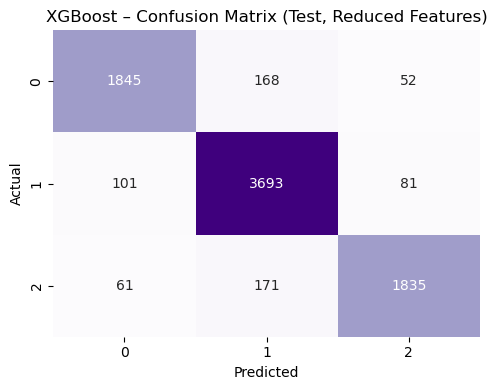

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)

from xgboost import XGBClassifier

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

x_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy()
x_reduced = x_reduced.astype(float)

# לוודא y מספרי
if isinstance(y, pd.Series):
    y_reduced = y.astype(int).copy()
else:
    y_reduced = pd.Series(y).astype(int)

# ==========================================
# 2. Train/Test split
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    x_reduced,
    y_reduced,
    test_size=0.2,
    random_state=42,
    stratify=y_reduced
)

# ==========================================
# 3. XGBoost + GridSearchCV (Multi-class)
# ==========================================

xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(x_train, y_train)

print("\nBest params:", grid.best_params_)
print("Best CV F1 (weighted):", round(grid.best_score_, 4))

best_xgb = grid.best_estimator_

# ==========================================
# 4. Predictions on Train + Test
# ==========================================

y_train_pred_xgb = best_xgb.predict(x_train)
y_test_pred_xgb = best_xgb.predict(x_test)

# ==========================================
# 5. Performance metrics
# ==========================================

def get_metrics_multiclass(y_true, y_pred, label):
    return pd.Series({
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (weighted)": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall (weighted)": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-score (weighted)": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }, name=label)

train_metrics = get_metrics_multiclass(y_train, y_train_pred_xgb, "XGBoost – Train")
test_metrics  = get_metrics_multiclass(y_test,  y_test_pred_xgb,  "XGBoost – Test")

metrics_xgb = pd.concat([train_metrics, test_metrics], axis=1).T
print("\nPerformance metrics:")
print(metrics_xgb)

print("\nClassification report (Test):")
print(classification_report(y_test, y_test_pred_xgb))

# ==========================================
# 6. Confusion Matrix – Test
# ==========================================

cm = confusion_matrix(y_test, y_test_pred_xgb)
print("\nConfusion Matrix (Test):")
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Purples")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost – Confusion Matrix (Test, Reduced Features)")
plt.tight_layout()
plt.show()

## NOTE

The model shows a slight difference between training and test performance, indicating mild overfitting. However, the gap is relatively small, suggesting that the model generalizes well to unseen data.



# SVM- part 8

Train shape: (28023, 17)
Test shape: (12011, 17)

Kernel: linear
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'svc__C': 10, 'svc__kernel': 'linear'}
Best CV F1: 0.819

Performance on Train:
F1-score : 0.819
Precision: 0.829
Recall   : 0.811
Accuracy : 0.825

Performance on Test:
F1-score : 0.818
Precision: 0.829
Recall   : 0.810
Accuracy : 0.824
Accuracy Gap (Train - Test): 0.0003
No substantial overfitting detected.

Classification report (Test):
              precision    recall  f1-score   support

           0       0.79      0.71      0.75      3097
           1       0.81      0.87      0.84      5813
           2       0.89      0.84      0.86      3101

    accuracy                           0.82     12011
   macro avg       0.83      0.81      0.82     12011
weighted avg       0.82      0.82      0.82     12011

Confusion Matrix (Test):
[[2211  792   94]
 [ 500 5077  236]
 [  87  401 2613]]


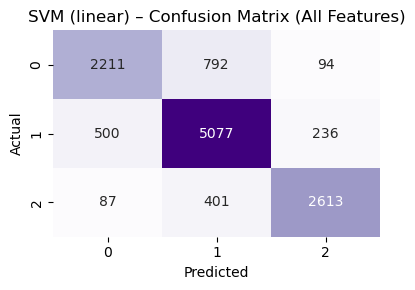


Kernel: poly
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params: {'svc__C': 10, 'svc__degree': 3, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}
Best CV F1: 0.861

Performance on Train:
F1-score : 0.886
Precision: 0.899
Recall   : 0.876
Accuracy : 0.892

Performance on Test:
F1-score : 0.867
Precision: 0.882
Recall   : 0.855
Accuracy : 0.872
Accuracy Gap (Train - Test): 0.0193
No substantial overfitting detected.

Classification report (Test):
              precision    recall  f1-score   support

           0       0.90      0.79      0.84      3097
           1       0.85      0.93      0.89      5813
           2       0.89      0.85      0.87      3101

    accuracy                           0.87     12011
   macro avg       0.88      0.86      0.87     12011
weighted avg       0.87      0.87      0.87     12011

Confusion Matrix (Test):
[[2449  560   88]
 [ 185 5408  220]
 [  85  395 2621]]


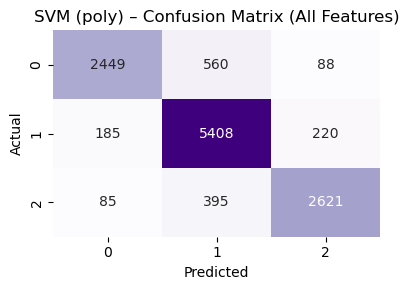


Kernel: rbf
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'svc__C': 50, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
Best CV F1: 0.883

Performance on Train:
F1-score : 0.901
Precision: 0.910
Recall   : 0.893
Accuracy : 0.906

Performance on Test:
F1-score : 0.887
Precision: 0.897
Recall   : 0.879
Accuracy : 0.892
Accuracy Gap (Train - Test): 0.0136
No substantial overfitting detected.

Classification report (Test):
              precision    recall  f1-score   support

           0       0.89      0.84      0.86      3097
           1       0.88      0.94      0.91      5813
           2       0.92      0.86      0.89      3101

    accuracy                           0.89     12011
   macro avg       0.90      0.88      0.89     12011
weighted avg       0.89      0.89      0.89     12011

Confusion Matrix (Test):
[[2594  415   88]
 [ 216 5449  148]
 [  92  337 2672]]


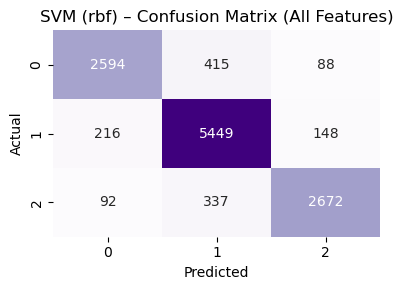


Summary (All Features):
   Kernel     CV_F1  Train_F1   Test_F1  Train_Accuracy  Test_Accuracy
0  linear  0.818804  0.818690  0.818380        0.824608       0.824328
1    poly  0.860951  0.885947  0.866595        0.891625       0.872367
2     rbf  0.883431  0.900587  0.887084        0.905720       0.892099


In [114]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score
)

# ==========================================
# 1. Prepare X and y
# ==========================================

X = x.copy().astype(float)

if isinstance(y, pd.Series):
    y_model = y.astype(int).copy()
else:
    y_model = pd.Series(y).astype(int)

X = X.reset_index(drop=True)
y_model = y_model.reset_index(drop=True)

# ==========================================
# 2. Train/Test split
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y_model,
    test_size=0.3,
    random_state=42,
    stratify=y_model
)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

# ==========================================
# 3. Base pipeline + CV
# ==========================================

base_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC())
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================
# 4. Parameter grids
# ==========================================

kernel_param_grids = {
    "linear": {
        "svc__kernel": ["linear"],
        "svc__C": [0.1, 1, 10, 50]
    },
    "poly": {
        "svc__kernel": ["poly"],
        "svc__C": [0.1, 1, 10],
        "svc__degree": [2, 3, 4],
        "svc__gamma": ["scale", "auto"]
    },
    "rbf": {
        "svc__kernel": ["rbf"],
        "svc__C": [0.1, 1, 10, 50],
        "svc__gamma": ["scale", "auto", 0.01, 0.1]
    }
}

best_models = {}
results_list = []

# ==========================================
# 5. Grid search per kernel
# ==========================================

for kern, param_grid in kernel_param_grids.items():
    print("\n" + "=" * 50)
    print(f"Kernel: {kern}")

    grid_svm = GridSearchCV(
        estimator=base_pipeline,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    grid_svm.fit(x_train, y_train)
    best_models[kern] = grid_svm.best_estimator_

    print("Best params:", grid_svm.best_params_)
    print(f"Best CV F1: {grid_svm.best_score_:.3f}")

    # Predictions
    y_train_pred_svm = best_models[kern].predict(x_train)
    y_test_pred_svm = best_models[kern].predict(x_test)

    # Metrics
    train_f1 = f1_score(y_train, y_train_pred_svm, average="macro")
    test_f1 = f1_score(y_test, y_test_pred_svm, average="macro")

    train_prec = precision_score(y_train, y_train_pred_svm, average="macro", zero_division=0)
    test_prec = precision_score(y_test, y_test_pred_svm, average="macro", zero_division=0)

    train_rec = recall_score(y_train, y_train_pred_svm, average="macro", zero_division=0)
    test_rec = recall_score(y_test, y_test_pred_svm, average="macro", zero_division=0)

    train_acc = accuracy_score(y_train, y_train_pred_svm)
    test_acc = accuracy_score(y_test, y_test_pred_svm)

    print("\nPerformance on Train:")
    print(f"F1-score : {train_f1:.3f}")
    print(f"Precision: {train_prec:.3f}")
    print(f"Recall   : {train_rec:.3f}")
    print(f"Accuracy : {train_acc:.3f}")

    print("\nPerformance on Test:")
    print(f"F1-score : {test_f1:.3f}")
    print(f"Precision: {test_prec:.3f}")
    print(f"Recall   : {test_rec:.3f}")
    print(f"Accuracy : {test_acc:.3f}")
    print(f"Accuracy Gap (Train - Test): {train_acc - test_acc:.4f}")

    if train_acc - test_acc > 0.03:
        print("Possible overfitting detected.")
    else:
        print("No substantial overfitting detected.")

    print("\nClassification report (Test):")
    print(classification_report(y_test, y_test_pred_svm))

    results_list.append({
        "Kernel": kern,
        "CV_F1": grid_svm.best_score_,
        "Train_F1": train_f1,
        "Test_F1": test_f1,
        "Train_Accuracy": train_acc,
        "Test_Accuracy": test_acc
    })

    cm = confusion_matrix(y_test, y_test_pred_svm)
    print("Confusion Matrix (Test):")
    print(cm)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Purples")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"SVM ({kern}) – Confusion Matrix (All Features)")
    plt.tight_layout()
    plt.show()

# ==========================================
# 6. Summary table
# ==========================================

svm_results_all = pd.DataFrame(results_list)
print("\nSummary (All Features):")
print(svm_results_all)

## Remove non-significant variables

Train shape: (28023, 5)
Test shape: (12011, 5)

Kernel: linear
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'svc__C': 1, 'svc__kernel': 'linear'}
Best CV F1: 0.818

Performance on Train:
F1-score : 0.818
Precision: 0.829
Recall   : 0.810
Accuracy : 0.824

Performance on Test:
F1-score : 0.819
Precision: 0.830
Recall   : 0.811
Accuracy : 0.825
Accuracy Gap (Train - Test): -0.0013
No substantial overfitting detected.

Classification report (Test):
              precision    recall  f1-score   support

           0       0.79      0.71      0.75      3097
           1       0.81      0.87      0.84      5813
           2       0.89      0.84      0.87      3101

    accuracy                           0.83     12011
   macro avg       0.83      0.81      0.82     12011
weighted avg       0.83      0.83      0.82     12011

Confusion Matrix (Test):
[[2213  793   91]
 [ 497 5084  232]
 [  91  393 2617]]


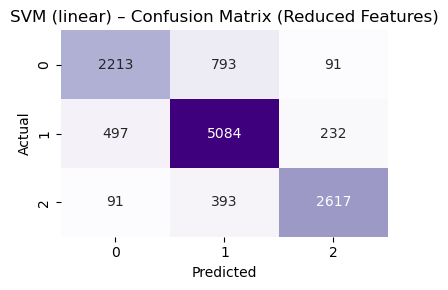


Kernel: poly
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params: {'svc__C': 10, 'svc__degree': 3, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}
Best CV F1: 0.870

Performance on Train:
F1-score : 0.873
Precision: 0.898
Recall   : 0.857
Accuracy : 0.880

Performance on Test:
F1-score : 0.874
Precision: 0.898
Recall   : 0.858
Accuracy : 0.881
Accuracy Gap (Train - Test): -0.0005
No substantial overfitting detected.

Classification report (Test):
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      3097
           1       0.84      0.96      0.90      5813
           2       0.93      0.79      0.86      3101

    accuracy                           0.88     12011
   macro avg       0.90      0.86      0.87     12011
weighted avg       0.89      0.88      0.88     12011

Confusion Matrix (Test):
[[2550  469   78]
 [ 135 5569  109]
 [  87  555 2459]]


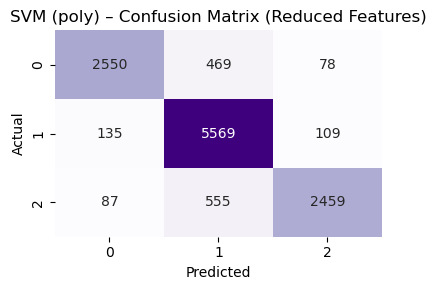


Kernel: rbf
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'svc__C': 50, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Best CV F1: 0.914

Performance on Train:
F1-score : 0.920
Precision: 0.926
Recall   : 0.915
Accuracy : 0.925

Performance on Test:
F1-score : 0.917
Precision: 0.924
Recall   : 0.912
Accuracy : 0.922
Accuracy Gap (Train - Test): 0.0032
No substantial overfitting detected.

Classification report (Test):
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      3097
           1       0.92      0.96      0.94      5813
           2       0.93      0.89      0.91      3101

    accuracy                           0.92     12011
   macro avg       0.92      0.91      0.92     12011
weighted avg       0.92      0.92      0.92     12011

Confusion Matrix (Test):
[[2751  260   86]
 [ 128 5557  128]
 [  90  250 2761]]


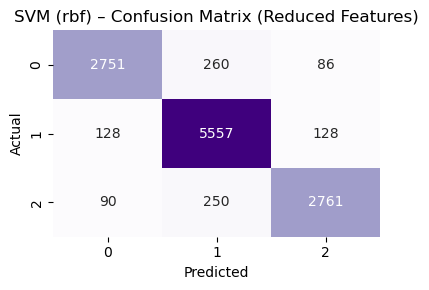


Summary (Reduced Features):
   Kernel     CV_F1  Train_F1   Test_F1  Train_Accuracy  Test_Accuracy
0  linear  0.817728  0.818191  0.819450        0.824109       0.825410
1    poly  0.870478  0.873448  0.874172        0.880241       0.880693
2     rbf  0.914034  0.919989  0.917122        0.924812       0.921572


In [132]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score
)

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

X_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy().astype(float)

if isinstance(y, pd.Series):
    y_model = y.astype(int).copy()
else:
    y_model = pd.Series(y).astype(int)

X_reduced = X_reduced.reset_index(drop=True)
y_model = y_model.reset_index(drop=True)

# ==========================================
# 2. Train/Test split
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    X_reduced,
    y_model,
    test_size=0.3,
    random_state=42,
    stratify=y_model
)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

# ==========================================
# 3. Base pipeline + CV
# ==========================================

base_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC())
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================
# 4. Parameter grids
# ==========================================

kernel_param_grids = {
    "linear": {
        "svc__kernel": ["linear"],
        "svc__C": [0.1, 1, 10, 50]
    },
    "poly": {
        "svc__kernel": ["poly"],
        "svc__C": [0.1, 1, 10],
        "svc__degree": [2, 3, 4],
        "svc__gamma": ["scale", "auto"]
    },
    "rbf": {
        "svc__kernel": ["rbf"],
        "svc__C": [0.1, 1, 10, 50],
        "svc__gamma": ["scale", "auto", 0.01, 0.1]
    }
}

best_models = {}
results_list = []

# ==========================================
# 5. Grid search per kernel
# ==========================================

for kern, param_grid in kernel_param_grids.items():
    print("\n" + "=" * 50)
    print(f"Kernel: {kern}")

    grid_svm = GridSearchCV(
        estimator=base_pipeline,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    grid_svm.fit(x_train, y_train)
    best_models[kern] = grid_svm.best_estimator_

    print("Best params:", grid_svm.best_params_)
    print(f"Best CV F1: {grid_svm.best_score_:.3f}")

    # Predictions
    y_train_pred_svm = best_models[kern].predict(x_train)
    y_test_pred_svm = best_models[kern].predict(x_test)

    # Metrics
    train_f1 = f1_score(y_train, y_train_pred_svm, average="macro")
    test_f1 = f1_score(y_test, y_test_pred_svm, average="macro")

    train_prec = precision_score(y_train, y_train_pred_svm, average="macro", zero_division=0)
    test_prec = precision_score(y_test, y_test_pred_svm, average="macro", zero_division=0)

    train_rec = recall_score(y_train, y_train_pred_svm, average="macro", zero_division=0)
    test_rec = recall_score(y_test, y_test_pred_svm, average="macro", zero_division=0)

    train_acc = accuracy_score(y_train, y_train_pred_svm)
    test_acc = accuracy_score(y_test, y_test_pred_svm)

    print("\nPerformance on Train:")
    print(f"F1-score : {train_f1:.3f}")
    print(f"Precision: {train_prec:.3f}")
    print(f"Recall   : {train_rec:.3f}")
    print(f"Accuracy : {train_acc:.3f}")

    print("\nPerformance on Test:")
    print(f"F1-score : {test_f1:.3f}")
    print(f"Precision: {test_prec:.3f}")
    print(f"Recall   : {test_rec:.3f}")
    print(f"Accuracy : {test_acc:.3f}")
    print(f"Accuracy Gap (Train - Test): {train_acc - test_acc:.4f}")

    if train_acc - test_acc > 0.03:
        print("Possible overfitting detected.")
    else:
        print("No substantial overfitting detected.")

    print("\nClassification report (Test):")
    print(classification_report(y_test, y_test_pred_svm))

    results_list.append({
        "Kernel": kern,
        "CV_F1": grid_svm.best_score_,
        "Train_F1": train_f1,
        "Test_F1": test_f1,
        "Train_Accuracy": train_acc,
        "Test_Accuracy": test_acc
    })

    cm = confusion_matrix(y_test, y_test_pred_svm)
    print("Confusion Matrix (Test):")
    print(cm)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Purples")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"SVM ({kern}) – Confusion Matrix (Reduced Features)")
    plt.tight_layout()
    plt.show()

# ==========================================
# 6. Summary table
# ==========================================

svm_results_reduced = pd.DataFrame(results_list)
print("\nSummary (Reduced Features):")
print(svm_results_reduced)

# K-Means Clustering- Part 9

To identify the optimal number of clusters , K-means clustering was estimated for values of K ranging from 2 to 10. 
For each configuration, the silhouette score was calculated, and the K with the highest silhouette score was selected as the optimal number of clusters. 

### *1) Standardization + model running*

In [91]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score 

K=2, Silhouette Score= 0.0777
K=3, Silhouette Score= 0.0994
K=4, Silhouette Score= 0.1193
K=5, Silhouette Score= 0.1253
K=6, Silhouette Score= 0.1146
K=7, Silhouette Score= 0.1040
K=8, Silhouette Score= 0.0931
K=9, Silhouette Score= 0.1048
K=10, Silhouette Score= 0.0999

Best K: 5
Best Silhouette Score: 0.1253


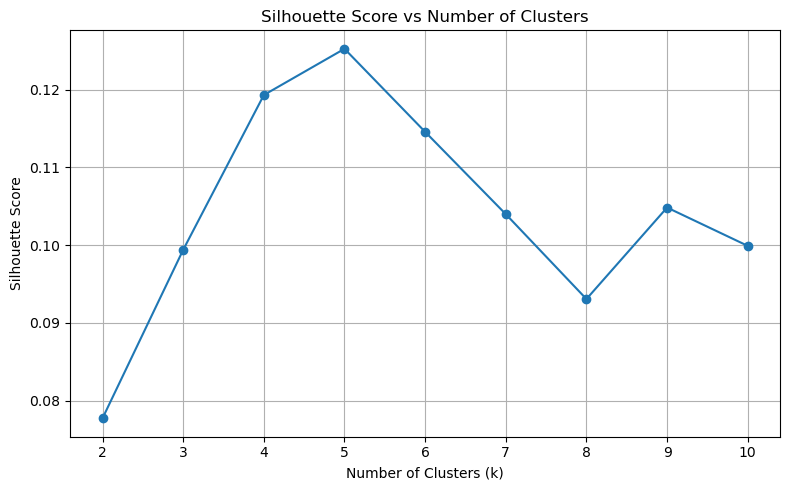

In [160]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

K_values= range(2,11)
silhouette_scores=[]

for K in K_values:
    kmeans= KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
    )

    cluster_labels= kmeans.fit_predict(X_scaled)
    score= silhouette_score(X_scaled,cluster_labels)
    silhouette_scores.append(score)

    print(f"K={K}, Silhouette Score= {score:.4f}")

best_k= K_values[np.argmax(silhouette_scores)]
best_score=max(silhouette_scores)

print("\nBest K:", best_k)
print("Best Silhouette Score:", round(best_score,4))

plt.figure(figsize=(8,5))
plt.plot(K_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.xticks(list(K_values))
plt.grid(True)
plt.tight_layout()
plt.show

Kmeans_final= KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10 
)

final_clusters= Kmeans_final.fit_predict(X_scaled)

##### How to interpret?
- Close to 1 = good and separated clusters
- close to 0 = weak separation
- Negative= problematic clustering

### *Compare Clusters to y*

In [166]:
clusters_vs_target= pd.crosstab(
    final_clusters,
    y,
    rownames=["Cluster"],
    colnames=["True Engagemant Level"]
)

print("\nCluster vs True Target:")
print(clusters_vs_target)


Cluster vs True Target:
True Engagemant Level     0     1     2
Cluster                                
0                      2945  5428  2937
1                      1825  3526  1875
2                      1881  3485  1799
3                      1036  1889  1010
4                      2637  5046  2715


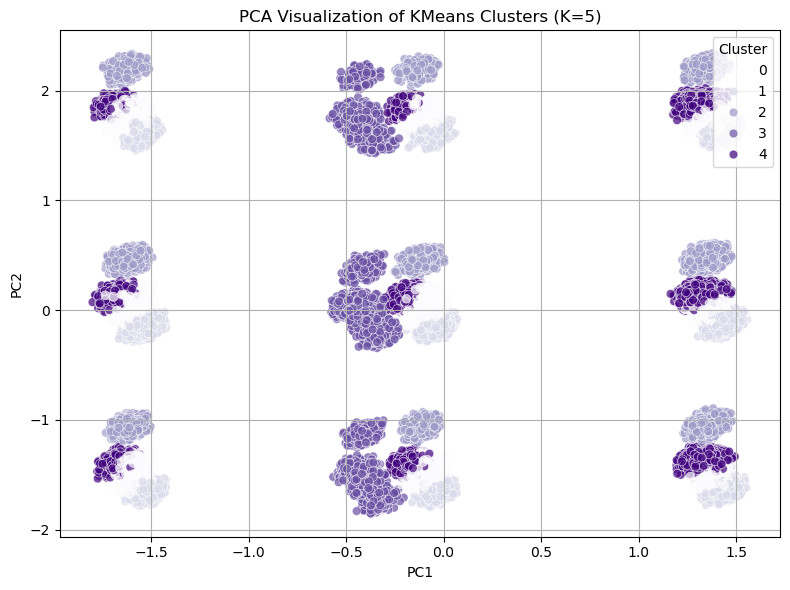

Cluster Profiling:


,age,play_time_hours,sessions_per_week,avg_session_duration_minutes,player_level,achievements_unlocked,gender_male,location_europe,location_other,location_usa,game_genre_action,game_genre_rpg,game_genre_sports,game_genre_strategy,in_game_purchases_1,game_difficulty_hard,game_difficulty_medium
Cluster,,,,,,,,,,,,,,,,,
0,32.016,11.944,9.515,94.728,49.376,24.371,0.601,0.428,0.0,0.288,0.000,0.0,0.643,0.0,0.202,0.197,0.301
1,31.976,12.083,9.504,95.688,49.902,24.640,0.597,0.326,0.0,0.450,0.000,0.0,0.000,1.0,0.209,0.195,0.307
2,31.844,12.004,9.418,93.618,49.514,24.616,0.596,0.331,0.0,0.443,0.000,1.0,0.000,0.0,0.200,0.212,0.297
3,31.962,12.061,9.442,94.944,50.182,24.155,0.598,0.000,1.0,0.000,0.201,0.2,0.197,0.2,0.193,0.196,0.304
4,32.092,12.071,9.450,94.991,49.686,24.695,0.598,0.234,0.0,0.607,0.697,0.0,0.000,0.0,0.198,0.200,0.294


In [172]:
# ==========================================
# 1. שימוש רק במשתנים המסבירים
# ==========================================

X = x.copy()   # רק המשתנים המסבירים

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 2. KMeans עם K האופטימלי
# ==========================================

kmeans = KMeans(
    n_clusters=best_k,   # ה-K שמצאנו קודם
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# הוספת הקלאסטרים לדאטה
df_clusters = X.copy()
df_clusters["Cluster"] = clusters

# ==========================================
# 3. PCA – הפחתת ממדים ל-2
# ==========================================

pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

df_plot = pd.DataFrame({
    "PC1": pca_components[:,0],
    "PC2": pca_components[:,1],
    "Cluster": clusters
})

# ==========================================
# 4. גרף PCA עם הקלאסטרים
# ==========================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_plot,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Purples",
    alpha=0.7,
    s=40
)

plt.title(f"PCA Visualization of KMeans Clusters (K={best_k})")
plt.legend(title="Cluster")
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 5. Cluster Profiling
# ==========================================

cluster_profile = df_clusters.groupby("Cluster").mean().round(3)

print("Cluster Profiling:")
cluster_profile

### *PCA visualization of Clusters*
The PCA projection provides a two-dimensional representation of the dataset after dimensionality reduction, where each point represents an observation and colors indicate the clusters assigned by the K-means algorithm. The visualization reveals several dense groups of observations, which reflect repeated combinations of feature values within the dataset. However, the clusters are not clearly separated in the feature space, and substantial overlap between cluster colors can be observed. This suggests that although local groupings exist, the explanatory variables do not naturally partition the data into well-defined clusters.

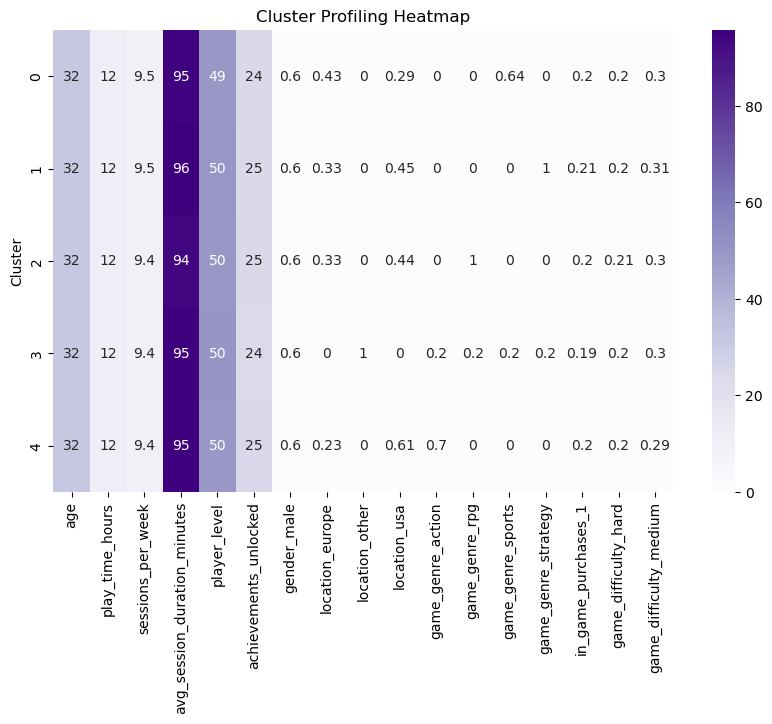

In [176]:
plt.figure(figsize=(10,6))
sns.heatmap(cluster_profile, cmap="Purples", annot=True)
plt.title("Cluster Profiling Heatmap")
plt.show()


### *Cluster Profiling heatmap Interpretation
The cluster profiling heatmap presents the average values of each explanatory variable within the identified clusters. The results indicate that the clusters share very similar characteristics across most variables. Key behavioral variables such as play time, session duration, and player level display relatively consistent values across clusters, suggesting that the clusters do not represent substantially different player profiles. This further supports the observation that the dataset does not contain strongly distinct natural segments.



### *K-mean Clustering Interpretation*
Unsupervised clustering techniques were applied in order to explore whether the observations naturally form distinct groups based on the explanatory variables. K-means clustering was first implemented and the optimal number of clusters was evaluated using the silhouette score. The resulting silhouette values were relatively low, suggesting weak separation between clusters. Visualization of the clusters using PCA further indicated that although some dense regions of observations appear, the clusters are not clearly separated in the feature space.

Hierarchical clustering was also examined to further explore the potential grouping structure in the data. However, the results were consistent with the K-means findings, indicating that the dataset does not exhibit strong natural segmentation. The cluster profiling analysis additionally revealed that the clusters share very similar average values across most explanatory variables.

Overall, the clustering analysis suggests that player engagement levels do not emerge as clearly separable groups based solely on the observed features. These findings highlight the importance of supervised learning models for predicting engagement levels, as the underlying structure of the data does not naturally divide into distinct clusters.

## Remove non-significant variables-K-mean Clustering

K=2, Silhouette Score = 0.2786
K=3, Silhouette Score = 0.1954
K=4, Silhouette Score = 0.1806
K=5, Silhouette Score = 0.1881
K=6, Silhouette Score = 0.1872
K=7, Silhouette Score = 0.1827
K=8, Silhouette Score = 0.1921
K=9, Silhouette Score = 0.1980
K=10, Silhouette Score = 0.2116

Best K: 2
Best Silhouette Score: 0.2786


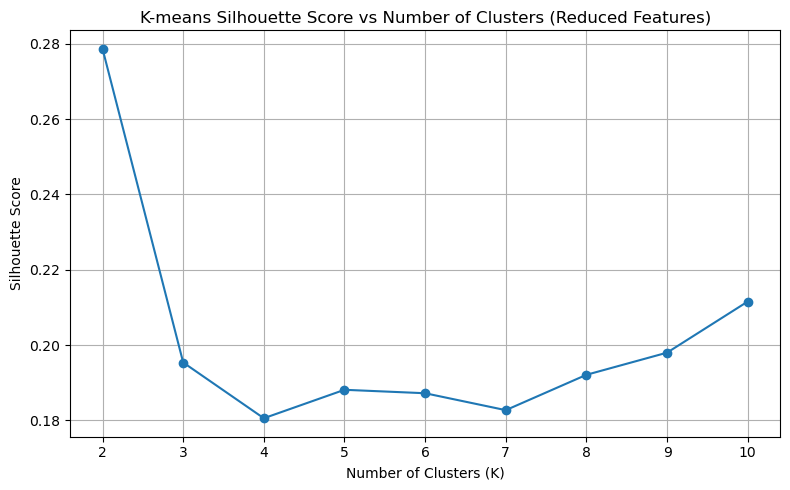

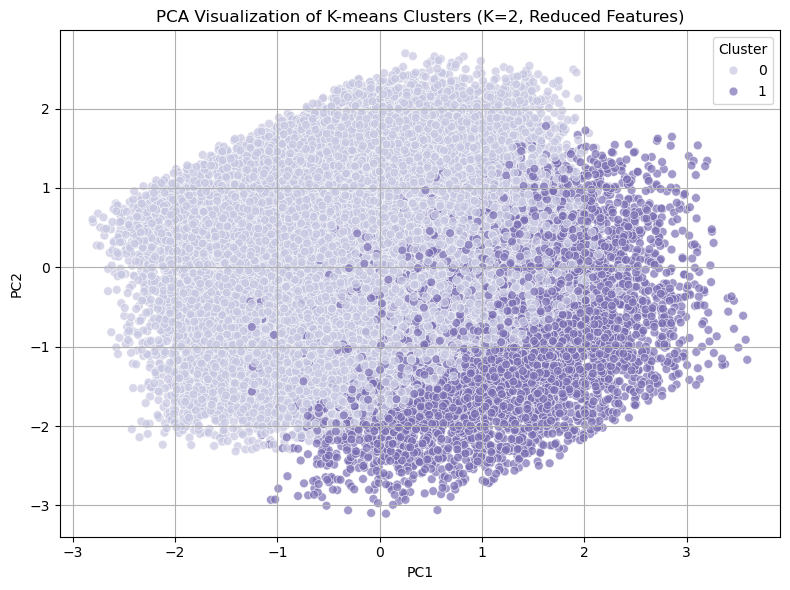


Cluster vs True Target:
True Engagement Level     0      1     2
Cluster                                 
0                      8287  15504  8202
1                      2037   3870  2134


In [62]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

X_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy()
X_reduced = X_reduced.astype(float)

# לוודא y מספרי
if isinstance(y, pd.Series):
    y_reduced = y.astype(int).copy()
else:
    y_reduced = pd.Series(y).astype(int)

# ==========================================
# 2. Standardization
# ==========================================

scaler = StandardScaler()
X_reduced_scaled = scaler.fit_transform(X_reduced)

# ==========================================
# 3. Find optimal K using silhouette
# ==========================================

K_values = range(2, 11)
silhouette_scores = []

for K in K_values:
    kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_reduced_scaled)
    score = silhouette_score(X_reduced_scaled, cluster_labels)
    silhouette_scores.append(score)
    print(f"K={K}, Silhouette Score = {score:.4f}")

best_k = K_values[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print("\nBest K:", best_k)
print("Best Silhouette Score:", round(best_score, 4))

# ==========================================
# 4. Plot silhouette vs K
# ==========================================

plt.figure(figsize=(8,5))
plt.plot(K_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-means Silhouette Score vs Number of Clusters (Reduced Features)")
plt.xticks(list(K_values))
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# 5. Final K-means with best K
# ==========================================

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
final_clusters = kmeans_final.fit_predict(X_reduced_scaled)

# ==========================================
# 6. PCA plot
# ==========================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_reduced_scaled)

df_plot = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": final_clusters
})

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_plot,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Purples",
    alpha=0.7,
    s=40
)

plt.title(f"PCA Visualization of K-means Clusters (K={best_k}, Reduced Features)")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# 7. Compare clusters to true target
# ==========================================

clusters_vs_target = pd.crosstab(
    final_clusters,
    y_reduced,
    rownames=["Cluster"],
    colnames=["True Engagement Level"]
)

print("\nCluster vs True Target:")
print(clusters_vs_target)

# Hierarchical Clustering

Full X shape: (40034, 17)
Full y shape: (40034,)
Sample X shape: (2000, 17)
Sample y shape: (2000,)
K=2, Silhouette = 0.1362
K=3, Silhouette = 0.0776
K=4, Silhouette = 0.0891
K=5, Silhouette = 0.0967
K=6, Silhouette = 0.1006
K=7, Silhouette = 0.1030
K=8, Silhouette = 0.0809
K=9, Silhouette = 0.0637
K=10, Silhouette = 0.0663

Optimal K = 2
Best Silhouette Score = 0.1362
Optimal cut-off distance = 67.1333


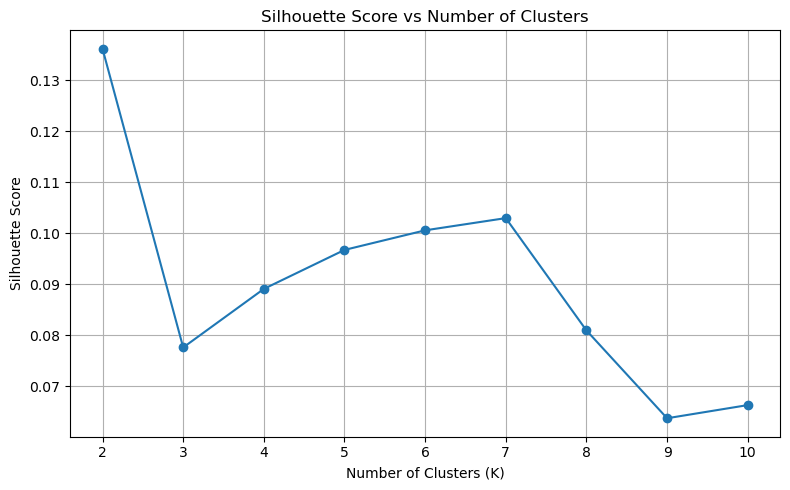

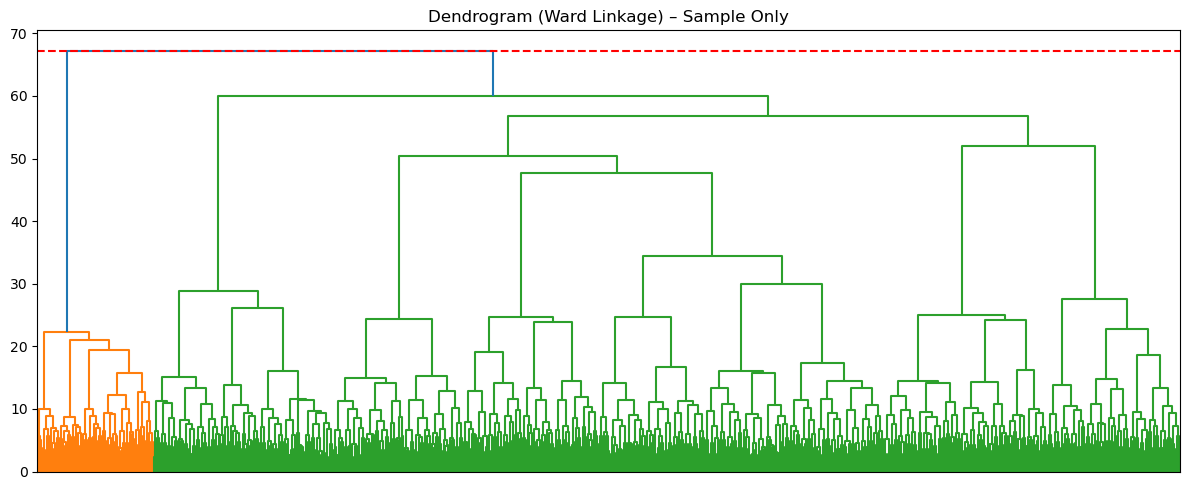

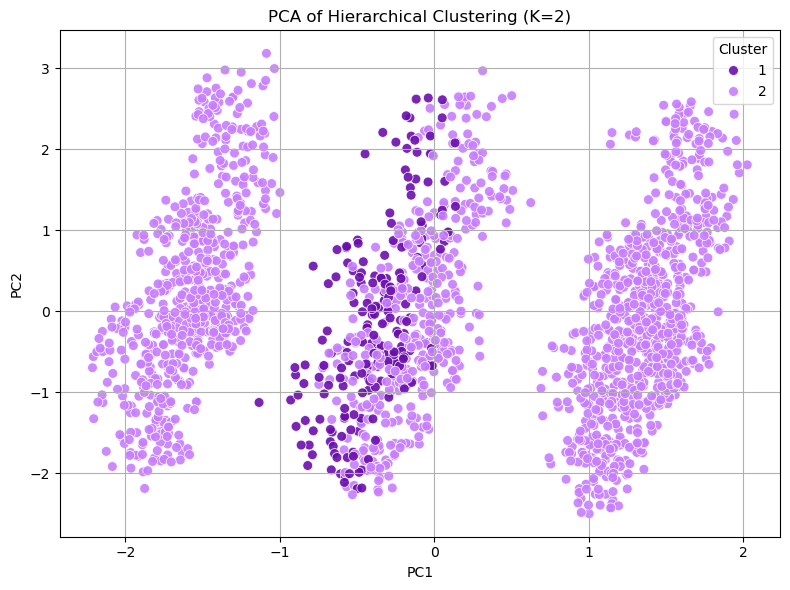


Cluster vs True Target:
True Engagement Level    0    1    2
Cluster                             
1                       54  103   47
2                      453  881  462


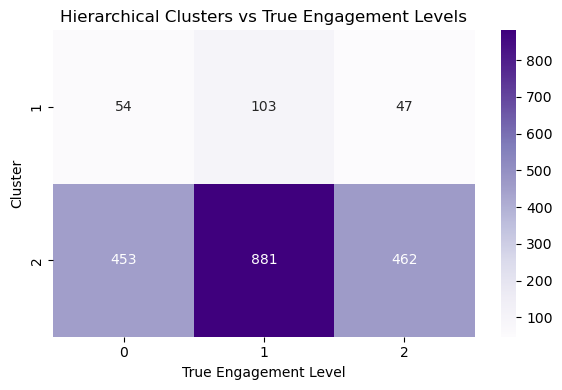

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# ======================================
# 1. Prepare X and y
# ======================================

X = x.copy().astype(float)

# להפוך את y ל-Series כדי שנוכל להשתמש ב-index
if isinstance(y, pd.Series):
    y_series = y.copy()
else:
    y_series = pd.Series(y)

# איפוס אינדקסים כדי למנוע חוסר התאמה
X = X.reset_index(drop=True)
y_series = y_series.reset_index(drop=True)

print("Full X shape:", X.shape)
print("Full y shape:", y_series.shape)

# ======================================
# 2. Random sample (for speed)
# ======================================

sample_size = 2000
X_sample = X.sample(n=sample_size, random_state=42)

# משיכת אותן שורות מ-y לפי האינדקס של X_sample
y_sample = y_series.loc[X_sample.index]

print("Sample X shape:", X_sample.shape)
print("Sample y shape:", y_sample.shape)

# ======================================
# 3. Standardization
# ======================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

# ======================================
# 4. Hierarchical Linkage (Ward)
# ======================================

linked = linkage(X_scaled, method="ward")

# ======================================
# 5. Silhouette analysis for K = 2..10
# ======================================

range_n_clusters = range(2, 11)
silhouette_scores = []

for n_clusters in range_n_clusters:
    clusters = fcluster(linked, t=n_clusters, criterion='maxclust')

    if len(np.unique(clusters)) > 1:
        score = silhouette_score(X_scaled, clusters)
    else:
        score = np.nan

    silhouette_scores.append(score)
    print(f"K={n_clusters}, Silhouette = {score:.4f}")

optimal_k = range_n_clusters[np.nanargmax(silhouette_scores)]
best_sil = np.nanmax(silhouette_scores)

print(f"\nOptimal K = {optimal_k}")
print(f"Best Silhouette Score = {best_sil:.4f}")

# ======================================
# 6. Optimal cut-off distance
# ======================================

optimal_cut = linked[-(optimal_k - 1), 2] - 0.001
print(f"Optimal cut-off distance = {optimal_cut:.4f}")

final_clusters = fcluster(linked, t=optimal_cut, criterion='distance')

# ======================================
# 7. Silhouette plot
# ======================================

plt.figure(figsize=(8, 5))
plt.plot(list(range_n_clusters), silhouette_scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()

# ======================================
# 8. Dendrogram
# ======================================

plt.figure(figsize=(12, 5))
plt.title("Dendrogram (Ward Linkage) – Sample Only")

dendrogram(
    linked,
    no_labels=True,
    color_threshold=optimal_cut
)

plt.axhline(y=optimal_cut, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# ======================================
# 9. PCA Visualization
# ======================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=final_clusters,
    palette=["#6A0DAD", "#C77DFF"],  # 🎯 צבעים ברורים
    s=50,        # נקודות קצת יותר גדולות
    alpha=0.9    # פחות שקיפות
)

plt.title(f"PCA of Hierarchical Clustering (K={optimal_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)

plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


# ======================================
# 10. Compare clusters to true target
# ======================================

cluster_vs_target = pd.crosstab(
    final_clusters,
    y_sample,
    rownames=["Cluster"],
    colnames=["True Engagement Level"]
)

print("\nCluster vs True Target:")
print(cluster_vs_target)

plt.figure(figsize=(6, 4))
sns.heatmap(cluster_vs_target, annot=True, fmt="d", cmap="Purples")
plt.title("Hierarchical Clusters vs True Engagement Levels")
plt.tight_layout()
plt.show()

## Remove non-significant variables

Reduced X shape: (40034, 5)
Reduced y shape: (40034,)
Sample X shape: (2000, 5)
Sample y shape: (2000,)
K=2, Silhouette = 0.2753
K=3, Silhouette = 0.1738
K=4, Silhouette = 0.1567
K=5, Silhouette = 0.1383
K=6, Silhouette = 0.1390
K=7, Silhouette = 0.1448
K=8, Silhouette = 0.1490
K=9, Silhouette = 0.1484
K=10, Silhouette = 0.1443

Optimal K = 2
Best Silhouette Score = 0.2753
Optimal cut-off distance = 63.2918


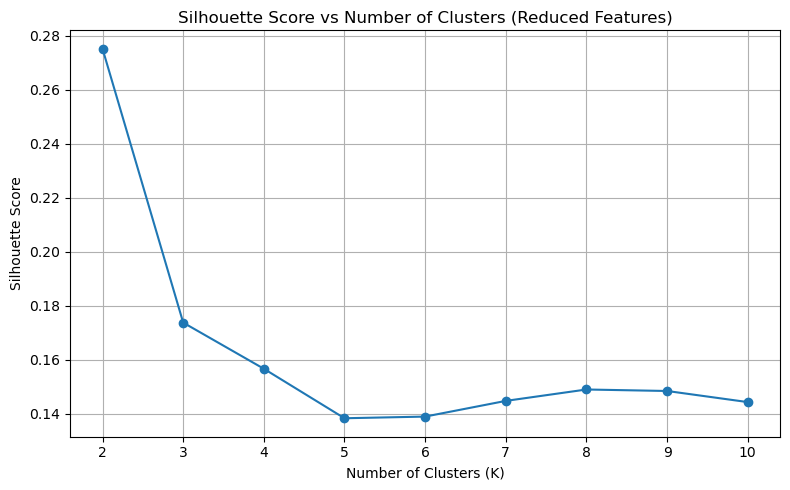

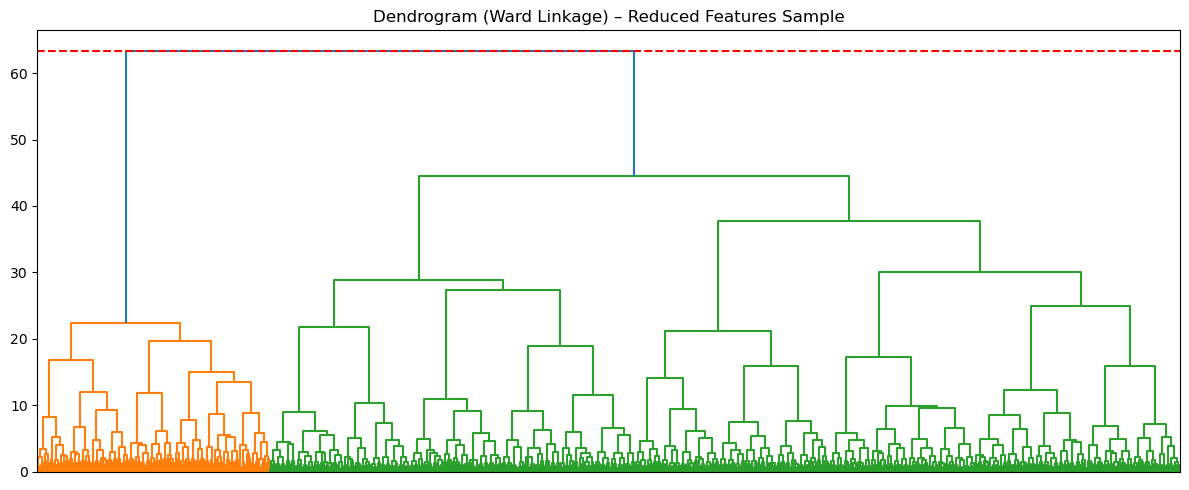

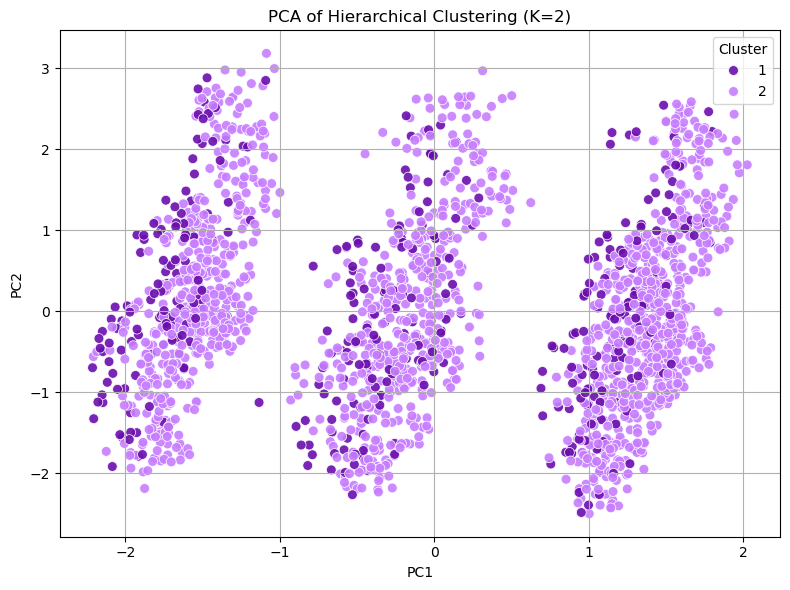


Cluster vs True Target:
True Engagement Level    0    1    2
Cluster                             
1                      107  195  105
2                      400  789  404


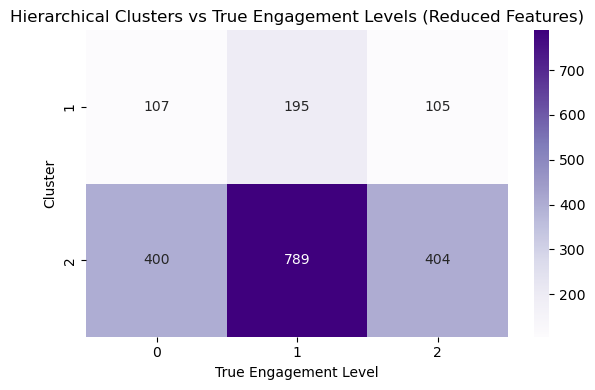

In [64]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# ======================================
# 1. Remove non-significant variables
# ======================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

X = x.drop(columns=variables_to_remove, errors='ignore').copy().astype(float)

if isinstance(y, pd.Series):
    y_series = y.copy()
else:
    y_series = pd.Series(y)

X = X.reset_index(drop=True)
y_series = y_series.reset_index(drop=True)

print("Reduced X shape:", X.shape)
print("Reduced y shape:", y_series.shape)

# ======================================
# 2. Random sample (for speed)
# ======================================

sample_size = 2000
X_sample = X.sample(n=sample_size, random_state=42)
y_sample = y_series.loc[X_sample.index]

print("Sample X shape:", X_sample.shape)
print("Sample y shape:", y_sample.shape)

# ======================================
# 3. Standardization
# ======================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

# ======================================
# 4. Hierarchical Linkage (Ward)
# ======================================

linked = linkage(X_scaled, method="ward")

# ======================================
# 5. Silhouette analysis for K = 2..10
# ======================================

range_n_clusters = range(2, 11)
silhouette_scores = []

for n_clusters in range_n_clusters:
    clusters = fcluster(linked, t=n_clusters, criterion='maxclust')

    if len(np.unique(clusters)) > 1:
        score = silhouette_score(X_scaled, clusters)
    else:
        score = np.nan

    silhouette_scores.append(score)
    print(f"K={n_clusters}, Silhouette = {score:.4f}")

optimal_k = range_n_clusters[np.nanargmax(silhouette_scores)]
best_sil = np.nanmax(silhouette_scores)

print(f"\nOptimal K = {optimal_k}")
print(f"Best Silhouette Score = {best_sil:.4f}")

# ======================================
# 6. Optimal cut-off distance
# ======================================

optimal_cut = linked[-(optimal_k - 1), 2] - 0.001
print(f"Optimal cut-off distance = {optimal_cut:.4f}")

final_clusters = fcluster(linked, t=optimal_cut, criterion='distance')

# ======================================
# 7. Silhouette plot
# ======================================

plt.figure(figsize=(8, 5))
plt.plot(list(range_n_clusters), silhouette_scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters (Reduced Features)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()

# ======================================
# 8. Dendrogram
# ======================================

plt.figure(figsize=(12, 5))
plt.title("Dendrogram (Ward Linkage) – Reduced Features Sample")

dendrogram(
    linked,
    no_labels=True,
    color_threshold=optimal_cut
)

plt.axhline(y=optimal_cut, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# ======================================
# 9. PCA Visualization
# ======================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=final_clusters,
    palette=["#6A0DAD", "#C77DFF"],  # 🎯 צבעים ברורים
    s=50,        # נקודות קצת יותר גדולות
    alpha=0.9    # פחות שקיפות
)

plt.title(f"PCA of Hierarchical Clustering (K={optimal_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)

plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


# ======================================
# 10. Compare clusters to true target
# ======================================

cluster_vs_target = pd.crosstab(
    final_clusters,
    y_sample,
    rownames=["Cluster"],
    colnames=["True Engagement Level"]
)

print("\nCluster vs True Target:")
print(cluster_vs_target)

plt.figure(figsize=(6, 4))
sns.heatmap(cluster_vs_target, annot=True, fmt="d", cmap="Purples")
plt.title("Hierarchical Clusters vs True Engagement Levels (Reduced Features)")
plt.tight_layout()
plt.show()

# Neural networks

In [118]:
x_train= x_train.astype(float)
x_test= x_test.astype(float)

In [120]:
y_train= y_train.astype(int)
y_test= y_test.astype(int)

In [122]:

print(x_train_scaled.dtype)
print(type(x_train_scaled))

print(y_train.dtype)
print(type(y_train))

float64
<class 'numpy.ndarray'>
int32
<class 'pandas.core.series.Series'>


In [124]:
n_features = x_train_scaled.shape[1]

In [74]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.initializers import GlorotNormal, GlorotUniform
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2

# מספר המשתנים המסבירים
n_features = x_train_scaled.shape[1]

# Define the model
model = Sequential([
    Input(shape=(n_features,)),  
   
    Dense(
        100,
        activation='sigmoid',
        kernel_initializer=GlorotNormal(),
        kernel_regularizer=L2(0.1)
    ),
    Dropout(0.2),

    Dense(
        3,
        activation='softmax',
        kernel_initializer=GlorotUniform()
    )
])

# Compile the model
model.compile(
    optimizer=SGD(learning_rate=0.03),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train_scaled, y_train,
    epochs=30,
    batch_size=10,
    validation_data=(x_test_scaled, y_test)
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Epoch 1/30
3203/3203 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.5296 - loss: 1.0887 - val_accuracy: 0.7515 - val_loss: 0.9015
Epoch 2/30
3203/3203 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.5867 - loss: 0.9742 - val_accuracy: 0.7872 - val_loss: 0.8583
Epoch 3/30
3203/3203 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.6029 - loss: 0.9583 - val_accuracy: 0.7140 - val_loss: 0.8442
Epoch 4/30
3203/3203 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.6154 - loss: 0.9413 - val_accuracy: 0.7119 - val_loss: 0.8473
Epoch 5/30
3203/3203 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.6227 - loss: 0.9338 - val_accuracy: 0.7225 - val_loss: 0.8323
Epoch 6/30
3203/3203 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6297 - loss: 0.9255 - val_accuracy: 0.7700 - val_loss: 0.8199
Epoch 7/30
3203/3203 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.6372 - loss: 0.9153 - val_accuracy: 0.7992 - val_loss: 0.8116
Epoch 8/30
3203/3203 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.6414 - loss: 0.9098 - 

Epoch 1/30
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7400 - loss: 0.7254 - val_accuracy: 0.8630 - val_loss: 0.5413
Epoch 2/30
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8300 - loss: 0.5561 - val_accuracy: 0.8791 - val_loss: 0.4627
Epoch 3/30
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8587 - loss: 0.4927 - val_accuracy: 0.8942 - val_loss: 0.4286
Epoch 4/30
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8686 - loss: 0.4650 - val_accuracy: 0.8983 - val_loss: 0.4139
Epoch 5/30
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8766 - loss: 0.4482 - val_accuracy: 0.9035 - val_loss: 0.4008
Epoch 6/30
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8793 - loss: 0.4422 - val_accuracy: 0.9058 - val_loss: 0.3962
Epoch 7/30
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8811 - loss: 0.4353 - val_accuracy: 0.9062 - val_loss: 0.3975
Epoch 8/30
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8855 - loss: 0.4271 - 

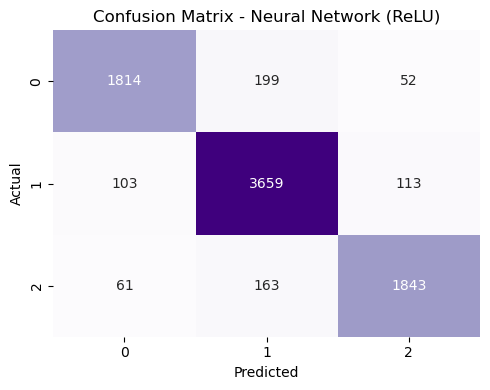

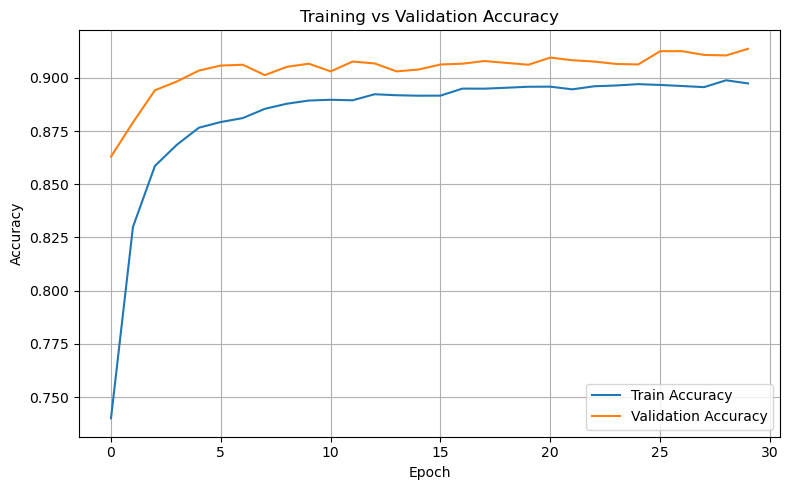

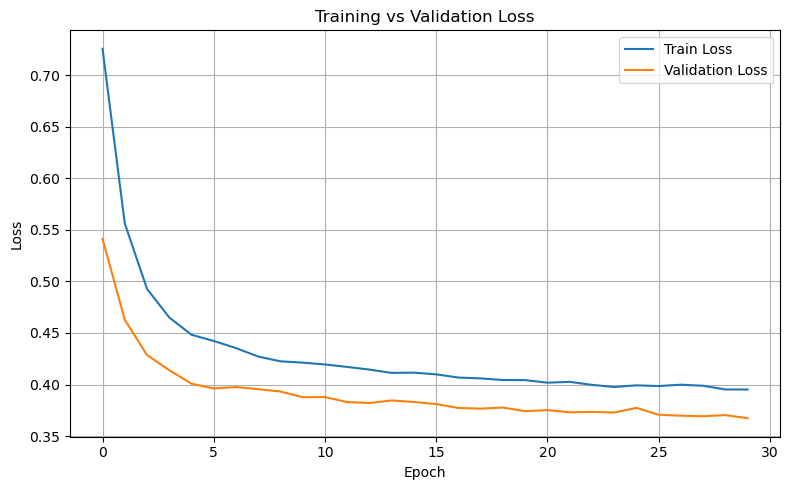

In [75]:
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import L2
from tensorflow.keras.initializers import GlorotNormal, GlorotUniform
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# ==========================================
# 1. Define the model
# ==========================================

n_features = x_train_scaled.shape[1]

model = Sequential([
    Input(shape=(n_features,)),

    Dense(
        64,
        activation='relu',
        kernel_initializer=GlorotNormal(),
        kernel_regularizer=L2(0.001)
    ),
    Dropout(0.2),

    Dense(
        32,
        activation='relu',
        kernel_initializer=GlorotNormal(),
        kernel_regularizer=L2(0.001)
    ),
    Dropout(0.2),

    Dense(
        3,
        activation='softmax',
        kernel_initializer=GlorotUniform()
    )
])

# ==========================================
# 2. Compile the model
# ==========================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# ==========================================
# 3. Train the model
# ==========================================

history = model.fit(
    x_train_scaled, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(x_test_scaled, y_test),
    verbose=1
)

# ==========================================
# 4. Evaluate
# ==========================================

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# ==========================================
# 5. Predictions
# ==========================================

y_prob = model.predict(x_test_scaled)
y_pred = np.argmax(y_prob, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==========================================
# 6. Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Neural Network (ReLU)")
plt.tight_layout()
plt.show()

# ==========================================
# 7. Accuracy Plot
# ==========================================

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# 8. Loss Plot
# ==========================================

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Epoch 1/30
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7747 - loss: 0.7177 - val_accuracy: 0.8701 - val_loss: 0.5255
Epoch 2/30
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8495 - loss: 0.5389 - val_accuracy: 0.8873 - val_loss: 0.4602
Epoch 3/30
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8662 - loss: 0.4855 - val_accuracy: 0.8953 - val_loss: 0.4299
Epoch 4/30
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8748 - loss: 0.4591 - val_accuracy: 0.8715 - val_loss: 0.4466
Epoch 5/30
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8783 - loss: 0.4444 - val_accuracy: 0.9010 - val_loss: 0.4048
Epoch 6/30
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8811 - loss: 0.4355 - val_accuracy: 0.9056 - val_loss: 0.3941
Epoch 7/30
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8839 - loss: 0.4257 - val_accuracy: 0.8978 - val_loss: 0.3961
Epoch 8/30
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8863 - loss: 0.4198 - 

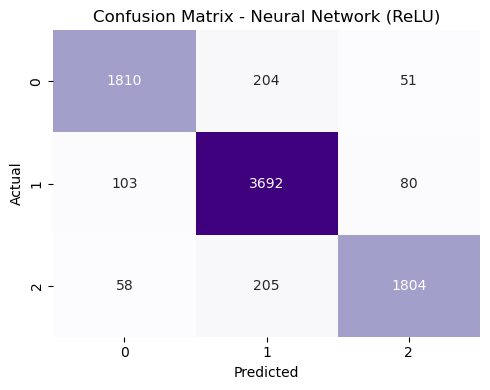

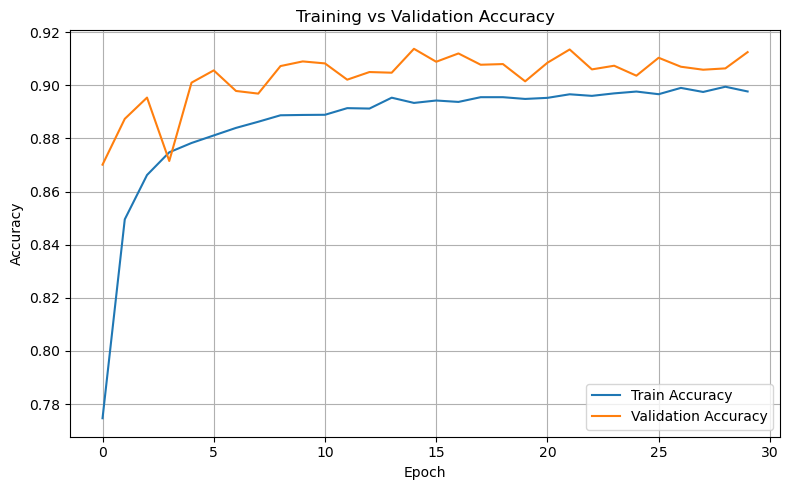

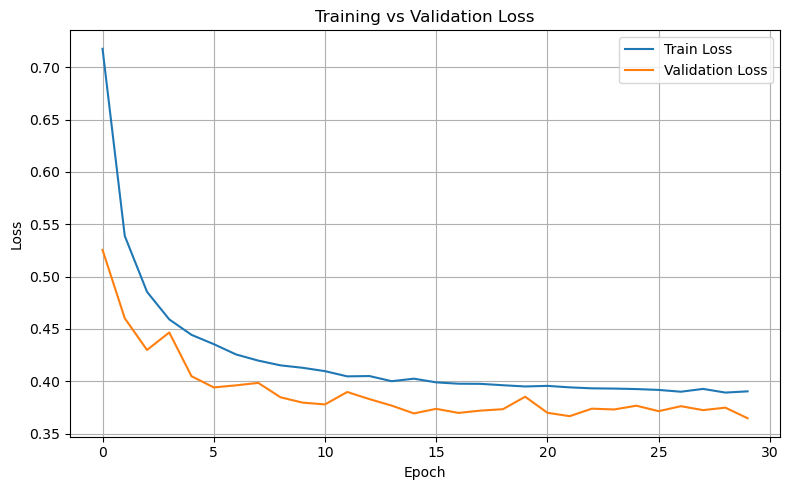

In [78]:
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import L2
from tensorflow.keras.initializers import GlorotNormal, GlorotUniform
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# ==========================================
# 1. Define the model
# ==========================================

n_features = x_train_scaled.shape[1]

model = Sequential([
    Input(shape=(n_features,)),

    Dense(
        128,
        activation='relu',
        kernel_initializer=GlorotNormal(),
        kernel_regularizer=L2(0.001)
    ),
    Dropout(0.3),

    Dense(
        64,
        activation='relu',
        kernel_initializer=GlorotNormal(),
        kernel_regularizer=L2(0.001)
    ),
    Dropout(0.2),
    
        Dense(
        32,
        activation='relu',
        kernel_initializer=GlorotNormal(),
        kernel_regularizer=L2(0.001)
    ),

    Dense(
        3,
        activation='softmax',
        kernel_initializer=GlorotUniform()
    )
])

# ==========================================
# 2. Compile the model
# ==========================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# ==========================================
# 3. Train the model
# ==========================================

history = model.fit(
    x_train_scaled, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(x_test_scaled, y_test),
    verbose=1
)

# ==========================================
# 4. Evaluate
# ==========================================

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# ==========================================
# 5. Predictions
# ==========================================

y_prob = model.predict(x_test_scaled)
y_pred = np.argmax(y_prob, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==========================================
# 6. Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Neural Network (ReLU)")
plt.tight_layout()
plt.show()

# ==========================================
# 7. Accuracy Plot
# ==========================================

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# 8. Loss Plot
# ==========================================

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Epoch 1/50
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6664 - loss: 0.8037 - val_accuracy: 0.8092 - val_loss: 0.5961
Epoch 2/50
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7904 - loss: 0.6170 - val_accuracy: 0.8496 - val_loss: 0.5143
Epoch 3/50
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8235 - loss: 0.5478 - val_accuracy: 0.8757 - val_loss: 0.4587
Epoch 4/50
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8432 - loss: 0.5093 - val_accuracy: 0.8920 - val_loss: 0.4338
Epoch 5/50
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8584 - loss: 0.4813 - val_accuracy: 0.9017 - val_loss: 0.4190
Epoch 6/50
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8661 - loss: 0.4652 - val_accuracy: 0.9027 - val_loss: 0.4100
Epoch 7/50
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8708 - loss: 0.4545 - val_accuracy: 0.9067 - val_loss: 0.4027
Epoch 8/50
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8733 - loss: 0.4471 - 

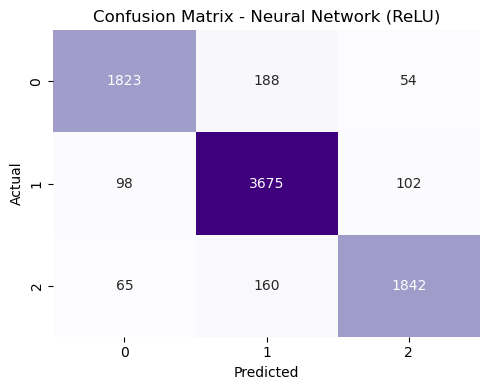

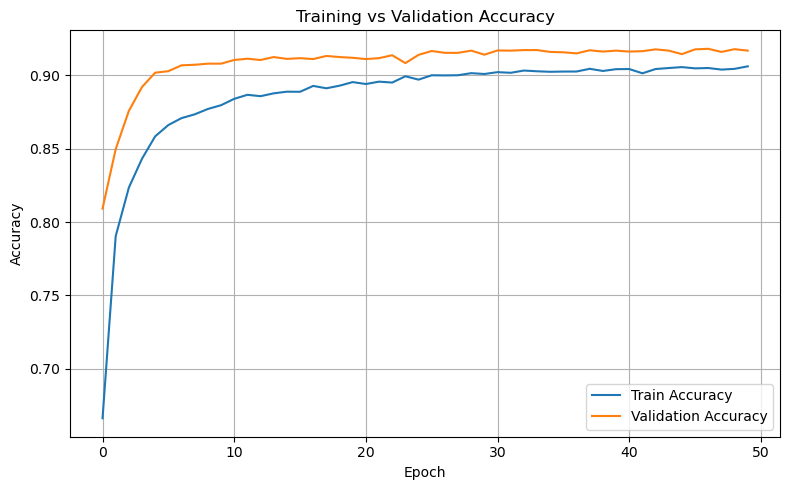

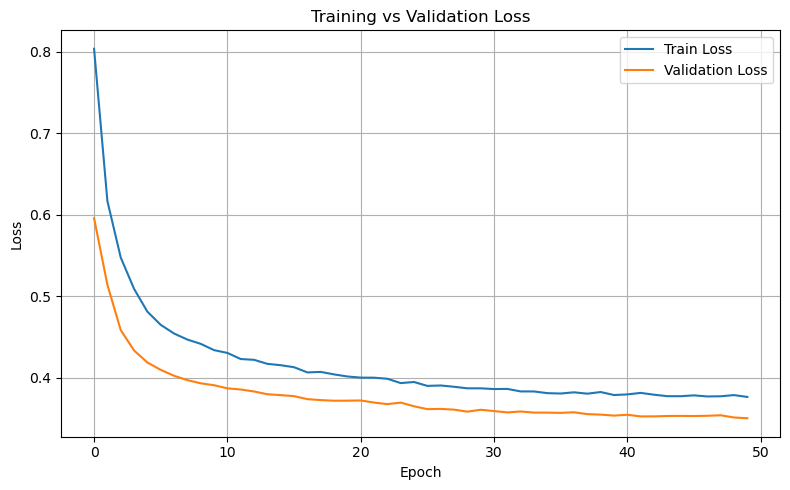

In [80]:
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import L2
from tensorflow.keras.initializers import GlorotNormal, GlorotUniform
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# ==========================================
# 1. Define the model
# ==========================================

n_features = x_train_scaled.shape[1]

model = Sequential([
    Input(shape=(n_features,)),

    Dense(
        64,
        activation='relu',
        kernel_initializer=GlorotNormal(),
        kernel_regularizer=L2(0.0005)
    ),
    Dropout(0.2),

    Dense(
        32,
        activation='relu',
        kernel_initializer=GlorotNormal(),
        kernel_regularizer=L2(0.0005)
    ),
    Dropout(0.2),

    Dense(
        3,
        activation='softmax',
        kernel_initializer=GlorotUniform()
    )
])

# ==========================================
# 2. Compile the model
# ==========================================

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# ==========================================
# 3. Train the model
# ==========================================

history = model.fit(
    x_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(x_test_scaled, y_test),
    verbose=1
)

# ==========================================
# 4. Evaluate
# ==========================================

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# ==========================================
# 5. Predictions
# ==========================================

y_prob = model.predict(x_test_scaled)
y_pred = np.argmax(y_prob, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==========================================
# 6. Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Neural Network (ReLU)")
plt.tight_layout()
plt.show()

# ==========================================
# 7. Accuracy Plot
# ==========================================

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# 8. Loss Plot
# ==========================================

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [208]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping

n_features = x_train_scaled.shape[1]

model = Sequential([
    Input(shape=(n_features,)),
    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),
    Dense(32, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/50
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7585 - loss: 0.6698 - val_accuracy: 0.8591 - val_loss: 0.4988
Epoch 2/50
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8483 - loss: 0.5045 - val_accuracy: 0.8907 - val_loss: 0.4348
Epoch 3/50
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8677 - loss: 0.4652 - val_accuracy: 0.8957 - val_loss: 0.4179
Epoch 4/50
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8764 - loss: 0.4473 - val_accuracy: 0.8982 - val_loss: 0.4118
Epoch 5/50
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8817 - loss: 0.4327 - val_accuracy: 0.9050 - val_loss: 0.3997
Epoch 6/50
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8861 - loss: 0.4235 - val_accuracy: 0.9070 - val_loss: 0.3943
Epoch 7/50
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8895 - loss: 0.4181 - val_accuracy: 0.9035 - val_loss: 0.3893
Epoch 8/50
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8918 - loss: 0.4083 - 

In [209]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    Dense(300, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=64,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
501/501 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7992 - loss: 0.6781 - val_accuracy: 0.8854 - val_loss: 0.4953 - learning_rate: 0.0010
Epoch 2/60
501/501 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8643 - loss: 0.5185 - val_accuracy: 0.8932 - val_loss: 0.4481 - learning_rate: 0.0010
Epoch 3/60
501/501 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8762 - loss: 0.4756 - val_accuracy: 0.9008 - val_loss: 0.4188 - learning_rate: 0.0010
Epoch 4/60
501/501 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8815 - loss: 0.4516 - val_accuracy: 0.8941 - val_loss: 0.4150 - learning_rate: 0.0010
Epoch 5/60
501/501 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8883 - loss: 0.4293 - val_accuracy: 0.9061 - val_loss: 0.3914 - learning_rate: 0.0010
Epoch 6/60
501/501 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8902 - loss: 0.4204 - val_accuracy: 0.9013 - val_loss: 0.3924 - learning_rate: 0.0010
Epoch 7/60
501/501 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8929 - loss: 0.4119 - 

In [217]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    Dense(400, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(250, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.01),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.01),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.01),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=70,
    batch_size=16,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/70
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8326 - loss: 0.6168 - val_accuracy: 0.8586 - val_loss: 0.4991 - learning_rate: 0.0010
Epoch 2/70
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8706 - loss: 0.4649 - val_accuracy: 0.8814 - val_loss: 0.4322 - learning_rate: 0.0010
Epoch 3/70
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8834 - loss: 0.4298 - val_accuracy: 0.8902 - val_loss: 0.4064 - learning_rate: 0.0010
Epoch 4/70
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8864 - loss: 0.4150 - val_accuracy: 0.9005 - val_loss: 0.3846 - learning_rate: 0.0010
Epoch 5/70
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8909 - loss: 0.4053 - val_accuracy: 0.9040 - val_loss: 0.3800 - learning_rate: 0.0010
Epoch 6/70
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8953 - loss: 0.3975 - val_accuracy: 0.9040 - val_loss: 0.3786 - learning_rate: 0.0010
Epoch 7/70
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8952 -

In [218]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    Dense(400, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(250, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.01),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.01),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.01),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=70,
    batch_size=16,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/70
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8340 - loss: 0.6163 - val_accuracy: 0.8917 - val_loss: 0.4540 - learning_rate: 0.0010
Epoch 2/70
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8732 - loss: 0.4628 - val_accuracy: 0.8908 - val_loss: 0.4313 - learning_rate: 0.0010
Epoch 3/70
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8813 - loss: 0.4312 - val_accuracy: 0.8997 - val_loss: 0.3977 - learning_rate: 0.0010
Epoch 4/70
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8847 - loss: 0.4178 - val_accuracy: 0.8849 - val_loss: 0.4085 - learning_rate: 0.0010
Epoch 5/70
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8888 - loss: 0.4065 - val_accuracy: 0.8958 - val_loss: 0.3973 - learning_rate: 0.0010
Epoch 6/70
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8937 - loss: 0.3989 - val_accuracy: 0.8973 - val_loss: 0.3863 - learning_rate: 0.0010
Epoch 7/70
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8937 - 

In [82]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    Dense(512, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=16,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8199 - loss: 0.6961 - val_accuracy: 0.8849 - val_loss: 0.4967 - learning_rate: 0.0010
Epoch 2/60
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8641 - loss: 0.5110 - val_accuracy: 0.8896 - val_loss: 0.4514 - learning_rate: 0.0010
Epoch 3/60
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8726 - loss: 0.4651 - val_accuracy: 0.8842 - val_loss: 0.4303 - learning_rate: 0.0010
Epoch 4/60
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8787 - loss: 0.4446 - val_accuracy: 0.8883 - val_loss: 0.4156 - learning_rate: 0.0010
Epoch 5/60
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8807 - loss: 0.4373 - val_accuracy: 0.8998 - val_loss: 0.3951 - learning_rate: 0.0010
Epoch 6/60
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8829 - loss: 0.4301 - val_accuracy: 0.8983 - val_loss: 0.4006 - learning_rate: 0.0010
Epoch 7/60
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8866 -

In [84]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    Dense(800, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=64,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
501/501 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8043 - loss: 0.8982 - val_accuracy: 0.8659 - val_loss: 0.6295 - learning_rate: 0.0010
Epoch 2/60
501/501 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8629 - loss: 0.5928 - val_accuracy: 0.8887 - val_loss: 0.4931 - learning_rate: 0.0010
Epoch 3/60
501/501 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8715 - loss: 0.5150 - val_accuracy: 0.8901 - val_loss: 0.4532 - learning_rate: 0.0010
Epoch 4/60
501/501 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8792 - loss: 0.4730 - val_accuracy: 0.8956 - val_loss: 0.4347 - learning_rate: 0.0010
Epoch 5/60
501/501 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8829 - loss: 0.4491 - val_accuracy: 0.8913 - val_loss: 0.4183 - learning_rate: 0.0010
Epoch 6/60
501/501 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8843 - loss: 0.4390 - val_accuracy: 0.8961 - val_loss: 0.4073 - learning_rate: 0.0010
Epoch 7/60
501/501 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8892 - loss: 0

In [86]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    Dense(800, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=128,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.7928 - loss: 0.9839 - val_accuracy: 0.8625 - val_loss: 0.7015 - learning_rate: 0.0010
Epoch 2/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8619 - loss: 0.6563 - val_accuracy: 0.8880 - val_loss: 0.5475 - learning_rate: 0.0010
Epoch 3/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8758 - loss: 0.5520 - val_accuracy: 0.8881 - val_loss: 0.4897 - learning_rate: 0.0010
Epoch 4/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8791 - loss: 0.5033 - val_accuracy: 0.8835 - val_loss: 0.4650 - learning_rate: 0.0010
Epoch 5/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8835 - loss: 0.4750 - val_accuracy: 0.8870 - val_loss: 0.4431 - learning_rate: 0.0010
Epoch 6/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8894 - loss: 0.4489 - val_accuracy: 0.9002 - val_loss: 0.4160 - learning_rate: 0.0010
Epoch 7/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8905 - loss: 0.

In [88]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.initializers import HeNormal

model = Sequential([
    Input(shape=(n_features,)),

    Dense(256, activation='relu', kernel_initializer=HeNormal(), kernel_regularizer=L2(0.0005)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_initializer=HeNormal(), kernel_regularizer=L2(0.0005)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_initializer=HeNormal(), kernel_regularizer=L2(0.0005)),
    BatchNormalization(),

    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=128,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7075 - loss: 1.1516 - val_accuracy: 0.8483 - val_loss: 0.8827 - learning_rate: 0.0010
Epoch 2/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8107 - loss: 0.9103 - val_accuracy: 0.8782 - val_loss: 0.7746 - learning_rate: 0.0010
Epoch 3/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8312 - loss: 0.8194 - val_accuracy: 0.8891 - val_loss: 0.7114 - learning_rate: 0.0010
Epoch 4/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8403 - loss: 0.7547 - val_accuracy: 0.8990 - val_loss: 0.6550 - learning_rate: 0.0010
Epoch 5/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8484 - loss: 0.6934 - val_accuracy: 0.8967 - val_loss: 0.6105 - learning_rate: 0.0010
Epoch 6/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8535 - loss: 0.6460 - val_accuracy: 0.8822 - val_loss: 0.5839 - learning_rate: 0.0010
Epoch 7/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8593 - loss: 0.6045 - 

#### BatchNormalization: 
Batch normalization was applied to stabilize and accelerate the training process by normalizing the activations within each layer. This helps reduce internal covariate shift and improves convergence.  


In [90]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.initializers import HeNormal

model = Sequential([
    Input(shape=(n_features,)),

    Dense(256, activation='relu', kernel_initializer=HeNormal(), kernel_regularizer=L2(0.0005)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_initializer=HeNormal(), kernel_regularizer=L2(0.0005)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_initializer=HeNormal(), kernel_regularizer=L2(0.0005)),
    BatchNormalization(),

    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=64,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
501/501 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6934 - loss: 1.1829 - val_accuracy: 0.8426 - val_loss: 0.9010 - learning_rate: 5.0000e-04
Epoch 2/60
501/501 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7917 - loss: 0.9687 - val_accuracy: 0.8789 - val_loss: 0.8170 - learning_rate: 5.0000e-04
Epoch 3/60
501/501 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8132 - loss: 0.8811 - val_accuracy: 0.8912 - val_loss: 0.7572 - learning_rate: 5.0000e-04
Epoch 4/60
501/501 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8262 - loss: 0.8227 - val_accuracy: 0.8970 - val_loss: 0.7125 - learning_rate: 5.0000e-04
Epoch 5/60
501/501 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8311 - loss: 0.7720 - val_accuracy: 0.8982 - val_loss: 0.6667 - learning_rate: 5.0000e-04
Epoch 6/60
501/501 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8335 - loss: 0.7290 - val_accuracy: 0.8946 - val_loss: 0.6356 - learning_rate: 5.0000e-04
Epoch 7/60
501/501 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 

In [94]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.initializers import HeNormal

model = Sequential([
    Input(shape=(n_features,)),

    Dense(256, activation='relu', kernel_initializer=HeNormal(), kernel_regularizer=L2(0.0005)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_initializer=HeNormal(), kernel_regularizer=L2(0.0005)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_initializer=HeNormal(), kernel_regularizer=L2(0.0005)),
    BatchNormalization(),

    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=128,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6613 - loss: 1.2478 - val_accuracy: 0.8308 - val_loss: 0.9391 - learning_rate: 5.0000e-04
Epoch 2/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7827 - loss: 1.0064 - val_accuracy: 0.8586 - val_loss: 0.8629 - learning_rate: 5.0000e-04
Epoch 3/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8081 - loss: 0.9280 - val_accuracy: 0.8775 - val_loss: 0.8094 - learning_rate: 5.0000e-04
Epoch 4/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8212 - loss: 0.8768 - val_accuracy: 0.8866 - val_loss: 0.7726 - learning_rate: 5.0000e-04
Epoch 5/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8328 - loss: 0.8333 - val_accuracy: 0.8890 - val_loss: 0.7403 - learning_rate: 5.0000e-04
Epoch 6/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8371 - loss: 0.7943 - val_accuracy: 0.8961 - val_loss: 0.7045 - learning_rate: 5.0000e-04
Epoch 7/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 

In [96]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.initializers import HeNormal

model = Sequential([
    Input(shape=(n_features,)),
    
    Dense(400, activation='relu', kernel_initializer=HeNormal(), kernel_regularizer=L2(0.0005)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(350, activation='relu', kernel_initializer=HeNormal(), kernel_regularizer=L2(0.0005)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_initializer=HeNormal(), kernel_regularizer=L2(0.0005)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_initializer=HeNormal(), kernel_regularizer=L2(0.0005)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_initializer=HeNormal(), kernel_regularizer=L2(0.0005)),
    BatchNormalization(),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=128,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.7261 - loss: 1.8362 - val_accuracy: 0.8339 - val_loss: 1.5541 - learning_rate: 0.0010
Epoch 2/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8198 - loss: 1.5135 - val_accuracy: 0.8907 - val_loss: 1.3143 - learning_rate: 0.0010
Epoch 3/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8320 - loss: 1.3192 - val_accuracy: 0.8943 - val_loss: 1.1333 - learning_rate: 0.0010
Epoch 4/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8444 - loss: 1.1347 - val_accuracy: 0.8900 - val_loss: 0.9799 - learning_rate: 0.0010
Epoch 5/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8505 - loss: 0.9814 - val_accuracy: 0.8906 - val_loss: 0.8500 - learning_rate: 0.0010
Epoch 6/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8570 - loss: 0.8476 - val_accuracy: 0.8925 - val_loss: 0.7322 - learning_rate: 0.0010
Epoch 7/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8608 - loss: 0

In [102]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    Dense(800, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=128,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7687 - loss: 1.1220 - val_accuracy: 0.8471 - val_loss: 0.8563 - learning_rate: 5.0000e-04
Epoch 2/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8519 - loss: 0.8140 - val_accuracy: 0.8863 - val_loss: 0.6865 - learning_rate: 5.0000e-04
Epoch 3/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8665 - loss: 0.6941 - val_accuracy: 0.8865 - val_loss: 0.6071 - learning_rate: 5.0000e-04
Epoch 4/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8754 - loss: 0.6143 - val_accuracy: 0.8824 - val_loss: 0.5634 - learning_rate: 5.0000e-04
Epoch 5/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8821 - loss: 0.5580 - val_accuracy: 0.8967 - val_loss: 0.5038 - learning_rate: 5.0000e-04
Epoch 6/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8864 - loss: 0.5213 - val_accuracy: 0.8898 - val_loss: 0.4875 - learning_rate: 5.0000e-04
Epoch 7/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - acc

In [104]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    Dense(800, activation='relu', kernel_regularizer=L2(0.0005)),
        BatchNormalization(),
    BatchNormalization(),

    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0005)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0005)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    BatchNormalization(),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=128,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.7364 - loss: 1.3050 - val_accuracy: 0.6687 - val_loss: 1.5017 - learning_rate: 5.0000e-04
Epoch 2/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8342 - loss: 1.0859 - val_accuracy: 0.8842 - val_loss: 0.9709 - learning_rate: 5.0000e-04
Epoch 3/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8492 - loss: 1.0101 - val_accuracy: 0.8932 - val_loss: 0.9091 - learning_rate: 5.0000e-04
Epoch 4/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8582 - loss: 0.9438 - val_accuracy: 0.8996 - val_loss: 0.8437 - learning_rate: 5.0000e-04
Epoch 5/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8677 - loss: 0.8711 - val_accuracy: 0.9043 - val_loss: 0.7807 - learning_rate: 5.0000e-04
Epoch 6/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8711 - loss: 0.8110 - val_accuracy: 0.9038 - val_loss: 0.7262 - learning_rate: 5.0000e-04
Epoch 7/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - ac

In [108]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    Dense(200, activation='sigmoid', kernel_initializer=GlorotNormal()),  # Hidden layer 1
    Dropout(0.5), 
    Dense(60, activation='sigmoid', kernel_initializer=GlorotNormal()),  # Hidden layer 2
    Dropout(0.2),
    Dense(10, activation='sigmoid', kernel_initializer=GlorotUniform())
])

model.compile(
    optimizer=SGD(learning_rate=3.0),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=128,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5864 - loss: 1.0212 - val_accuracy: 0.7899 - val_loss: 0.5809 - learning_rate: 3.0000
Epoch 2/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7852 - loss: 0.5876 - val_accuracy: 0.8202 - val_loss: 0.5080 - learning_rate: 3.0000
Epoch 3/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8024 - loss: 0.5536 - val_accuracy: 0.8431 - val_loss: 0.4784 - learning_rate: 3.0000
Epoch 4/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8174 - loss: 0.5272 - val_accuracy: 0.8476 - val_loss: 0.4900 - learning_rate: 3.0000
Epoch 5/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8293 - loss: 0.4997 - val_accuracy: 0.8388 - val_loss: 0.4925 - learning_rate: 3.0000
Epoch 6/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8379 - loss: 0.4855 - val_accuracy: 0.8440 - val_loss: 0.4354 - learning_rate: 3.0000
Epoch 7/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8439 - loss: 0.4700 - 

In [110]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    Dense(1000, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=128,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.7960 - loss: 0.9729 - val_accuracy: 0.8737 - val_loss: 0.6698 - learning_rate: 0.0010
Epoch 2/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8624 - loss: 0.6433 - val_accuracy: 0.8815 - val_loss: 0.5471 - learning_rate: 0.0010
Epoch 3/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8740 - loss: 0.5473 - val_accuracy: 0.8980 - val_loss: 0.4755 - learning_rate: 0.0010
Epoch 4/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8808 - loss: 0.4990 - val_accuracy: 0.8961 - val_loss: 0.4472 - learning_rate: 0.0010
Epoch 5/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8817 - loss: 0.4727 - val_accuracy: 0.9047 - val_loss: 0.4157 - learning_rate: 0.0010
Epoch 6/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8879 - loss: 0.4491 - val_accuracy: 0.9000 - val_loss: 0.4097 - learning_rate: 0.0010
Epoch 7/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8911 - loss: 0.

In [114]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    Dense(1000, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),

    Dense(300, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=128,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8038 - loss: 0.8242 - val_accuracy: 0.8829 - val_loss: 0.5938 - learning_rate: 0.0010
Epoch 2/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8672 - loss: 0.5912 - val_accuracy: 0.8941 - val_loss: 0.5011 - learning_rate: 0.0010
Epoch 3/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8750 - loss: 0.5240 - val_accuracy: 0.9025 - val_loss: 0.4568 - learning_rate: 0.0010
Epoch 4/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8831 - loss: 0.4825 - val_accuracy: 0.8836 - val_loss: 0.4640 - learning_rate: 0.0010
Epoch 5/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8847 - loss: 0.4640 - val_accuracy: 0.8981 - val_loss: 0.4310 - learning_rate: 0.0010
Epoch 6/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8893 - loss: 0.4436 - val_accuracy: 0.9026 - val_loss: 0.4109 - learning_rate: 0.0010
Epoch 7/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8910 - loss: 0.43

In [116]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    Dense(900, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.5),
    
    Dense(600, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=128,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.7770 - loss: 1.0520 - val_accuracy: 0.8791 - val_loss: 0.7149 - learning_rate: 0.0010
Epoch 2/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8527 - loss: 0.6959 - val_accuracy: 0.8629 - val_loss: 0.5929 - learning_rate: 0.0010
Epoch 3/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8623 - loss: 0.5868 - val_accuracy: 0.8905 - val_loss: 0.5012 - learning_rate: 0.0010
Epoch 4/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8727 - loss: 0.5203 - val_accuracy: 0.9000 - val_loss: 0.4532 - learning_rate: 0.0010
Epoch 5/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8744 - loss: 0.4943 - val_accuracy: 0.8988 - val_loss: 0.4378 - learning_rate: 0.0010
Epoch 6/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8795 - loss: 0.4704 - val_accuracy: 0.8900 - val_loss: 0.4322 - learning_rate: 0.0010
Epoch 7/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8816 - loss: 0.

In [118]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    Dense(750, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=128,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7875 - loss: 0.9861 - val_accuracy: 0.8735 - val_loss: 0.6928 - learning_rate: 0.0010
Epoch 2/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8615 - loss: 0.6628 - val_accuracy: 0.8908 - val_loss: 0.5476 - learning_rate: 0.0010
Epoch 3/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8730 - loss: 0.5582 - val_accuracy: 0.8946 - val_loss: 0.4826 - learning_rate: 0.0010
Epoch 4/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8801 - loss: 0.5051 - val_accuracy: 0.8776 - val_loss: 0.4738 - learning_rate: 0.0010
Epoch 5/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8836 - loss: 0.4739 - val_accuracy: 0.8976 - val_loss: 0.4264 - learning_rate: 0.0010
Epoch 6/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8896 - loss: 0.4487 - val_accuracy: 0.8941 - val_loss: 0.4242 - learning_rate: 0.0010
Epoch 7/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8897 - loss: 0.

In [120]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    Dense(850, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=128,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7961 - loss: 0.9875 - val_accuracy: 0.8792 - val_loss: 0.7013 - learning_rate: 0.0010
Epoch 2/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8599 - loss: 0.6640 - val_accuracy: 0.8856 - val_loss: 0.5580 - learning_rate: 0.0010
Epoch 3/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8740 - loss: 0.5570 - val_accuracy: 0.8756 - val_loss: 0.5062 - learning_rate: 0.0010
Epoch 4/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8776 - loss: 0.5073 - val_accuracy: 0.8943 - val_loss: 0.4571 - learning_rate: 0.0010
Epoch 5/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8837 - loss: 0.4718 - val_accuracy: 0.8922 - val_loss: 0.4409 - learning_rate: 0.0010
Epoch 6/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8869 - loss: 0.4518 - val_accuracy: 0.9020 - val_loss: 0.4136 - learning_rate: 0.0010
Epoch 7/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8895 - loss: 0.

In [122]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    Dense(800, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.5),
    
    Dense(450, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=128,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.7714 - loss: 1.0162 - val_accuracy: 0.8579 - val_loss: 0.7292 - learning_rate: 0.0010
Epoch 2/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8483 - loss: 0.6902 - val_accuracy: 0.8760 - val_loss: 0.5694 - learning_rate: 0.0010
Epoch 3/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8641 - loss: 0.5800 - val_accuracy: 0.8930 - val_loss: 0.4965 - learning_rate: 0.0010
Epoch 4/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8687 - loss: 0.5291 - val_accuracy: 0.8943 - val_loss: 0.4579 - learning_rate: 0.0010
Epoch 5/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8750 - loss: 0.4945 - val_accuracy: 0.8921 - val_loss: 0.4461 - learning_rate: 0.0010
Epoch 6/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8805 - loss: 0.4698 - val_accuracy: 0.9022 - val_loss: 0.4214 - learning_rate: 0.0010
Epoch 7/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8801 - loss: 0.

In [124]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    Dense(800, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.5),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),

    Dense(400, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=128,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.7760 - loss: 1.0773 - val_accuracy: 0.8645 - val_loss: 0.7463 - learning_rate: 0.0010
Epoch 2/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8505 - loss: 0.7109 - val_accuracy: 0.8957 - val_loss: 0.5603 - learning_rate: 0.0010
Epoch 3/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8655 - loss: 0.5858 - val_accuracy: 0.8943 - val_loss: 0.4970 - learning_rate: 0.0010
Epoch 4/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8717 - loss: 0.5234 - val_accuracy: 0.8907 - val_loss: 0.4674 - learning_rate: 0.0010
Epoch 5/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8767 - loss: 0.4892 - val_accuracy: 0.9035 - val_loss: 0.4469 - learning_rate: 0.0010
Epoch 6/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8810 - loss: 0.4676 - val_accuracy: 0.8830 - val_loss: 0.4426 - learning_rate: 0.0010
Epoch 7/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8817 - loss: 0.

In [126]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    Dense(1000, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(800, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=128,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.7907 - loss: 1.1582 - val_accuracy: 0.8674 - val_loss: 0.7660 - learning_rate: 0.0010
Epoch 2/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.8644 - loss: 0.6835 - val_accuracy: 0.8824 - val_loss: 0.5643 - learning_rate: 0.0010
Epoch 3/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.8724 - loss: 0.5683 - val_accuracy: 0.8962 - val_loss: 0.4886 - learning_rate: 0.0010
Epoch 4/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.8798 - loss: 0.5080 - val_accuracy: 0.8951 - val_loss: 0.4547 - learning_rate: 0.0010
Epoch 5/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.8826 - loss: 0.4804 - val_accuracy: 0.8916 - val_loss: 0.4440 - learning_rate: 0.0010
Epoch 6/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.8868 - loss: 0.4532 - val_accuracy: 0.8990 - val_loss: 0.4209 - learning_rate: 0.0010
Epoch 7/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.8893 - loss: 0

In [128]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    
    Dense(800, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),

    Dense(350, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=128,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.7955 - loss: 0.9852 - val_accuracy: 0.8607 - val_loss: 0.6912 - learning_rate: 0.0010
Epoch 2/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8629 - loss: 0.6495 - val_accuracy: 0.8937 - val_loss: 0.5285 - learning_rate: 0.0010
Epoch 3/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8733 - loss: 0.5522 - val_accuracy: 0.8930 - val_loss: 0.4806 - learning_rate: 0.0010
Epoch 4/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8794 - loss: 0.4987 - val_accuracy: 0.8952 - val_loss: 0.4509 - learning_rate: 0.0010
Epoch 5/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8843 - loss: 0.4730 - val_accuracy: 0.9033 - val_loss: 0.4185 - learning_rate: 0.0010
Epoch 6/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8852 - loss: 0.4511 - val_accuracy: 0.9032 - val_loss: 0.4114 - learning_rate: 0.0010
Epoch 7/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8908 - loss: 0

In [129]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    
    Dense(800, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8115 - loss: 0.8545 - val_accuracy: 0.8737 - val_loss: 0.5889 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8625 - loss: 0.5696 - val_accuracy: 0.8679 - val_loss: 0.5046 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8765 - loss: 0.5006 - val_accuracy: 0.8973 - val_loss: 0.4350 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8788 - loss: 0.4680 - val_accuracy: 0.8649 - val_loss: 0.4590 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8816 - loss: 0.4472 - val_accuracy: 0.9028 - val_loss: 0.4045 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8847 - loss: 0.4358 - val_accuracy: 0.8938 - val_loss: 0.4090 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8902 - loss: 0

In [130]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    
    Dense(800, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.1),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=128,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.4743 - loss: 32.4163 - val_accuracy: 0.4840 - val_loss: 10.1410 - learning_rate: 0.1000
Epoch 2/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4838 - loss: 6.5498 - val_accuracy: 0.4840 - val_loss: 4.3485 - learning_rate: 0.1000
Epoch 3/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4839 - loss: 3.4890 - val_accuracy: 0.4840 - val_loss: 2.8541 - learning_rate: 0.1000
Epoch 4/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4839 - loss: 2.4778 - val_accuracy: 0.4840 - val_loss: 2.1716 - learning_rate: 0.1000
Epoch 5/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4839 - loss: 1.9617 - val_accuracy: 0.4840 - val_loss: 1.7897 - learning_rate: 0.1000
Epoch 6/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4839 - loss: 1.6606 - val_accuracy: 0.4840 - val_loss: 1.5506 - learning_rate: 0.1000
Epoch 7/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4839 - loss: 

In [136]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    
    Dense(800, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=40,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
801/801 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.8172 - loss: 0.8428 - val_accuracy: 0.8769 - val_loss: 0.5728 - learning_rate: 0.0010
Epoch 2/60
801/801 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8640 - loss: 0.5595 - val_accuracy: 0.8755 - val_loss: 0.4863 - learning_rate: 0.0010
Epoch 3/60
801/801 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8736 - loss: 0.4933 - val_accuracy: 0.8876 - val_loss: 0.4466 - learning_rate: 0.0010
Epoch 4/60
801/801 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8770 - loss: 0.4640 - val_accuracy: 0.8857 - val_loss: 0.4342 - learning_rate: 0.0010
Epoch 5/60
801/801 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8841 - loss: 0.4423 - val_accuracy: 0.8933 - val_loss: 0.4078 - learning_rate: 0.0010
Epoch 6/60
801/801 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8845 - loss: 0.4352 - val_accuracy: 0.8938 - val_loss: 0.4112 - learning_rate: 0.0010
Epoch 7/60
801/801 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8886 - loss: 0.4

In [138]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    
    Dense(800, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=30,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.7766 - loss: 0.7923 - val_accuracy: 0.8400 - val_loss: 0.5946 - learning_rate: 0.0100
Epoch 2/60
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8271 - loss: 0.6275 - val_accuracy: 0.8619 - val_loss: 0.5342 - learning_rate: 0.0100
Epoch 3/60
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8350 - loss: 0.5994 - val_accuracy: 0.8545 - val_loss: 0.5292 - learning_rate: 0.0100
Epoch 4/60
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8387 - loss: 0.5889 - val_accuracy: 0.8509 - val_loss: 0.5217 - learning_rate: 0.0100
Epoch 5/60
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8448 - loss: 0.5735 - val_accuracy: 0.8672 - val_loss: 0.4990 - learning_rate: 0.0100
Epoch 6/60
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8446 - loss: 0.5714 - val_accuracy: 0.8727 - val_loss: 0.5269 - learning_rate: 0.0100
Epoch 7/60
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0

In [142]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90      2065
           1       0.91      0.95      0.93      3875
           2       0.92      0.89      0.91      2067

    accuracy                           0.92      8007
   macro avg       0.92      0.91      0.91      8007
weighted avg       0.92      0.92      0.92      8007



In [144]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    
    Dense(800, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=45,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
712/712 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.8073 - loss: 0.8712 - val_accuracy: 0.8655 - val_loss: 0.6084 - learning_rate: 0.0010
Epoch 2/60
712/712 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8640 - loss: 0.5686 - val_accuracy: 0.8870 - val_loss: 0.4886 - learning_rate: 0.0010
Epoch 3/60
712/712 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8722 - loss: 0.4983 - val_accuracy: 0.8923 - val_loss: 0.4444 - learning_rate: 0.0010
Epoch 4/60
712/712 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8786 - loss: 0.4661 - val_accuracy: 0.8916 - val_loss: 0.4259 - learning_rate: 0.0010
Epoch 5/60
712/712 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8812 - loss: 0.4469 - val_accuracy: 0.8895 - val_loss: 0.4159 - learning_rate: 0.0010
Epoch 6/60
712/712 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8836 - loss: 0.4344 - val_accuracy: 0.8801 - val_loss: 0.4267 - learning_rate: 0.0010
Epoch 7/60
712/712 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8877 - loss: 0

In [146]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight 

classes= np.unique(y_train)
weights= compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights= dict(zip(classes, weights))

model = Sequential([
    Input(shape=(n_features,)),
    
    Dense(800, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights,
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.7938 - loss: 0.8819 - val_accuracy: 0.8629 - val_loss: 0.6178 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8517 - loss: 0.5913 - val_accuracy: 0.8756 - val_loss: 0.5157 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8677 - loss: 0.5133 - val_accuracy: 0.8882 - val_loss: 0.4497 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8729 - loss: 0.4835 - val_accuracy: 0.8636 - val_loss: 0.4794 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8782 - loss: 0.4630 - val_accuracy: 0.8825 - val_loss: 0.4317 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8816 - loss: 0.4494 - val_accuracy: 0.8930 - val_loss: 0.4084 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8862 - loss: 0

In [150]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    
    Dense(800, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.15),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.15),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8218 - loss: 0.7964 - val_accuracy: 0.8886 - val_loss: 0.5322 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8705 - loss: 0.5394 - val_accuracy: 0.8950 - val_loss: 0.4596 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8777 - loss: 0.4803 - val_accuracy: 0.8953 - val_loss: 0.4302 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8848 - loss: 0.4460 - val_accuracy: 0.8913 - val_loss: 0.4148 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8863 - loss: 0.4337 - val_accuracy: 0.9062 - val_loss: 0.3912 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8900 - loss: 0.4221 - val_accuracy: 0.9017 - val_loss: 0.3930 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8937 - loss: 0

In [154]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    
    Dense(800, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.4),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.4),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.7991 - loss: 0.9407 - val_accuracy: 0.8799 - val_loss: 0.6362 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8547 - loss: 0.6143 - val_accuracy: 0.8875 - val_loss: 0.5013 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8671 - loss: 0.5241 - val_accuracy: 0.8948 - val_loss: 0.4525 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8768 - loss: 0.4787 - val_accuracy: 0.8966 - val_loss: 0.4245 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8752 - loss: 0.4648 - val_accuracy: 0.8976 - val_loss: 0.4143 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8825 - loss: 0.4449 - val_accuracy: 0.8977 - val_loss: 0.4145 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8849 - loss: 0

In [156]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    
    Dense(800, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=50,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8128 - loss: 0.8658 - val_accuracy: 0.8727 - val_loss: 0.5908 - learning_rate: 0.0010
Epoch 2/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8652 - loss: 0.5691 - val_accuracy: 0.8846 - val_loss: 0.4896 - learning_rate: 0.0010
Epoch 3/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8744 - loss: 0.4970 - val_accuracy: 0.8906 - val_loss: 0.4523 - learning_rate: 0.0010
Epoch 4/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8789 - loss: 0.4647 - val_accuracy: 0.8871 - val_loss: 0.4235 - learning_rate: 0.0010
Epoch 5/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8840 - loss: 0.4440 - val_accuracy: 0.8901 - val_loss: 0.4231 - learning_rate: 0.0010
Epoch 6/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8848 - loss: 0.4346 - val_accuracy: 0.9033 - val_loss: 0.3976 - learning_rate: 0.0010
Epoch 7/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8889 - loss: 0

In [162]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    
    Dense(800, activation='relu', kernel_regularizer=L2(0.0001)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0001)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0001)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0001)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0001)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.8110 - loss: 0.6446 - val_accuracy: 0.8856 - val_loss: 0.4859 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8644 - loss: 0.5215 - val_accuracy: 0.8784 - val_loss: 0.4857 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8735 - loss: 0.4813 - val_accuracy: 0.8867 - val_loss: 0.4355 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8812 - loss: 0.4558 - val_accuracy: 0.8832 - val_loss: 0.4376 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8858 - loss: 0.4358 - val_accuracy: 0.8905 - val_loss: 0.4119 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8873 - loss: 0.4252 - val_accuracy: 0.8933 - val_loss: 0.3951 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8886 - loss: 0

In [164]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    
    Dense(800, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0001)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8099 - loss: 0.8799 - val_accuracy: 0.8666 - val_loss: 0.6006 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8630 - loss: 0.5660 - val_accuracy: 0.8746 - val_loss: 0.5005 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8748 - loss: 0.4957 - val_accuracy: 0.8835 - val_loss: 0.4489 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8778 - loss: 0.4635 - val_accuracy: 0.8980 - val_loss: 0.4101 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8823 - loss: 0.4465 - val_accuracy: 0.8972 - val_loss: 0.4073 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8868 - loss: 0.4306 - val_accuracy: 0.8930 - val_loss: 0.4149 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8883 - loss: 0

In [166]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    
    Dense(800, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8095 - loss: 0.9125 - val_accuracy: 0.8508 - val_loss: 0.6499 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8615 - loss: 0.5797 - val_accuracy: 0.8802 - val_loss: 0.5011 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8718 - loss: 0.5031 - val_accuracy: 0.8977 - val_loss: 0.4364 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8802 - loss: 0.4668 - val_accuracy: 0.8921 - val_loss: 0.4316 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8828 - loss: 0.4490 - val_accuracy: 0.8832 - val_loss: 0.4353 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8868 - loss: 0.4347 - val_accuracy: 0.9060 - val_loss: 0.3969 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8879 - loss: 0

In [168]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    
    Dense(800, activation='relu', kernel_regularizer=L2(0.0007)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0007)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0007)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0007)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0001)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8120 - loss: 0.9033 - val_accuracy: 0.8595 - val_loss: 0.6124 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8639 - loss: 0.5647 - val_accuracy: 0.8812 - val_loss: 0.4921 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8744 - loss: 0.4917 - val_accuracy: 0.8822 - val_loss: 0.4468 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8800 - loss: 0.4594 - val_accuracy: 0.9015 - val_loss: 0.4049 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8856 - loss: 0.4438 - val_accuracy: 0.9027 - val_loss: 0.3986 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8848 - loss: 0.4362 - val_accuracy: 0.8931 - val_loss: 0.4192 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8880 - loss: 

In [170]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    
    Dense(800, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0002)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.8065 - loss: 0.8895 - val_accuracy: 0.8684 - val_loss: 0.6011 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8637 - loss: 0.5685 - val_accuracy: 0.8846 - val_loss: 0.4831 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8707 - loss: 0.5000 - val_accuracy: 0.8888 - val_loss: 0.4443 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8794 - loss: 0.4629 - val_accuracy: 0.8927 - val_loss: 0.4220 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8827 - loss: 0.4460 - val_accuracy: 0.8912 - val_loss: 0.4205 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8846 - loss: 0.4391 - val_accuracy: 0.8975 - val_loss: 0.4065 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8878 - loss: 0

In [61]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    
    Dense(800, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0003)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.8113 - loss: 0.8807 - val_accuracy: 0.8606 - val_loss: 0.6032 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8672 - loss: 0.5638 - val_accuracy: 0.8752 - val_loss: 0.4901 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8720 - loss: 0.4953 - val_accuracy: 0.8900 - val_loss: 0.4418 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8821 - loss: 0.4602 - val_accuracy: 0.8963 - val_loss: 0.4177 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8814 - loss: 0.4478 - val_accuracy: 0.8686 - val_loss: 0.4661 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8872 - loss: 0.4329 - val_accuracy: 0.8996 - val_loss: 0.3999 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8884 - loss: 0

In [62]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    
    Dense(800, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0004)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8103 - loss: 0.8978 - val_accuracy: 0.8704 - val_loss: 0.5982 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8619 - loss: 0.5746 - val_accuracy: 0.8903 - val_loss: 0.4774 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8749 - loss: 0.4954 - val_accuracy: 0.8726 - val_loss: 0.4674 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8793 - loss: 0.4681 - val_accuracy: 0.8900 - val_loss: 0.4340 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8824 - loss: 0.4491 - val_accuracy: 0.8988 - val_loss: 0.4043 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8847 - loss: 0.4380 - val_accuracy: 0.9012 - val_loss: 0.4010 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8895 - loss: 0

In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(n_features,)),
    
    Dense(800, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
    
    Dense(512, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0005)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8061 - loss: 0.9038 - val_accuracy: 0.8834 - val_loss: 0.5843 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8662 - loss: 0.5700 - val_accuracy: 0.8902 - val_loss: 0.4773 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8737 - loss: 0.4964 - val_accuracy: 0.8978 - val_loss: 0.4368 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8789 - loss: 0.4643 - val_accuracy: 0.8845 - val_loss: 0.4334 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8832 - loss: 0.4467 - val_accuracy: 0.8717 - val_loss: 0.4460 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8831 - loss: 0.4366 - val_accuracy: 0.8995 - val_loss: 0.4061 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8887 - loss: 0

## Remove non-significant variables

In [66]:

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

# יצירת X מצומצם
x_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy()

# לוודא ש-X מספרי
x_reduced = x_reduced.astype(float)

# לוודא ש-y מספרי
if isinstance(y, pd.Series):
    y_reduced = y.astype(int).copy()
else:
    y_reduced = pd.Series(y).astype(int)

# ==========================================
# 2. Train/Test split
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    x_reduced,
    y_reduced,
    test_size=0.2,
    random_state=42,
    stratify=y_reduced
)

# ==========================================
# 3. Standardization
# ==========================================

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# לוודא שה-y הוא numpy array מסוג int
y_train = np.array(y_train).astype(np.int32)
y_test = np.array(y_test).astype(np.int32)

# ==========================================
# 4. Define Neural Network
# ==========================================

n_features = x_train_scaled.shape[1]

model = Sequential([
    Input(shape=(n_features,)),
   
    Dense(800, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(512, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(128, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0001)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

# ==========================================
# 5. Compile
# ==========================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# ==========================================
# 6. Callbacks
# ==========================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

# ==========================================
# 7. Train
# ==========================================

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 8. Evaluate
# ==========================================

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8443 - loss: 0.7486 - val_accuracy: 0.8570 - val_loss: 0.5504 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8858 - loss: 0.4827 - val_accuracy: 0.9012 - val_loss: 0.4131 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8935 - loss: 0.4261 - val_accuracy: 0.9058 - val_loss: 0.3852 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8989 - loss: 0.4054 - val_accuracy: 0.9047 - val_loss: 0.3759 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8993 - loss: 0.3965 - val_accuracy: 0.9183 - val_loss: 0.3618 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8992 - loss: 0.3932 - val_accuracy: 0.9162 - val_loss: 0.3595 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9037 - loss: 0

In [71]:

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

# יצירת X מצומצם
x_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy()

# לוודא ש-X מספרי
x_reduced = x_reduced.astype(float)

# לוודא ש-y מספרי
if isinstance(y, pd.Series):
    y_reduced = y.astype(int).copy()
else:
    y_reduced = pd.Series(y).astype(int)

# ==========================================
# 2. Train/Test split
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    x_reduced,
    y_reduced,
    test_size=0.2,
    random_state=42,
    stratify=y_reduced
)

# ==========================================
# 3. Standardization
# ==========================================

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# לוודא שה-y הוא numpy array מסוג int
y_train = np.array(y_train).astype(np.int32)
y_test = np.array(y_test).astype(np.int32)

# ==========================================
# 4. Define Neural Network
# ==========================================

n_features = x_train_scaled.shape[1]

model = Sequential([
    Input(shape=(n_features,)),
   
    Dense(800, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(512, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(128, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0003)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

# ==========================================
# 5. Compile
# ==========================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# ==========================================
# 6. Callbacks
# ==========================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

# ==========================================
# 7. Train
# ==========================================

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 8. Evaluate
# ==========================================

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 26s 19ms/step - accuracy: 0.8443 - loss: 0.7749 - val_accuracy: 0.8888 - val_loss: 0.5217 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.8875 - loss: 0.4839 - val_accuracy: 0.9052 - val_loss: 0.4159 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.8953 - loss: 0.4320 - val_accuracy: 0.9096 - val_loss: 0.3861 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8961 - loss: 0.4115 - val_accuracy: 0.9153 - val_loss: 0.3662 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8989 - loss: 0.4007 - val_accuracy: 0.8987 - val_loss: 0.3985 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9005 - loss: 0.3942 - val_accuracy: 0.8961 - val_loss: 0.3953 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.9012 - l

In [73]:

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

# יצירת X מצומצם
x_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy()

# לוודא ש-X מספרי
x_reduced = x_reduced.astype(float)

# לוודא ש-y מספרי
if isinstance(y, pd.Series):
    y_reduced = y.astype(int).copy()
else:
    y_reduced = pd.Series(y).astype(int)

# ==========================================
# 2. Train/Test split
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    x_reduced,
    y_reduced,
    test_size=0.2,
    random_state=42,
    stratify=y_reduced
)

# ==========================================
# 3. Standardization
# ==========================================

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# לוודא שה-y הוא numpy array מסוג int
y_train = np.array(y_train).astype(np.int32)
y_test = np.array(y_test).astype(np.int32)

# ==========================================
# 4. Define Neural Network
# ==========================================

n_features = x_train_scaled.shape[1]

model = Sequential([
    Input(shape=(n_features,)),
   
    Dense(512, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(128, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0003)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

# ==========================================
# 5. Compile
# ==========================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# ==========================================
# 6. Callbacks
# ==========================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

# ==========================================
# 7. Train
# ==========================================

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 8. Evaluate
# ==========================================

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.8436 - loss: 0.6627 - val_accuracy: 0.9068 - val_loss: 0.4671 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8873 - loss: 0.4743 - val_accuracy: 0.9085 - val_loss: 0.4125 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8927 - loss: 0.4285 - val_accuracy: 0.9159 - val_loss: 0.3793 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8964 - loss: 0.4096 - val_accuracy: 0.9088 - val_loss: 0.3776 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9013 - loss: 0.3942 - val_accuracy: 0.9086 - val_loss: 0.3665 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9027 - loss: 0.3861 - val_accuracy: 0.9102 - val_loss: 0.3661 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9024 - loss: 0

In [74]:

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

# יצירת X מצומצם
x_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy()

# לוודא ש-X מספרי
x_reduced = x_reduced.astype(float)

# לוודא ש-y מספרי
if isinstance(y, pd.Series):
    y_reduced = y.astype(int).copy()
else:
    y_reduced = pd.Series(y).astype(int)

# ==========================================
# 2. Train/Test split
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    x_reduced,
    y_reduced,
    test_size=0.2,
    random_state=42,
    stratify=y_reduced
)

# ==========================================
# 3. Standardization
# ==========================================

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# לוודא שה-y הוא numpy array מסוג int
y_train = np.array(y_train).astype(np.int32)
y_test = np.array(y_test).astype(np.int32)

# ==========================================
# 4. Define Neural Network
# ==========================================

n_features = x_train_scaled.shape[1]

model = Sequential([
    Input(shape=(n_features,)),
   
    Dense(512, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(128, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0001)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

# ==========================================
# 5. Compile
# ==========================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# ==========================================
# 6. Callbacks
# ==========================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

# ==========================================
# 7. Train
# ==========================================

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 8. Evaluate
# ==========================================

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8466 - loss: 0.6388 - val_accuracy: 0.8932 - val_loss: 0.4724 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8872 - loss: 0.4641 - val_accuracy: 0.9067 - val_loss: 0.4152 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8951 - loss: 0.4207 - val_accuracy: 0.9037 - val_loss: 0.3871 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8993 - loss: 0.4001 - val_accuracy: 0.9136 - val_loss: 0.3652 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9004 - loss: 0.3893 - val_accuracy: 0.9022 - val_loss: 0.3766 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9035 - loss: 0.3833 - val_accuracy: 0.9159 - val_loss: 0.3557 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9050 - loss: 0.3792 - 

In [80]:

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

# יצירת X מצומצם
x_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy()

# לוודא ש-X מספרי
x_reduced = x_reduced.astype(float)

# לוודא ש-y מספרי
if isinstance(y, pd.Series):
    y_reduced = y.astype(int).copy()
else:
    y_reduced = pd.Series(y).astype(int)

# ==========================================
# 2. Train/Test split
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    x_reduced,
    y_reduced,
    test_size=0.2,
    random_state=42,
    stratify=y_reduced
)

# ==========================================
# 3. Standardization
# ==========================================

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# לוודא שה-y הוא numpy array מסוג int
y_train = np.array(y_train).astype(np.int32)
y_test = np.array(y_test).astype(np.int32)

# ==========================================
# 4. Define Neural Network
# ==========================================

n_features = x_train_scaled.shape[1]

model = Sequential([
    Input(shape=(n_features,)),

    Dense(800, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(512, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),

    Dense(300, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(128, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0001)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

# ==========================================
# 5. Compile
# ==========================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# ==========================================
# 6. Callbacks
# ==========================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

# ==========================================
# 7. Train
# ==========================================

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 8. Evaluate
# ==========================================

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8412 - loss: 0.8166 - val_accuracy: 0.8957 - val_loss: 0.5159 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8856 - loss: 0.4987 - val_accuracy: 0.9025 - val_loss: 0.4224 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8932 - loss: 0.4389 - val_accuracy: 0.8958 - val_loss: 0.4051 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8963 - loss: 0.4158 - val_accuracy: 0.9146 - val_loss: 0.3737 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8997 - loss: 0.4047 - val_accuracy: 0.9113 - val_loss: 0.3682 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9018 - loss: 0.3953 - val_accuracy: 0.9184 - val_loss: 0.3555 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9021 - loss: 0

In [79]:

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

# יצירת X מצומצם
x_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy()

# לוודא ש-X מספרי
x_reduced = x_reduced.astype(float)

# לוודא ש-y מספרי
if isinstance(y, pd.Series):
    y_reduced = y.astype(int).copy()
else:
    y_reduced = pd.Series(y).astype(int)

# ==========================================
# 2. Train/Test split
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    x_reduced,
    y_reduced,
    test_size=0.2,
    random_state=42,
    stratify=y_reduced
)

# ==========================================
# 3. Standardization
# ==========================================

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# לוודא שה-y הוא numpy array מסוג int
y_train = np.array(y_train).astype(np.int32)
y_test = np.array(y_test).astype(np.int32)

# ==========================================
# 4. Define Neural Network
# ==========================================

n_features = x_train_scaled.shape[1]

model = Sequential([
    Input(shape=(n_features,)),
   
    Dense(800, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(512, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(128, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0003)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

# ==========================================
# 5. Compile
# ==========================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# ==========================================
# 6. Callbacks
# ==========================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

# ==========================================
# 7. Train
# ==========================================

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 8. Evaluate
# ==========================================

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8467 - loss: 0.7591 - val_accuracy: 0.8972 - val_loss: 0.4974 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8857 - loss: 0.4881 - val_accuracy: 0.9048 - val_loss: 0.4142 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8947 - loss: 0.4324 - val_accuracy: 0.8965 - val_loss: 0.4034 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8966 - loss: 0.4114 - val_accuracy: 0.9020 - val_loss: 0.3889 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9001 - loss: 0.3983 - val_accuracy: 0.9022 - val_loss: 0.3830 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9012 - loss: 0.3925 - val_accuracy: 0.9197 - val_loss: 0.3563 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9029 - loss: 0

In [81]:

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

# יצירת X מצומצם
x_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy()

# לוודא ש-X מספרי
x_reduced = x_reduced.astype(float)

# לוודא ש-y מספרי
if isinstance(y, pd.Series):
    y_reduced = y.astype(int).copy()
else:
    y_reduced = pd.Series(y).astype(int)

# ==========================================
# 2. Train/Test split
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    x_reduced,
    y_reduced,
    test_size=0.2,
    random_state=42,
    stratify=y_reduced
)

# ==========================================
# 3. Standardization
# ==========================================

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# לוודא שה-y הוא numpy array מסוג int
y_train = np.array(y_train).astype(np.int32)
y_test = np.array(y_test).astype(np.int32)

# ==========================================
# 4. Define Neural Network
# ==========================================

n_features = x_train_scaled.shape[1]

model = Sequential([
    Input(shape=(n_features,)),
   
    Dense(600, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(128, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0003)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

# ==========================================
# 5. Compile
# ==========================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# ==========================================
# 6. Callbacks
# ==========================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

# ==========================================
# 7. Train
# ==========================================

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 8. Evaluate
# ==========================================

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8462 - loss: 0.6514 - val_accuracy: 0.8819 - val_loss: 0.4867 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8883 - loss: 0.4651 - val_accuracy: 0.9027 - val_loss: 0.4150 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8949 - loss: 0.4254 - val_accuracy: 0.9063 - val_loss: 0.3872 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8965 - loss: 0.4084 - val_accuracy: 0.9037 - val_loss: 0.3853 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8999 - loss: 0.3932 - val_accuracy: 0.9147 - val_loss: 0.3630 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9044 - loss: 0.3849 - val_accuracy: 0.9111 - val_loss: 0.3602 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9042 - loss: 0.3830 -

In [82]:

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

# יצירת X מצומצם
x_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy()

# לוודא ש-X מספרי
x_reduced = x_reduced.astype(float)

# לוודא ש-y מספרי
if isinstance(y, pd.Series):
    y_reduced = y.astype(int).copy()
else:
    y_reduced = pd.Series(y).astype(int)

# ==========================================
# 2. Train/Test split
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    x_reduced,
    y_reduced,
    test_size=0.2,
    random_state=42,
    stratify=y_reduced
)

# ==========================================
# 3. Standardization
# ==========================================

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# לוודא שה-y הוא numpy array מסוג int
y_train = np.array(y_train).astype(np.int32)
y_test = np.array(y_test).astype(np.int32)

# ==========================================
# 4. Define Neural Network
# ==========================================

n_features = x_train_scaled.shape[1]

model = Sequential([
    Input(shape=(n_features,)),
   
    Dense(512, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),

    Dense(400, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(128, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0003)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

# ==========================================
# 5. Compile
# ==========================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# ==========================================
# 6. Callbacks
# ==========================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

# ==========================================
# 7. Train
# ==========================================

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 8. Evaluate
# ==========================================

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8468 - loss: 0.6747 - val_accuracy: 0.9042 - val_loss: 0.4693 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8893 - loss: 0.4657 - val_accuracy: 0.9048 - val_loss: 0.4056 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8923 - loss: 0.4262 - val_accuracy: 0.9113 - val_loss: 0.3780 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8974 - loss: 0.4041 - val_accuracy: 0.9000 - val_loss: 0.3877 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9001 - loss: 0.3942 - val_accuracy: 0.9131 - val_loss: 0.3607 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9008 - loss: 0.3864 - val_accuracy: 0.9166 - val_loss: 0.3585 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9016 - loss: 0.3847 - 

In [84]:

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

# יצירת X מצומצם
x_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy()

# לוודא ש-X מספרי
x_reduced = x_reduced.astype(float)

# לוודא ש-y מספרי
if isinstance(y, pd.Series):
    y_reduced = y.astype(int).copy()
else:
    y_reduced = pd.Series(y).astype(int)

# ==========================================
# 2. Train/Test split
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    x_reduced,
    y_reduced,
    test_size=0.2,
    random_state=42,
    stratify=y_reduced
)

# ==========================================
# 3. Standardization
# ==========================================

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# לוודא שה-y הוא numpy array מסוג int
y_train = np.array(y_train).astype(np.int32)
y_test = np.array(y_test).astype(np.int32)

# ==========================================
# 4. Define Neural Network
# ==========================================

n_features = x_train_scaled.shape[1]

model = Sequential([
    Input(shape=(n_features,)),

    Dense(300, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(128, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0001)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

# ==========================================
# 5. Compile
# ==========================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# ==========================================
# 6. Callbacks
# ==========================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

# ==========================================
# 7. Train
# ==========================================

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 8. Evaluate
# ==========================================

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8408 - loss: 0.6528 - val_accuracy: 0.8937 - val_loss: 0.4775 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8815 - loss: 0.4783 - val_accuracy: 0.8993 - val_loss: 0.4176 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8929 - loss: 0.4251 - val_accuracy: 0.9174 - val_loss: 0.3716 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8973 - loss: 0.4052 - val_accuracy: 0.9041 - val_loss: 0.3772 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8981 - loss: 0.3936 - val_accuracy: 0.9125 - val_loss: 0.3660 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8996 - loss: 0.3882 - val_accuracy: 0.9187 - val_loss: 0.3549 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9014 - loss: 0.3821 - 

In [87]:

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

# יצירת X מצומצם
x_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy()

# לוודא ש-X מספרי
x_reduced = x_reduced.astype(float)

# לוודא ש-y מספרי
if isinstance(y, pd.Series):
    y_reduced = y.astype(int).copy()
else:
    y_reduced = pd.Series(y).astype(int)

# ==========================================
# 2. Train/Test split
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    x_reduced,
    y_reduced,
    test_size=0.2,
    random_state=42,
    stratify=y_reduced
)

# ==========================================
# 3. Standardization
# ==========================================

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# לוודא שה-y הוא numpy array מסוג int
y_train = np.array(y_train).astype(np.int32)
y_test = np.array(y_test).astype(np.int32)

# ==========================================
# 4. Define Neural Network
# ==========================================

n_features = x_train_scaled.shape[1]

model = Sequential([
    Input(shape=(n_features,)),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(128, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0003)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

# ==========================================
# 5. Compile
# ==========================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# ==========================================
# 6. Callbacks
# ==========================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

# ==========================================
# 7. Train
# ==========================================

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 8. Evaluate
# ==========================================

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8345 - loss: 0.5893 - val_accuracy: 0.9046 - val_loss: 0.4381 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8836 - loss: 0.4566 - val_accuracy: 0.9128 - val_loss: 0.3948 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8930 - loss: 0.4221 - val_accuracy: 0.9115 - val_loss: 0.3800 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8991 - loss: 0.3996 - val_accuracy: 0.9113 - val_loss: 0.3755 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9014 - loss: 0.3886 - val_accuracy: 0.9081 - val_loss: 0.3700 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9013 - loss: 0.3851 - val_accuracy: 0.9098 - val_loss: 0.3648 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9022 - loss: 0.3804 - 

In [88]:

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

# יצירת X מצומצם
x_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy()

# לוודא ש-X מספרי
x_reduced = x_reduced.astype(float)

# לוודא ש-y מספרי
if isinstance(y, pd.Series):
    y_reduced = y.astype(int).copy()
else:
    y_reduced = pd.Series(y).astype(int)

# ==========================================
# 2. Train/Test split
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    x_reduced,
    y_reduced,
    test_size=0.2,
    random_state=42,
    stratify=y_reduced
)

# ==========================================
# 3. Standardization
# ==========================================

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# לוודא שה-y הוא numpy array מסוג int
y_train = np.array(y_train).astype(np.int32)
y_test = np.array(y_test).astype(np.int32)

# ==========================================
# 4. Define Neural Network
# ==========================================

n_features = x_train_scaled.shape[1]

model = Sequential([
    Input(shape=(n_features,)),
    
    Dense(800, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
    
    Dense(600, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
    
     Dense(512, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(128, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0003)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

# ==========================================
# 5. Compile
# ==========================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# ==========================================
# 6. Callbacks
# ==========================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

# ==========================================
# 7. Train
# ==========================================

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 8. Evaluate
# ==========================================

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.8426 - loss: 0.8698 - val_accuracy: 0.9106 - val_loss: 0.5202 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8873 - loss: 0.5028 - val_accuracy: 0.9033 - val_loss: 0.4241 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8937 - loss: 0.4394 - val_accuracy: 0.8937 - val_loss: 0.4176 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8976 - loss: 0.4164 - val_accuracy: 0.9115 - val_loss: 0.3777 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8976 - loss: 0.4059 - val_accuracy: 0.9112 - val_loss: 0.3766 - learning_rate: 0.0010
Epoch 6/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9009 - loss: 0.3980 - val_accuracy: 0.9105 - val_loss: 0.3714 - learning_rate: 0.0010
Epoch 7/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9012 - l

# Best Results Neural Network

Full X shape: (40034, 17)
Full y shape: (40034,)
Train X shape: (32027, 17)
Train y shape: (32027,)
Test X shape: (8007, 17)
Test y shape: (8007,)
Scaled train shape: (32027, 17)
Scaled test shape: (8007, 17)
y_train shape: (32027,)
y_test shape: (8007,)
Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8069 - loss: 0.8937 - val_accuracy: 0.8767 - val_loss: 0.5957 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8611 - loss: 0.5746 - val_accuracy: 0.8852 - val_loss: 0.4909 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8737 - loss: 0.4995 - val_accuracy: 0.8876 - val_loss: 0.4491 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8789 - loss: 0.4686 - val_accuracy: 0.8870 - val_loss: 0.4301 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8821 - loss: 0.4496 - val_accuracy: 0.8990 - val_loss: 0.4136 - l

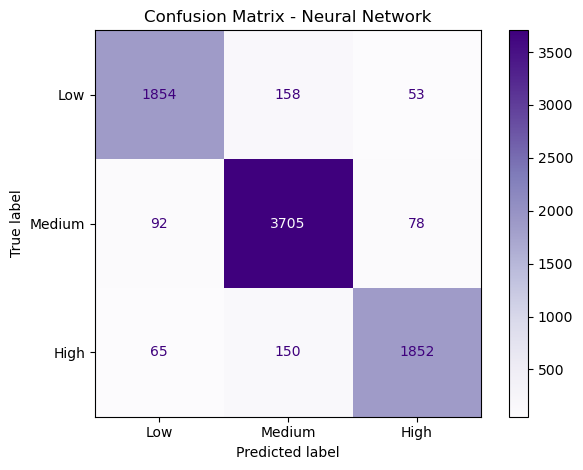

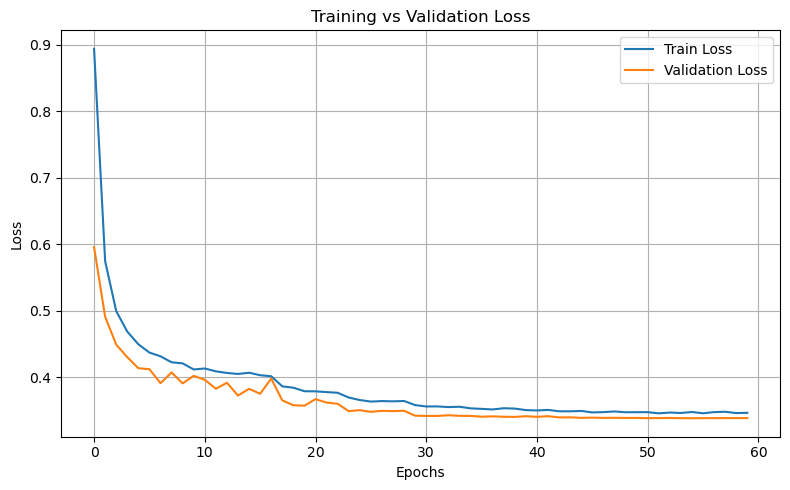

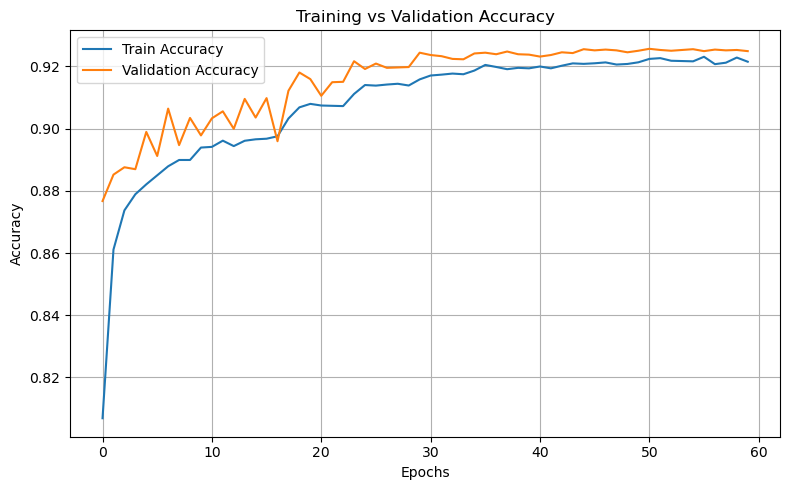

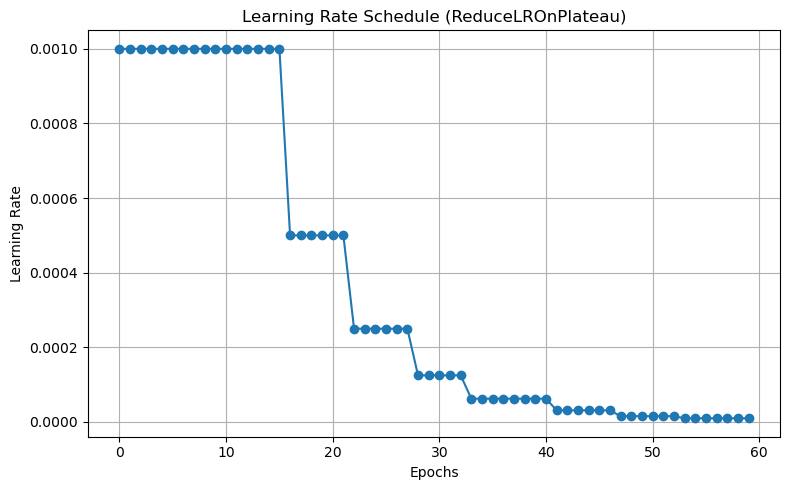

In [130]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback

# ==========================================
# 1. Prepare X and y
# ==========================================

X = x.copy().astype(float)

if isinstance(y, pd.Series):
    y_model = y.astype(int).copy()
else:
    y_model = pd.Series(y).astype(int)

# חשוב: לאפס אינדקסים כדי למנוע חוסר התאמה
X = X.reset_index(drop=True)
y_model = y_model.reset_index(drop=True)

print("Full X shape:", X.shape)
print("Full y shape:", y_model.shape)

# ==========================================
# 2. Train/Test split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

print("Train X shape:", X_train.shape)
print("Train y shape:", y_train.shape)
print("Test X shape:", X_test.shape)
print("Test y shape:", y_test.shape)

# ==========================================
# 3. Standardization
# ==========================================

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

y_train = np.array(y_train).astype(np.int32)
y_test = np.array(y_test).astype(np.int32)

print("Scaled train shape:", x_train_scaled.shape)
print("Scaled test shape:", x_test_scaled.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# ==========================================
# 4. Callback to store learning rate history
# ==========================================

class LrHistory(Callback):
    def on_train_begin(self, logs=None):
        self.lr_values = []

    def on_epoch_end(self, epoch, logs=None):
        lr = tf.keras.backend.get_value(self.model.optimizer.learning_rate)
        self.lr_values.append(lr)

lr_history = LrHistory()

# ==========================================
# 5. Neural Network Model
# ==========================================

n_features = x_train_scaled.shape[1]

model = Sequential([
    Input(shape=(n_features,)),
   
    Dense(800, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(512, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(128, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0003)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# ==========================================
# 6. Callbacks
# ==========================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

# ==========================================
# 7. Train
# ==========================================

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr, lr_history],
    verbose=1
)

# ==========================================
# 8. Evaluate
# ==========================================

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# ==========================================
# 9. Predictions
# ==========================================

y_train_prob = model.predict(x_train_scaled)
y_test_prob = model.predict(x_test_scaled)

y_train_pred = np.argmax(y_train_prob, axis=1)
y_test_pred = np.argmax(y_test_prob, axis=1)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nTrain Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Accuracy Gap (Train - Test): {train_accuracy - test_accuracy:.4f}")

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

# ==========================================
# 10. Confusion Matrix
# ==========================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Low", "Medium", "High"],
    cmap="Purples"
)

plt.title("Confusion Matrix - Neural Network")
plt.tight_layout()
plt.show()

# ==========================================
# 11. Loss plot
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# 12. Accuracy plot
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# 13. Learning rate plot
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(lr_history.lr_values, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule (ReduceLROnPlateau)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Remove non-significant variables

Reduced X shape: (40034, 5)
Reduced y shape: (40034,)
Train X shape: (32027, 5)
Train y shape: (32027,)
Test X shape: (8007, 5)
Test y shape: (8007,)
Scaled train shape: (32027, 5)
Scaled test shape: (8007, 5)
Epoch 1/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8413 - loss: 0.8488 - val_accuracy: 0.8736 - val_loss: 0.5555 - learning_rate: 0.0010
Epoch 2/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8854 - loss: 0.4987 - val_accuracy: 0.9035 - val_loss: 0.4256 - learning_rate: 0.0010
Epoch 3/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.8911 - loss: 0.4413 - val_accuracy: 0.9071 - val_loss: 0.3909 - learning_rate: 0.0010
Epoch 4/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.8965 - loss: 0.4160 - val_accuracy: 0.9051 - val_loss: 0.3871 - learning_rate: 0.0010
Epoch 5/60
641/641 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.8990 - loss: 0.4030 - val_accuracy: 0.9140 - val_loss: 0.3697 - learning_rate: 0.0010
Epoch 6/60
641/641 ━

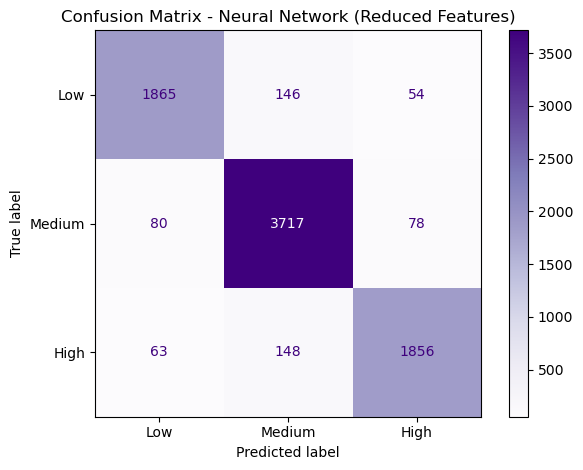

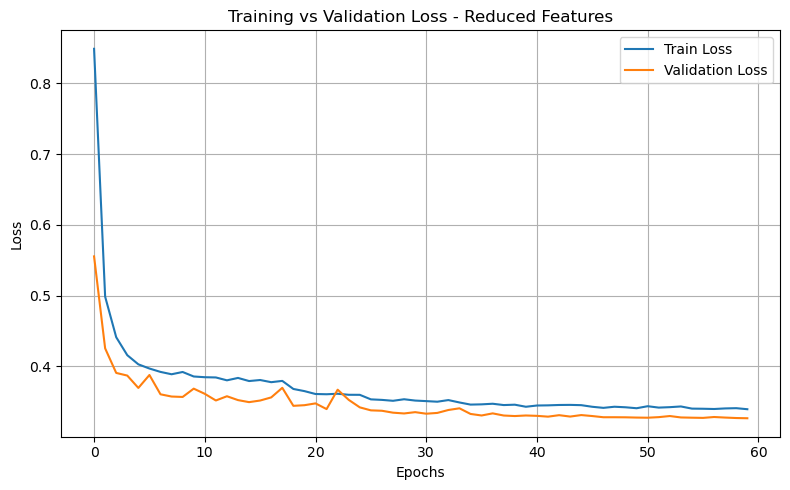

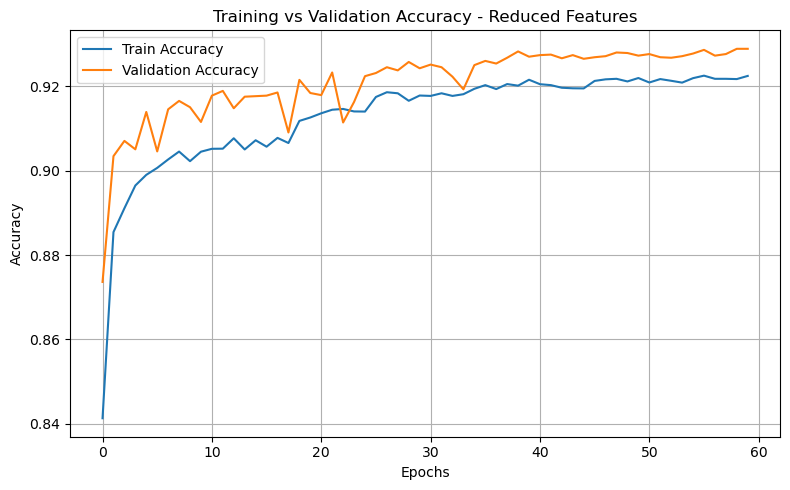

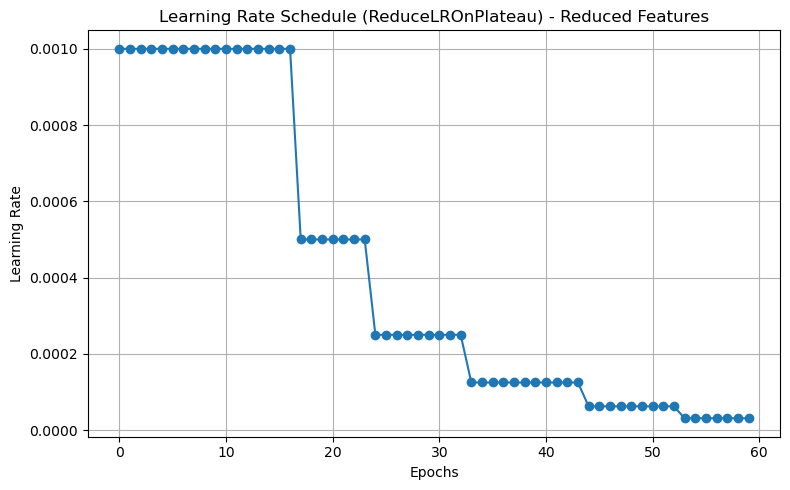

In [78]:
# import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

x_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy()
x_reduced = x_reduced.astype(float)

if isinstance(y, pd.Series):
    y_reduced = y.astype(int).copy()
else:
    y_reduced = pd.Series(y).astype(int)

# חשוב: לאפס אינדקסים כדי למנוע חוסר התאמה
x_reduced = x_reduced.reset_index(drop=True)
y_reduced = y_reduced.reset_index(drop=True)

print("Reduced X shape:", x_reduced.shape)
print("Reduced y shape:", y_reduced.shape)

# ==========================================
# 2. Train/Test split
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    x_reduced,
    y_reduced,
    test_size=0.2,
    random_state=42,
    stratify=y_reduced
)

print("Train X shape:", x_train.shape)
print("Train y shape:", y_train.shape)
print("Test X shape:", x_test.shape)
print("Test y shape:", y_test.shape)

# ==========================================
# 3. Standardization
# ==========================================

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

y_train = np.array(y_train).astype(np.int32)
y_test = np.array(y_test).astype(np.int32)

print("Scaled train shape:", x_train_scaled.shape)
print("Scaled test shape:", x_test_scaled.shape)

# ==========================================
# 4. Callback to store learning rate history
# ==========================================

class LrHistory(Callback):
    def on_train_begin(self, logs=None):
        self.lr_values = []

    def on_epoch_end(self, epoch, logs=None):
        lr = tf.keras.backend.get_value(self.model.optimizer.learning_rate)
        self.lr_values.append(lr)

lr_history = LrHistory()

# ==========================================
# 5. Define Neural Network
# ==========================================

n_features = x_train_scaled.shape[1]

model = Sequential([
    Input(shape=(n_features,)),
   
    Dense(800, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(600, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(512, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(128, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0003)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

# ==========================================
# 6. Compile
# ==========================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# ==========================================
# 7. Callbacks
# ==========================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

# ==========================================
# 8. Train
# ==========================================

history = model.fit(
    x_train_scaled, y_train,
    epochs=60,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr, lr_history],
    verbose=1
)

# ==========================================
# 9. Evaluate
# ==========================================

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# ==========================================
# 10. Predictions
# ==========================================

y_train_prob = model.predict(x_train_scaled)
y_test_prob = model.predict(x_test_scaled)

y_train_pred = np.argmax(y_train_prob, axis=1)
y_test_pred = np.argmax(y_test_prob, axis=1)

# ==========================================
# 11. Train/Test Accuracy + overfitting check
# ==========================================

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nTrain Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Accuracy Gap (Train - Test): {train_accuracy - test_accuracy:.4f}")

if train_accuracy - test_accuracy > 0.03:
    print("Possible overfitting detected.")
else:
    print("No substantial overfitting detected.")

# ==========================================
# 12. Classification Report
# ==========================================

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

# ==========================================
# 13. Confusion Matrix
# ==========================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Low", "Medium", "High"],
    cmap="Purples"
)

plt.title("Confusion Matrix - Neural Network (Reduced Features)")
plt.tight_layout()
plt.show()

# ==========================================
# 14. Plot Training vs Validation Loss
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss - Reduced Features')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# 15. Plot Training vs Validation Accuracy
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy - Reduced Features')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# 16. Plot Learning Rate Schedule
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(lr_history.lr_values, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule (ReduceLROnPlateau) - Reduced Features')
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Reduced X shape: (40034, 5)
Reduced y shape: (40034,)
Train X shape: (32027, 5)
Train y shape: (32027,)
Test X shape: (8007, 5)
Test y shape: (8007,)
Scaled train shape: (32027, 5)
Scaled test shape: (8007, 5)
Epoch 1/65
641/641 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.8422 - loss: 0.8277 - val_accuracy: 0.8819 - val_loss: 0.5472 - learning_rate: 0.0010
Epoch 2/65
641/641 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8852 - loss: 0.5010 - val_accuracy: 0.9053 - val_loss: 0.4198 - learning_rate: 0.0010
Epoch 3/65
641/641 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8934 - loss: 0.4379 - val_accuracy: 0.9040 - val_loss: 0.3980 - learning_rate: 0.0010
Epoch 4/65
641/641 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8959 - loss: 0.4186 - val_accuracy: 0.9117 - val_loss: 0.3817 - learning_rate: 0.0010
Epoch 5/65
641/641 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8996 - loss: 0.4058 - val_accuracy: 0.9061 - val_loss: 0.3835 - learning_rate: 0.0010
Epoch 6/65
641/641 ━

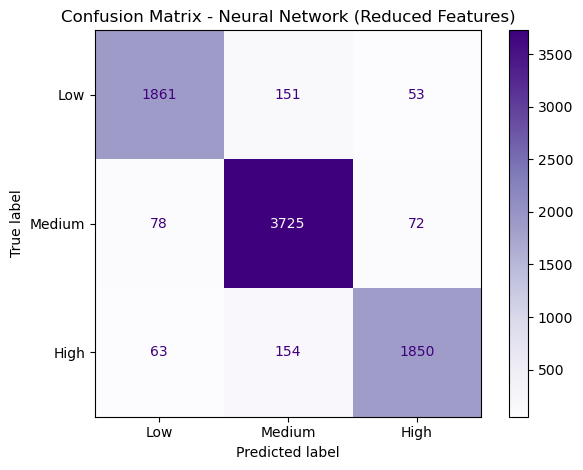

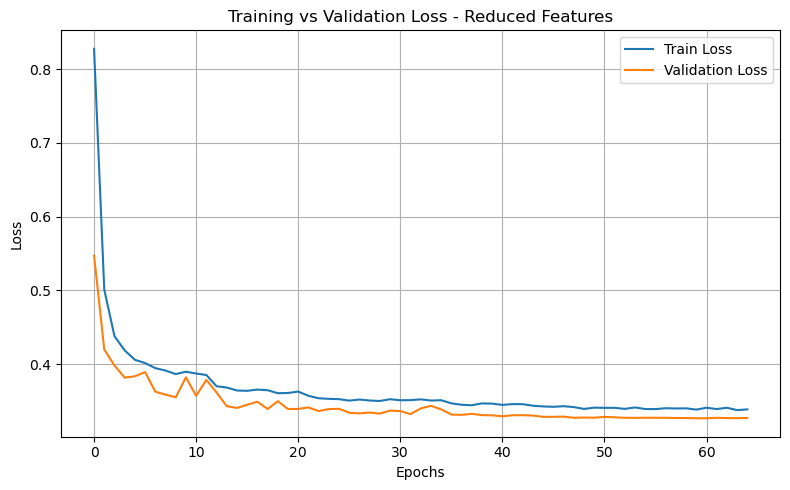

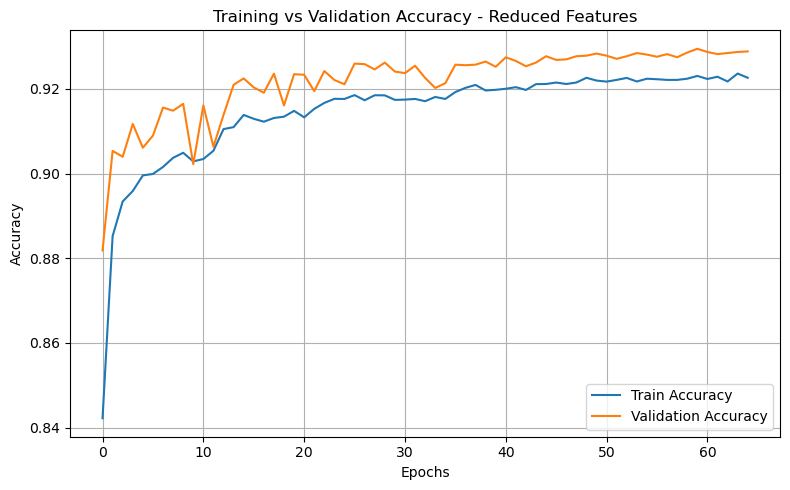

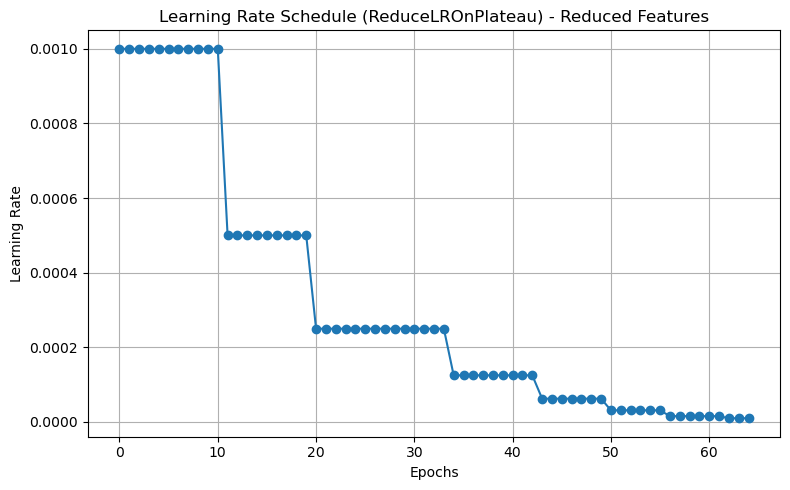

In [72]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

x_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy()
x_reduced = x_reduced.astype(float)

if isinstance(y, pd.Series):
    y_reduced = y.astype(int).copy()
else:
    y_reduced = pd.Series(y).astype(int)

# חשוב: לאפס אינדקסים כדי למנוע חוסר התאמה
x_reduced = x_reduced.reset_index(drop=True)
y_reduced = y_reduced.reset_index(drop=True)

print("Reduced X shape:", x_reduced.shape)
print("Reduced y shape:", y_reduced.shape)

# ==========================================
# 2. Train/Test split
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    x_reduced,
    y_reduced,
    test_size=0.2,
    random_state=42,
    stratify=y_reduced
)

print("Train X shape:", x_train.shape)
print("Train y shape:", y_train.shape)
print("Test X shape:", x_test.shape)
print("Test y shape:", y_test.shape)

# ==========================================
# 3. Standardization
# ==========================================

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

y_train = np.array(y_train).astype(np.int32)
y_test = np.array(y_test).astype(np.int32)

print("Scaled train shape:", x_train_scaled.shape)
print("Scaled test shape:", x_test_scaled.shape)

# ==========================================
# 4. Callback to store learning rate history
# ==========================================

class LrHistory(Callback):
    def on_train_begin(self, logs=None):
        self.lr_values = []

    def on_epoch_end(self, epoch, logs=None):
        lr = tf.keras.backend.get_value(self.model.optimizer.learning_rate)
        self.lr_values.append(lr)

lr_history = LrHistory()

# ==========================================
# 5. Define Neural Network
# ==========================================

n_features = x_train_scaled.shape[1]

model = Sequential([
    Input(shape=(n_features,)),
   
    Dense(800, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(600, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(512, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(128, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0003)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

# ==========================================
# 6. Compile
# ==========================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# ==========================================
# 7. Callbacks
# ==========================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

# ==========================================
# 8. Train
# ==========================================

history = model.fit(
    x_train_scaled, y_train,
    epochs=65,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr, lr_history],
    verbose=1
)

# ==========================================
# 9. Evaluate
# ==========================================

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# ==========================================
# 10. Predictions
# ==========================================

y_train_prob = model.predict(x_train_scaled)
y_test_prob = model.predict(x_test_scaled)

y_train_pred = np.argmax(y_train_prob, axis=1)
y_test_pred = np.argmax(y_test_prob, axis=1)

# ==========================================
# 11. Train/Test Accuracy + overfitting check
# ==========================================

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nTrain Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Accuracy Gap (Train - Test): {train_accuracy - test_accuracy:.4f}")

if train_accuracy - test_accuracy > 0.03:
    print("Possible overfitting detected.")
else:
    print("No substantial overfitting detected.")

# ==========================================
# 12. Classification Report
# ==========================================

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

# ==========================================
# 13. Confusion Matrix
# ==========================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Low", "Medium", "High"],
    cmap="Purples"
)

plt.title("Confusion Matrix - Neural Network (Reduced Features)")
plt.tight_layout()
plt.show()

# ==========================================
# 14. Plot Training vs Validation Loss
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss - Reduced Features')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# 15. Plot Training vs Validation Accuracy
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy - Reduced Features')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# 16. Plot Learning Rate Schedule
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(lr_history.lr_values, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule (ReduceLROnPlateau) - Reduced Features')
plt.grid(True)
plt.tight_layout()
plt.show()

Reduced X shape: (40034, 5)
Reduced y shape: (40034,)
Train X shape: (32027, 5)
Train y shape: (32027,)
Test X shape: (8007, 5)
Test y shape: (8007,)
Scaled train shape: (32027, 5)
Scaled test shape: (8007, 5)
Epoch 1/62
641/641 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.8381 - loss: 0.8541 - val_accuracy: 0.9053 - val_loss: 0.5076 - learning_rate: 0.0010
Epoch 2/62
641/641 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8847 - loss: 0.5045 - val_accuracy: 0.9063 - val_loss: 0.4222 - learning_rate: 0.0010
Epoch 3/62
641/641 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8904 - loss: 0.4430 - val_accuracy: 0.9108 - val_loss: 0.3878 - learning_rate: 0.0010
Epoch 4/62
641/641 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8969 - loss: 0.4154 - val_accuracy: 0.9154 - val_loss: 0.3738 - learning_rate: 0.0010
Epoch 5/62
641/641 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8971 - loss: 0.4088 - val_accuracy: 0.9113 - val_loss: 0.3719 - learning_rate: 0.0010
Epoch 6/62
641/641 ━

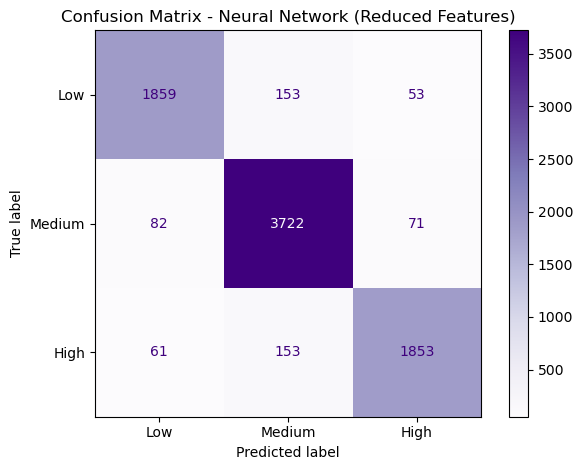

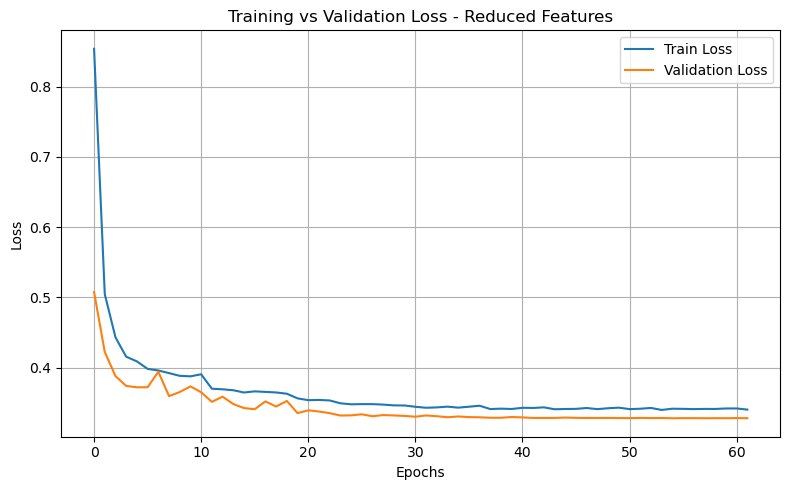

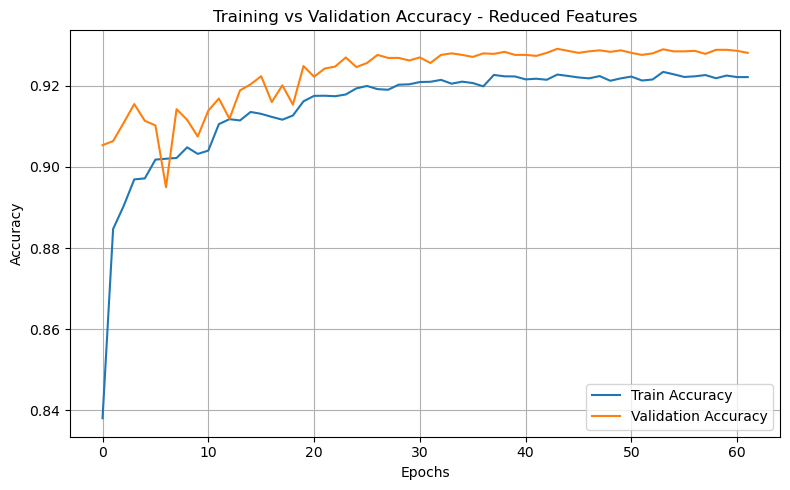

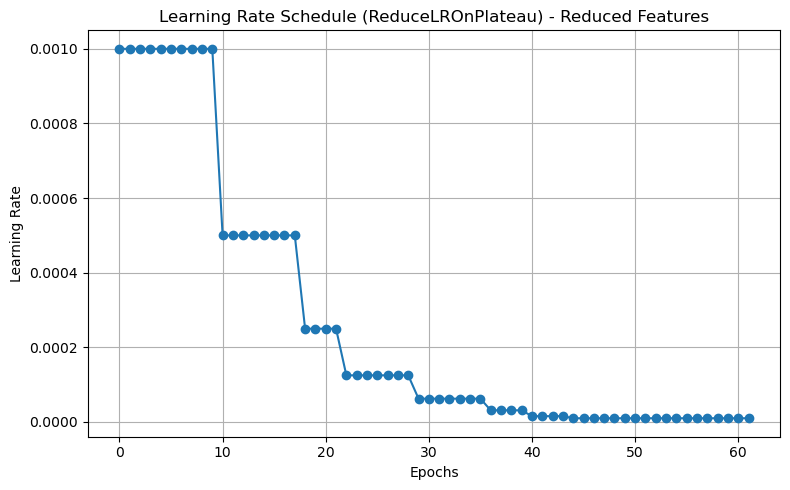

In [76]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback

# ==========================================
# 1. Remove non-significant variables
# ==========================================

variables_to_remove = [
    'game_genre_action',
    'game_genre_rpg',
    'game_genre_strategy',
    'gender_male',
    'game_difficulty_hard',
    'game_difficulty_medium',
    'location_usa',
    'game_genre_sports',
    'age',
    'play_time_hours',
    'location_europe',
    'location_other'
]

x_reduced = x.drop(columns=variables_to_remove, errors='ignore').copy()
x_reduced = x_reduced.astype(float)

if isinstance(y, pd.Series):
    y_reduced = y.astype(int).copy()
else:
    y_reduced = pd.Series(y).astype(int)

# חשוב: לאפס אינדקסים כדי למנוע חוסר התאמה
x_reduced = x_reduced.reset_index(drop=True)
y_reduced = y_reduced.reset_index(drop=True)

print("Reduced X shape:", x_reduced.shape)
print("Reduced y shape:", y_reduced.shape)

# ==========================================
# 2. Train/Test split
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    x_reduced,
    y_reduced,
    test_size=0.2,
    random_state=42,
    stratify=y_reduced
)

print("Train X shape:", x_train.shape)
print("Train y shape:", y_train.shape)
print("Test X shape:", x_test.shape)
print("Test y shape:", y_test.shape)

# ==========================================
# 3. Standardization
# ==========================================

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

y_train = np.array(y_train).astype(np.int32)
y_test = np.array(y_test).astype(np.int32)

print("Scaled train shape:", x_train_scaled.shape)
print("Scaled test shape:", x_test_scaled.shape)

# ==========================================
# 4. Callback to store learning rate history
# ==========================================

class LrHistory(Callback):
    def on_train_begin(self, logs=None):
        self.lr_values = []

    def on_epoch_end(self, epoch, logs=None):
        lr = tf.keras.backend.get_value(self.model.optimizer.learning_rate)
        self.lr_values.append(lr)

lr_history = LrHistory()

# ==========================================
# 5. Define Neural Network
# ==========================================

n_features = x_train_scaled.shape[1]

model = Sequential([
    Input(shape=(n_features,)),
   
    Dense(800, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(600, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(512, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),

    Dense(256, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.3),
   
    Dense(128, activation='relu', kernel_regularizer=L2(0.0006)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=L2(0.0003)),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

# ==========================================
# 6. Compile
# ==========================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# ==========================================
# 7. Callbacks
# ==========================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=61,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

# ==========================================
# 8. Train
# ==========================================

history = model.fit(
    x_train_scaled, y_train,
    epochs=62,
    batch_size=50,
    validation_data=(x_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr, lr_history],
    verbose=1
)

# ==========================================
# 9. Evaluate
# ==========================================

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=2)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# ==========================================
# 10. Predictions
# ==========================================

y_train_prob = model.predict(x_train_scaled)
y_test_prob = model.predict(x_test_scaled)

y_train_pred = np.argmax(y_train_prob, axis=1)
y_test_pred = np.argmax(y_test_prob, axis=1)

# ==========================================
# 11. Train/Test Accuracy + overfitting check
# ==========================================

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nTrain Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Accuracy Gap (Train - Test): {train_accuracy - test_accuracy:.4f}")

if train_accuracy - test_accuracy > 0.03:
    print("Possible overfitting detected.")
else:
    print("No substantial overfitting detected.")

# ==========================================
# 12. Classification Report
# ==========================================

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

# ==========================================
# 13. Confusion Matrix
# ==========================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Low", "Medium", "High"],
    cmap="Purples"
)

plt.title("Confusion Matrix - Neural Network (Reduced Features)")
plt.tight_layout()
plt.show()

# ==========================================
# 14. Plot Training vs Validation Loss
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss - Reduced Features')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# 15. Plot Training vs Validation Accuracy
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy - Reduced Features')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# 16. Plot Learning Rate Schedule
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(lr_history.lr_values, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule (ReduceLROnPlateau) - Reduced Features')
plt.grid(True)
plt.tight_layout()
plt.show()

# Model comparison chart

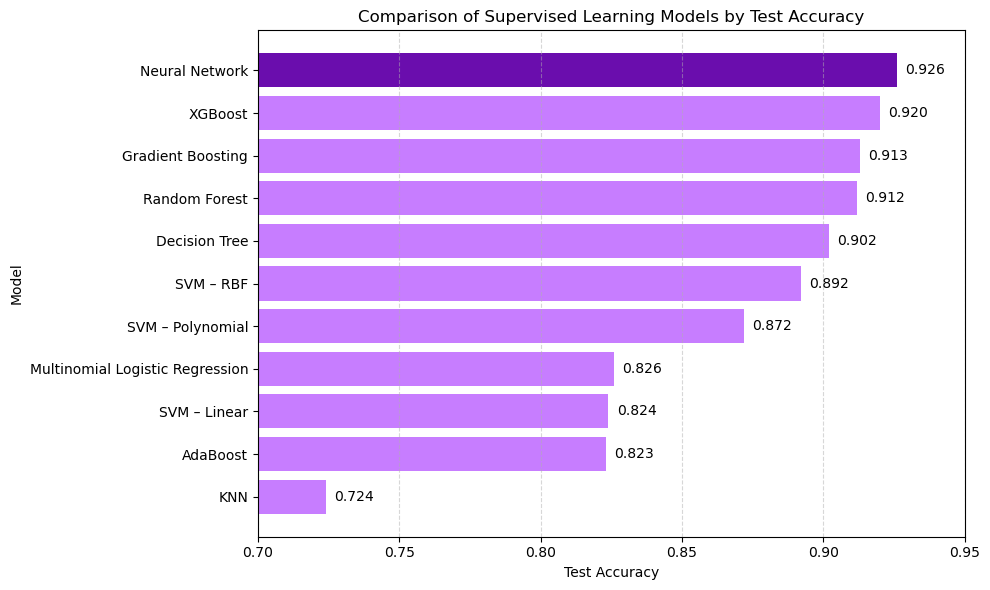

In [89]:

import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Model results
# =========================

results = {
    "Multinomial Logistic Regression": 0.826,
    "KNN": 0.724,
    "Decision Tree": 0.902,
    "Random Forest": 0.912,
    "Gradient Boosting": 0.913,
    "AdaBoost": 0.823,
    "XGBoost": 0.920,
    "SVM – Linear": 0.824,
    "SVM – Polynomial": 0.872,
    "SVM – RBF": 0.892,
    "Neural Network": 0.926
}

df_results = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])

# מיון מהנמוך לגבוה
df_results = df_results.sort_values("Accuracy", ascending=True).reset_index(drop=True)

# =========================
# 2. Colors
# =========================

colors = ["#C77DFF"] * len(df_results)   # סגול בהיר לכל המודלים
best_model_idx = df_results["Accuracy"].idxmax()
colors[best_model_idx] = "#6A0DAD"       # סגול כהה למודל הטוב ביותר

# =========================
# 3. Plot
# =========================

plt.figure(figsize=(10, 6))
bars = plt.barh(df_results["Model"], df_results["Accuracy"], color=colors)

# כתיבת ערכי הדיוק על כל עמודה
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.003,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        fontsize=10
    )

plt.xlabel("Test Accuracy")
plt.ylabel("Model")
plt.title("Comparison of Supervised Learning Models by Test Accuracy")
plt.xlim(0.70, 0.95)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
